In [1]:
%matplotlib qt

In [3]:
%matplotlib inline

# Illumination Correction - Now with Persistence! 🎉

The `apply_illumination_correction()` method now automatically:
1. **Checks** if illumination correction with the same parameters has already been computed
2. **Loads** from disk if already done (fast!)
3. **Computes** if needed (slow, but only done once)
4. **Saves** to disk automatically for next time

The corrected data is saved in each HDF5 file as:
- Dataset: `processed/radiance/dataCube_illum_corrected`
- Metadata: `window_size`, `strength`, `description`

**Usage:**
```python
# First run: computes and saves (slow)
cube.apply_illumination_correction(window_size=1000, strength=1.0)

# Subsequent runs: loads from disk (fast!)
cube.apply_illumination_correction(window_size=1000, strength=1.0)

# Force recompute if needed
cube.apply_illumination_correction(window_size=1000, strength=1.0, force_recompute=True)
```

In [6]:
"""
UHI Georeference RGB + UHI Mask + MBES Residuals
Three original figures + a NEW figure:
    5) MBES residuals clipped by the pixel-perfect UHI footprint (full MBES resolution).
"""

import importlib
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from contextlib import contextmanager
import rasterio
from dataclasses import dataclass
from typing import Optional, Tuple, List, Dict
from scipy.stats import median_abs_deviation
from matplotlib.collections import LineCollection
from matplotlib.path import Path
from matplotlib.patches import PathPatch

# Add parent directory to path
sys.path.append(os.path.abspath("../"))

from utils import georef
import config

importlib.reload(georef)
from utils.georef import _ecef_to_ned_arrays

In [7]:
# Example: Check if illumination correction exists
# This is optional - the apply method does it automatically!

# Check with specific parameters
has_correction = cube.has_illumination_correction(window_size=1000, strength=1.0)
print(f"Has correction (window=1000, strength=1.0)? {has_correction}")

# You can also manually load if needed
if has_correction:
    cube.load_illumination_correction()
    print(f"Loaded corrected data: {cube.data_corrected.shape}")
else:
    print(
        "No saved correction found. Will compute on first apply_illumination_correction() call."
    )

AttributeError: 'CombinedTransectCube' object has no attribute 'has_illumination_correction'


================  UHI + MBES → Four Figures + NEW pixel-perfect clip  ================

📁 Loading transect from: E:\mjosa_new_oct_2025\use_gref4hsi\057_completed\output

📋 Files in output (corrected=False):
 1. rad_uhi_20241029_115057_1  | shape=(1333, 968, 210)  | has_georef=True
 2. rad_uhi_20241029_115057_2  | shape=(1946, 968, 210)  | has_georef=True
 3. rad_uhi_20241029_115057_3  | shape=(2227, 968, 210)  | has_georef=True
 4. rad_uhi_20241029_115057_4  | shape=(2463, 968, 210)  | has_georef=True
 5. rad_uhi_20241029_115057_5  | shape=(2462, 968, 210)  | has_georef=True
 6. rad_uhi_20241029_115057_6  | shape=(155, 968, 210)  | has_georef=True

🔍 Selecting files...
🔄 Rebuilding grids from georef hits for selected files...
   • rad_uhi_20241029_115057_4
  rad_uhi_20241029_115057_4: Using GRIDDED format (T=2463, S=968)
   • rad_uhi_20241029_115057_5
  rad_uhi_20241029_115057_5: Using GRIDDED format (T=2462, S=968)
✅ Combined shapes: X/Y/Z (4925, 968), RGB (4925, 968)

=== Combined_o

c:\Users\Erik Liu\OneDrive - NTNU\PhD\Courses\UHI post processing\havard_repo\from_Leo_usb\gref4hsi\x_gref4hsi_by_liu\utils\georef.py:718: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
c:\Users\Erik Liu\OneDrive - NTNU\PhD\Courses\UHI post processing\havard_repo\from_Leo_usb\gref4hsi\x_gref4hsi_by_liu\utils\georef.py:826: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()



🎨 Preparing Plot 2: UHI validity mask (NED)

🎨 Preparing Plot 3: MBES Residuals (detrended bathymetry)
📂 Loading MBES GeoTIFF: E:\mjosa_new\DTM\geotiff_2.tif
   MBES shape: (5249, 1408)
   MBES resolution: 0.0200 × 0.0200 m
⚙️  Detrending MBES data...
🎨 Creating MBES residuals plot...

🎨 Preparing Plot 4: UHI Mask on MBES Residuals (combined)
   UHI valid points: 958,320
   UHI X (NED East) range: [-346.40, -343.81] m
   UHI Y (NED North) range: [-43.21, -33.45] m
   MBES X range: [592829.45, 592857.59]
   MBES Y range: [6741790.71, 6741895.67]
   🔄 Converting MBES grid from GeoTIFF CRS → WGS84 → ECEF → NED...

🆕  Preparing Plot 5: FULL-RES MBES within exact UHI footprint (pixel-perfect outline)


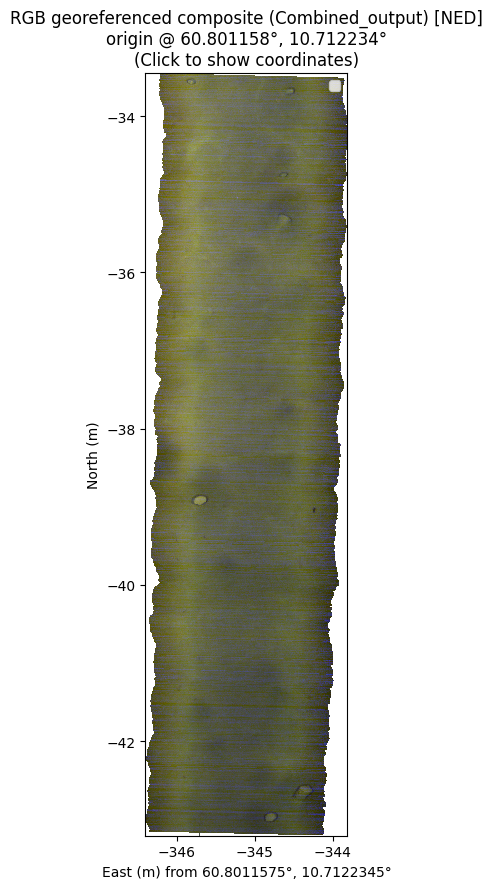

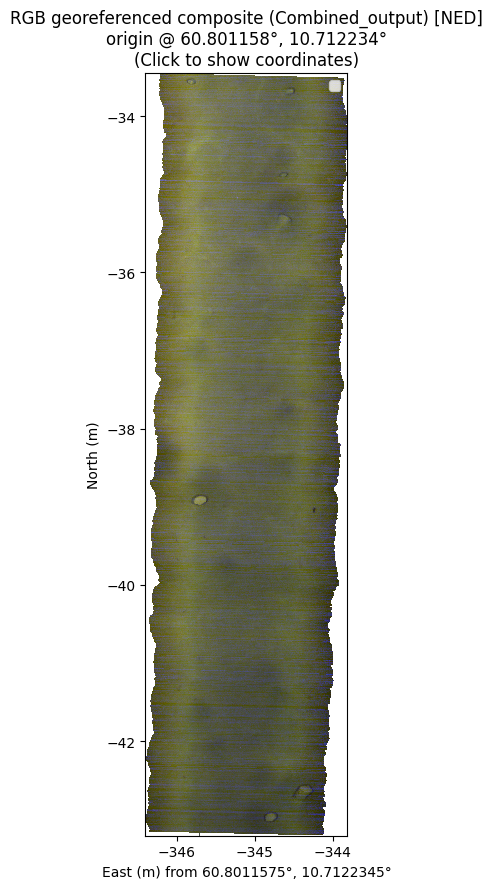

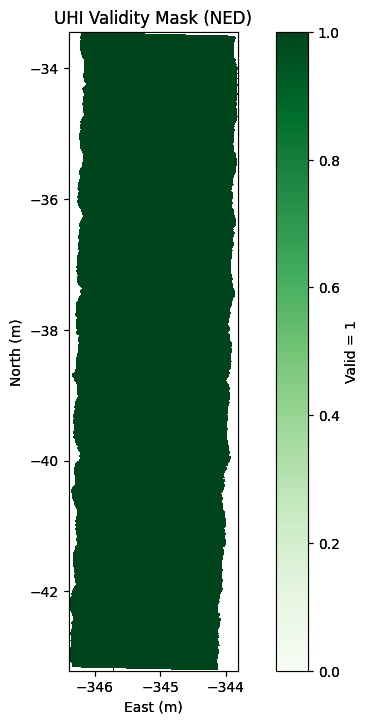

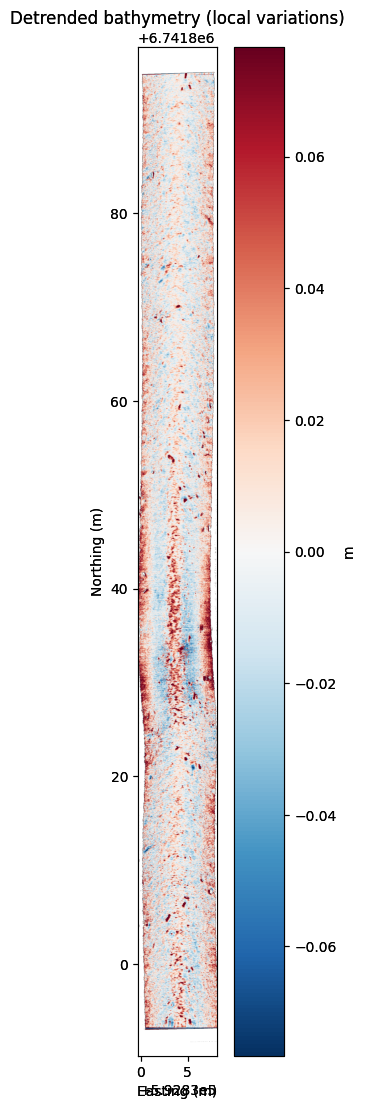

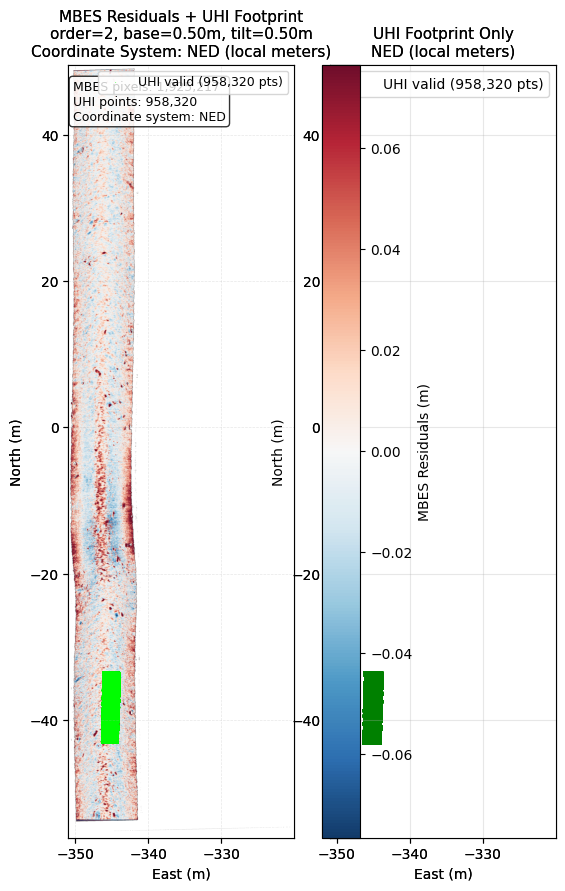

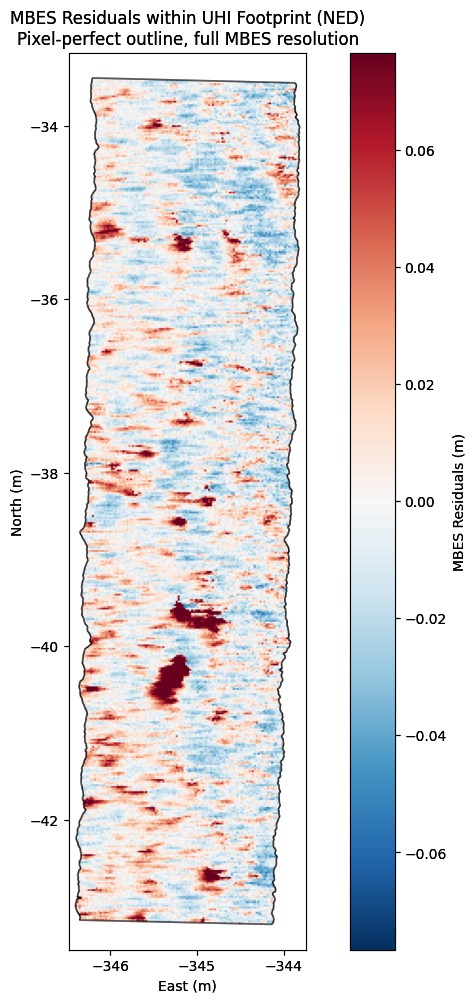


================  ✅ All figures opened (originals + new pixel-perfect clip)  ================



In [4]:
"""
UHI Georeference RGB + UHI Mask + MBES Residuals
Three original figures + a NEW figure:
    5) MBES residuals clipped by the pixel-perfect UHI footprint (full MBES resolution).
"""

import importlib
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from contextlib import contextmanager
import rasterio
from dataclasses import dataclass
from typing import Optional, Tuple, List, Dict
from scipy.stats import median_abs_deviation
from matplotlib.collections import LineCollection
from matplotlib.path import Path
from matplotlib.patches import PathPatch

# Add parent directory to path
sys.path.append(os.path.abspath("../"))

from utils import georef
import config

importlib.reload(georef)
from utils.georef import _ecef_to_ned_arrays


# ----------------------------
# Helpers
# ----------------------------
def slice_tracks(arr, start_idx, end_idx):
    if start_idx is None and end_idx is None:
        return arr
    s = start_idx if start_idx is not None else 0
    e = end_idx if end_idx is not None else arr.shape[0]
    return arr[s:e, :]


def build_full_valid_mask(X_ecef, Y_ecef, Z_ecef, R, G, B):
    coords_valid = np.isfinite(X_ecef) & np.isfinite(Y_ecef) & np.isfinite(Z_ecef)
    rgb_valid = np.isfinite(R) & np.isfinite(G) & np.isfinite(B)
    return coords_valid & rgb_valid


def pcolormesh_pad(X, Y):
    Xc = np.pad(X, ((0, 1), (0, 1)), mode="edge")
    Yc = np.pad(Y, ((0, 1), (0, 1)), mode="edge")
    return Xc, Yc


@contextmanager
def suppress_matplotlib_show():
    """Temporarily make plt.show() a no-op so earlier plots do not block."""
    _orig_show = plt.show
    try:
        plt.show = lambda *a, **k: None
        yield
    finally:
        plt.show = _orig_show


# ----------------------------
# Minimal MBES Detrending Class (extracted from dev3_mbes3.py)
# ----------------------------
def _pad_limits(ax, x_min, x_max, y_min, y_max, pad_frac=0.03, equal_aspect=True):
    xr = max(1e-12, x_max - x_min)
    yr = max(1e-12, y_max - y_min)
    ax.set_xlim(x_min - xr * pad_frac, x_max + xr * pad_frac)
    ax.set_ylim(y_min - yr * pad_frac, y_max + yr * pad_frac)
    if equal_aspect:
        ax.set_aspect("equal", adjustable="box")


@dataclass
class MBESDetrender:
    """Minimal MBES detrending for residual plot only."""

    tif_path: str
    nodata_value: Optional[float] = 9999.0
    smooth_baseline_m: float = 0.5
    smooth_tilt_m: float = 0.5
    smooth_center_m: float = 1.0

    data: Optional[np.ndarray] = None
    valid_mask: Optional[np.ndarray] = None
    transform: Optional[object] = None
    extent: Optional[Tuple[float, float, float, float]] = None
    px_x: Optional[float] = None
    px_y: Optional[float] = None
    x_cols: Optional[np.ndarray] = None
    y_rows: Optional[np.ndarray] = None
    epsg: Optional[int] = None  # <-- store CRS

    A_s: Optional[np.ndarray] = None
    B_s: Optional[np.ndarray] = None
    C_s: Optional[np.ndarray] = None
    trend: Optional[np.ndarray] = None
    residuals: Optional[np.ndarray] = None

    def load(self):
        with rasterio.open(self.tif_path) as src:
            z = src.read(1).astype(np.float64)
            tf = src.transform
            bounds = src.bounds
            self.epsg = src.crs.to_epsg() if src.crs else None

        if self.nodata_value is not None:
            z = np.where(z == self.nodata_value, np.nan, z)

        self.valid_mask = np.isfinite(z)
        a, b, c, d, e, f = tf.a, tf.b, tf.c, tf.d, tf.e, tf.f
        H, W = z.shape
        cols = np.arange(W)
        rows = np.arange(H)
        self.x_cols = c + a * (cols + 0.5)
        self.y_rows = f + e * (rows + 0.5)
        self.px_x = abs(a)
        self.px_y = abs(e)
        self.data = z
        self.transform = tf
        self.extent = (
            float(bounds.left),
            float(bounds.right),
            float(bounds.bottom),
            float(bounds.top),
        )
        return self

    def detrend(self, order_x=2, robust=True, central_frac=0.8, max_row_iters=3):
        """Simple row-wise polynomial detrend + along-track smoothing."""
        from scipy.signal import savgol_filter

        if self.data is None:
            self.load()

        z = self.data
        x = self.x_cols
        H, W = z.shape
        valid_rows = np.any(self.valid_mask, axis=1)
        valid_row_indices = np.where(valid_rows)[0]

        A = np.full(H, np.nan)
        B = np.full(H, 0.0)
        C = np.full(H, 0.0)

        # Per-row polynomial fit
        for i in valid_row_indices:
            row = z[i, :]
            m = np.isfinite(row)
            if m.sum() < 6:
                continue
            xv = x[m]
            yv = row[m]
            xc_row = np.median(xv)

            if 0 < central_frac < 1:
                lo = np.quantile(xv, 0.5 - 0.5 * central_frac)
                hi = np.quantile(xv, 0.5 + 0.5 * central_frac)
                keep = (xv >= lo) & (xv <= hi)
                xv, yv = xv[keep], yv[keep]

            xi = xv - xc_row
            deg = min(order_x, 2)
            coef = np.polyfit(xi, yv, deg)

            if deg == 0:
                a0, a1, a2 = float(coef[0]), 0.0, 0.0
            elif deg == 1:
                a1, a0 = float(coef[0]), float(coef[1])
                a2 = 0.0
            else:
                a2, a1, a0 = float(coef[0]), float(coef[1]), float(coef[2])

            if robust and deg > 0:
                for _ in range(max_row_iters):
                    pred = a0 + a1 * xi + a2 * (xi**2)
                    resid = yv - pred
                    s = median_abs_deviation(resid, scale="normal")
                    if not np.isfinite(s) or s == 0:
                        break
                    w = 1.0 / (1.0 + (resid / (3 * s)) ** 2)
                    X = np.vstack([np.ones_like(xi), xi])
                    if deg == 2:
                        X = np.vstack([X, xi**2])
                    XtW = X * w
                    beta = np.linalg.lstsq(XtW.T, (yv * w), rcond=None)[0]
                    if deg == 2:
                        a0, a1, a2 = float(beta[0]), float(beta[1]), float(beta[2])
                    else:
                        a0, a1 = float(beta[0]), float(beta[1])
                        a2 = 0.0

            A[i] = a0
            B[i] = a1
            C[i] = a2

        # Smooth along-track
        def smooth_1d(arr, scale_m):
            if scale_m <= 0 or self.px_y <= 0:
                return arr
            m = np.isfinite(arr)
            if m.sum() < 5:
                return arr
            w = max(3, int(np.round(scale_m / self.px_y)))
            if w % 2 == 0:
                w += 1
            w = min(w, m.sum() - 1 if m.sum() > 1 else 1)
            if w < 3:
                return arr
            result = arr.copy()
            result[m] = savgol_filter(arr[m], window_length=w, polyorder=2)
            return result

        self.A_s = smooth_1d(A, self.smooth_baseline_m)
        self.B_s = smooth_1d(B, self.smooth_tilt_m)
        self.C_s = smooth_1d(C, self.smooth_tilt_m)

        # Reconstruct trend
        trend = np.full_like(z, np.nan)
        for i in valid_row_indices:
            if not np.isfinite(self.A_s[i]):
                continue
            xc = np.median(x[np.isfinite(z[i, :])])
            xi = x - xc
            trend[i, :] = self.A_s[i] + self.B_s[i] * xi + self.C_s[i] * xi**2

        self.trend = trend
        self.residuals = z - trend
        return self

    def _extent_imshow(self):
        return (
            self.x_cols[0] - self.px_x / 2,
            self.x_cols[-1] + self.px_x / 2,
            self.y_rows[-1] - self.px_y / 2,
            self.y_rows[0] + self.px_y / 2,
        )

    def _robust_sym_vlim(self, arr, q=0.98):
        finite = arr[np.isfinite(arr)]
        if len(finite) == 0:
            return -1, 1
        vmax = np.quantile(np.abs(finite), q)
        return -vmax, vmax

    def _get_data_bounds(self, percentile=99.5):
        rows, cols = np.where(self.valid_mask)
        if len(rows) == 0:
            return self.extent
        p_low = (100 - percentile) / 2
        p_high = 100 - p_low
        x_min = np.percentile(self.x_cols[cols], p_low)
        x_max = np.percentile(self.x_cols[cols], p_high)
        y_min = np.percentile(self.y_rows[rows], p_low)
        y_max = np.percentile(self.y_rows[rows], p_high)
        return x_min, x_max, y_min, y_max


# ----------------------------
# Existing comparison plot
# ----------------------------
def plot_uhi_mask_on_mbes(
    mbes_detrender,
    uhi_x_ned,
    uhi_y_ned,
    uhi_mask,
    origin_lat,
    origin_lon,
    origin_h,
    figsize=(10, 14),
    cmap_mbes="RdBu_r",
    cmap_mask="Greens",
    mask_alpha=0.5,
    vmax_mbes=None,
    crop_to_data=True,
    bounds_percentile=99.5,
    margin_frac=0.03,
    equal_aspect=True,
):
    """
    Plot UHI validity mask and detrended MBES data side by side or overlaid (original figure).
    """
    from pyproj import Transformer

    assert mbes_detrender.residuals is not None, "Run detrend() on MBES first."
    mb = mbes_detrender

    # Get MBES residuals color range
    if vmax_mbes is None:
        vmin_mbes, vmax_mbes = mb._robust_sym_vlim(mb.residuals, q=0.98)
    else:
        vmin_mbes = -abs(vmax_mbes)
        vmax_mbes = abs(vmax_mbes)

    # Get valid UHI points
    x_uhi_ned = uhi_x_ned[uhi_mask]  # NED East
    y_uhi_ned = uhi_y_ned[uhi_mask]  # NED North

    if len(x_uhi_ned) == 0:
        print("⚠️  No valid UHI points to overlay!")
        return None

    print(f"   UHI valid points: {len(x_uhi_ned):,}")
    print(
        f"   UHI X (NED East) range: [{np.min(x_uhi_ned):.2f}, {np.max(x_uhi_ned):.2f}] m"
    )
    print(
        f"   UHI Y (NED North) range: [{np.min(y_uhi_ned):.2f}, {np.max(y_uhi_ned):.2f}] m"
    )

    H, W = mb.data.shape
    print(f"   MBES X range: [{mb.x_cols[0]:.2f}, {mb.x_cols[-1]:.2f}]")
    print(f"   MBES Y range: [{mb.y_rows[-1]:.2f}, {mb.y_rows[0]:.2f}]")

    # ======== Convert MBES grid from its CRS to NED ========
    print("   🔄 Converting MBES grid from GeoTIFF CRS → WGS84 → ECEF → NED...")

    # Create 2D grid in GeoTIFF CRS
    MBES_X, MBES_Y = np.meshgrid(mb.x_cols, mb.y_rows)

    # CRS conversion
    epsg_src = mb.epsg if mb.epsg is not None else 32633  # fallback if missing
    tf_to_ll = Transformer.from_crs(f"EPSG:{epsg_src}", "EPSG:4326", always_xy=True)
    mbes_lon, mbes_lat = tf_to_ll.transform(MBES_X, MBES_Y)

    tf_geo_to_ecef = Transformer.from_crs("EPSG:4979", "EPSG:4978", always_xy=True)
    mbes_x_ecef, mbes_y_ecef, mbes_z_ecef = tf_geo_to_ecef.transform(
        mbes_lon, mbes_lat, np.zeros_like(mbes_lon)
    )

    mbes_n_ned, mbes_e_ned, _ = _ecef_to_ned_arrays(
        mbes_x_ecef, mbes_y_ecef, mbes_z_ecef, origin_lat, origin_lon, origin_h
    )

    # Create figure with 2 subplots side by side
    fig, axes = plt.subplots(
        1, 2, figsize=(20, 10), num="UHI and MBES Comparison (Both in NED)"
    )
    ax_both, ax_separate = axes

    # MBES + UHI overlay in NED
    extent_ned = [
        np.min(mbes_e_ned),
        np.max(mbes_e_ned),
        np.min(mbes_n_ned),
        np.max(mbes_n_ned),
    ]
    im_mbes = ax_both.imshow(
        np.ma.masked_invalid(mb.residuals),
        extent=extent_ned,
        origin="upper",
        cmap=cmap_mbes,
        vmin=vmin_mbes,
        vmax=vmax_mbes,
        alpha=0.95,
    )

    # Overlay UHI points (already in NED)
    ax_both.scatter(
        x_uhi_ned,
        y_uhi_ned,
        c="lime",
        s=0.5,
        alpha=0.6,
        label=f"UHI valid ({len(x_uhi_ned):,} pts)",
        edgecolors="none",
    )

    order = 2 if (mb.C_s is not None and np.nanmax(np.abs(mb.C_s)) > 0.001) else 1
    settings_str = (
        f"order={order}, base={mb.smooth_baseline_m:.2f}m, tilt={mb.smooth_tilt_m:.2f}m"
    )
    ax_both.set_title(
        f"MBES Residuals + UHI Footprint\n{settings_str}\nCoordinate System: NED (local meters)",
        fontsize=11,
    )
    ax_both.set_xlabel("East (m)")
    ax_both.set_ylabel("North (m)")
    ax_both.legend(loc="upper right", fontsize=9)
    ax_both.grid(True, alpha=0.3, linestyle="--", linewidth=0.5)
    ax_both.set_aspect("equal")

    # Colorbar for MBES
    cbar_mbes = fig.colorbar(im_mbes, ax=ax_both, label="MBES Residuals (m)", pad=0.02)

    # Stats text
    n_mbes_total = np.isfinite(mb.residuals).sum()
    stats_both = (
        f"MBES pixels: {n_mbes_total:,}\n"
        f"UHI points: {len(x_uhi_ned):,}\n"
        f"Coordinate system: NED"
    )
    ax_both.text(
        0.02,
        0.98,
        stats_both,
        transform=ax_both.transAxes,
        fontsize=9,
        verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
    )

    # Right panel: UHI only
    ax_separate.scatter(
        x_uhi_ned,
        y_uhi_ned,
        c="green",
        s=1,
        alpha=0.7,
        label=f"UHI valid ({len(x_uhi_ned):,} pts)",
    )
    ax_separate.set_title("UHI Footprint Only\nNED (local meters)", fontsize=11)
    ax_separate.set_xlabel("East (m)")
    ax_separate.set_ylabel("North (m)")
    ax_separate.legend(loc="upper right")
    ax_separate.grid(True, alpha=0.3)
    ax_separate.set_aspect("equal")
    ax_separate.set_xlim(ax_both.get_xlim())
    ax_separate.set_ylim(ax_both.get_ylim())

    fig.tight_layout()
    return fig


# ============================
# NEW: Pixel-perfect outline & full-res clip
# ============================
def _boundary_segments_from_mask(mask: np.ndarray, Xc: np.ndarray, Yc: np.ndarray):
    """
    Build boundary segments EXACTLY along UHI cell edges (no smoothing).
    Returns:
        seg_xy : (N, 2, 2) array of [[x0,y0],[x1,y1]] for plotting (LineCollection)
        seg_idx: list of ((i0,j0),(i1,j1)) corner-index pairs for loop tracing.
    """
    T, S = mask.shape
    segs_xy = []
    segs_idx = []

    # Vertical internal edges (between columns)
    vdiff = mask[:, 1:] != mask[:, :-1]  # shape (T, S-1)
    iv, jv = np.nonzero(vdiff)
    jline = jv + 1
    for i, j in zip(iv, jline):
        a = (i, j)
        b = (i + 1, j)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    # Left outer edge (j=0)
    i_left = np.nonzero(mask[:, 0])[0]
    for i in i_left:
        a = (i, 0)
        b = (i + 1, 0)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    # Right outer edge (j=S)
    i_right = np.nonzero(mask[:, -1])[0]
    for i in i_right:
        a = (i, S)
        b = (i + 1, S)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    # Horizontal internal edges (between rows)
    hdiff = mask[1:, :] != mask[:-1, :]  # shape (T-1, S)
    ih, jh = np.nonzero(hdiff)
    iline = ih + 1
    for i, j in zip(iline, jh):
        a = (i, j)
        b = (i, j + 1)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    # Top outer edge (i=0)
    j_top = np.nonzero(mask[0, :])[0]
    for j in j_top:
        a = (0, j)
        b = (0, j + 1)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    # Bottom outer edge (i=T)
    j_bot = np.nonzero(mask[-1, :])[0]
    for j in j_bot:
        a = (T, j)
        b = (T, j + 1)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    return np.asarray(segs_xy, dtype=float), segs_idx


def _trace_loops_from_segments(segs_idx: List[Tuple[Tuple[int, int], Tuple[int, int]]]):
    """
    Convert corner-index segments into closed loops of corner indices.
    Assumes the boundary graph is composed of closed rings (typical for a mask).
    """
    # Build adjacency (undirected)
    adj: Dict[Tuple[int, int], List[Tuple[int, int]]] = {}
    for a, b in segs_idx:
        adj.setdefault(a, []).append(b)
        adj.setdefault(b, []).append(a)

    # Visit edges
    unvisited = set(frozenset((a, b)) for a, b in segs_idx)
    loops: List[List[Tuple[int, int]]] = []

    while unvisited:
        # Start from any remaining edge
        e = unvisited.pop()
        a, b = tuple(e)
        # Build a loop starting with (a->b)
        loop = [a, b]
        prev, cur = a, b

        while True:
            nbrs = adj[cur]
            # Choose next neighbor that is not the previous vertex
            nxt_candidates = [n for n in nbrs if n != prev]
            if not nxt_candidates:
                break  # open edge (shouldn't happen)
            nxt = nxt_candidates[0]
            # mark edge cur<->nxt visited
            edge = frozenset((cur, nxt))
            if edge in unvisited:
                unvisited.remove(edge)
            loop.append(nxt)
            prev, cur = cur, nxt
            if nxt == loop[0]:
                break  # closed

        loops.append(loop)

        # Remove any already-visited edges incident to this loop so the while-loop terminates.
        # (Safeguard when degree>2 surfaces happen.)
        i = 0
        while i < len(loop) - 1:
            edge = frozenset((loop[i], loop[i + 1]))
            unvisited.discard(edge)
            i += 1

    return loops


def _compound_path_from_loops(loops, Xc, Yc) -> Path:
    """Create a matplotlib Compound Path in data coords from corner-index loops."""
    paths = []
    for ring in loops:
        xs = [Xc[idx] for idx in ring]
        ys = [Yc[idx] for idx in ring]
        # Ensure closed
        if xs[0] != xs[-1] or ys[0] != ys[-1]:
            xs.append(xs[0])
            ys.append(ys[0])
        verts = np.column_stack([xs, ys])
        codes = np.full(len(verts), Path.LINETO, dtype=Path.code_type)
        codes[0] = Path.MOVETO
        codes[-1] = Path.CLOSEPOLY
        paths.append(Path(verts, codes))
    if len(paths) == 1:
        return paths[0]
    return Path.make_compound_path(*paths)


def plot_mbes_within_uhi_pixelperfect(
    mb: MBESDetrender,
    E_uhi: np.ndarray,
    N_uhi: np.ndarray,
    mask_uhi: np.ndarray,
    origin_lat: float,
    origin_lon: float,
    origin_h: float,
    outline_color="k",
    outline_width=1.4,
    outline_alpha=0.9,
    cmap_mbes="RdBu_r",
    vmax_mbes=None,
):
    """
    NEW FIGURE:
      Show MBES residuals at FULL resolution, clipped by the exact pixel-edge UHI footprint.
      Also draw the jagged UHI outline on top (no smoothing).

    - Does NOT modify other figures.
    - No resampling of MBES values.
    """
    from pyproj import Transformer

    assert mb.residuals is not None, "Run detrend() on MBES first."

    # MBES → NED
    MBES_X, MBES_Y = np.meshgrid(mb.x_cols, mb.y_rows)
    epsg_src = mb.epsg if mb.epsg is not None else 32633
    tf_to_ll = Transformer.from_crs(f"EPSG:{epsg_src}", "EPSG:4326", always_xy=True)
    mbes_lon, mbes_lat = tf_to_ll.transform(MBES_X, MBES_Y)
    tf_geo_to_ecef = Transformer.from_crs("EPSG:4979", "EPSG:4978", always_xy=True)
    mbes_x_ecef, mbes_y_ecef, mbes_z_ecef = tf_geo_to_ecef.transform(
        mbes_lon, mbes_lat, np.zeros_like(mbes_lon)
    )
    mbes_n_ned, mbes_e_ned, _ = _ecef_to_ned_arrays(
        mbes_x_ecef, mbes_y_ecef, mbes_z_ecef, origin_lat, origin_lon, origin_h
    )

    # UHI grid corners (for exact pixel outline)
    Xc, Yc = pcolormesh_pad(E_uhi, N_uhi)
    segs_xy, segs_idx = _boundary_segments_from_mask(mask_uhi, Xc, Yc)
    loops = _trace_loops_from_segments(segs_idx)
    comp_path = _compound_path_from_loops(loops, Xc, Yc)

    # Figure
    fig, ax = plt.subplots(
        1, 1, figsize=(9, 11), num="MBES Residuals within UHI Footprint (NED)"
    )

    # Color limits
    if vmax_mbes is None:
        vmin_mbes, vmax_mbes = mb._robust_sym_vlim(mb.residuals, q=0.98)
    else:
        vmin_mbes = -abs(vmax_mbes)
        vmax_mbes = abs(vmax_mbes)

    # Full-resolution MBES image (NO resampling), then clip by UHI path
    extent_ned = [
        np.min(mbes_e_ned),
        np.max(mbes_e_ned),
        np.min(mbes_n_ned),
        np.max(mbes_n_ned),
    ]
    im = ax.imshow(
        np.ma.masked_invalid(mb.residuals),
        extent=extent_ned,
        origin="upper",
        cmap=cmap_mbes,
        vmin=vmin_mbes,
        vmax=vmax_mbes,
    )

    # Clip to UHI pixel footprint (even-odd rule handles multiple rings if present)
    patch = PathPatch(comp_path, transform=ax.transData, facecolor="none")
    im.set_clip_path(patch)

    # Draw the jagged outline (exact grid edges)
    if len(segs_xy) > 0:
        lc = LineCollection(
            segs_xy, colors=outline_color, linewidths=outline_width, alpha=outline_alpha
        )
        ax.add_collection(lc)

    # Zoom to footprint bbox with padding
    xs_outline = comp_path.vertices[:, 0]
    ys_outline = comp_path.vertices[:, 1]
    x_min, x_max = np.nanmin(xs_outline), np.nanmax(xs_outline)
    y_min, y_max = np.nanmin(ys_outline), np.nanmax(ys_outline)
    _pad_limits(ax, x_min, x_max, y_min, y_max, pad_frac=0.03, equal_aspect=True)

    ax.set_title(
        "MBES Residuals within UHI Footprint (NED)\nPixel-perfect outline, full MBES resolution"
    )
    ax.set_xlabel("East (m)")
    ax.set_ylabel("North (m)")
    cbar = fig.colorbar(im, ax=ax, label="MBES Residuals (m)")

    fig.tight_layout()
    return fig


# ----------------------------
# Main
# ----------------------------
print(
    "\n================  UHI + MBES → Four Figures + NEW pixel-perfect clip  ================\n"
)

print(f"📁 Loading transect from: {config.OUTPUT_FOLDER}")
transect = georef.load_transect(config.OUTPUT_FOLDER)
transect.list_files()

print("\n🔍 Selecting files...")
cube = transect.select_files(
    [
        "rad_uhi_20241029_115057_4",
        "rad_uhi_20241029_115057_5",
    ]
)
cube.describe()

track_start = 3039
track_end = 4029
print(f"\n📊 Track range: {track_start} to {track_end - 1}")

# 1) Georeferenced RGB figure (unchanged)
print("\n🎨 Preparing Plot 1: Georeferenced UHI RGB (NED)")
with suppress_matplotlib_show():
    cube.plot_georef_rgb(
        coordinate_system="NED",
        origin=(config.LAT0, config.LON0, config.H0),
        show_file_boundaries=True,
        normalize=True,
        track_start=track_start,
        track_end=track_end,
    )

# 2) Validity mask figure (unchanged)
print("\n🎨 Preparing Plot 2: UHI validity mask (NED)")
X = slice_tracks(cube.X_ecef, track_start, track_end)
Y = slice_tracks(cube.Y_ecef, track_start, track_end)
Z = slice_tracks(cube.Z_ecef, track_start, track_end)
R = slice_tracks(cube.R, track_start, track_end)
G = slice_tracks(cube.G, track_start, track_end)
B = slice_tracks(cube.B, track_start, track_end)

full_valid = build_full_valid_mask(X, Y, Z, R, G, B)

lat0, lon0, h0 = config.LAT0, config.LON0, config.H0
N, E, D = _ecef_to_ned_arrays(X, Y, Z, lat0, lon0, h0)

Xc, Yc = pcolormesh_pad(E, N)
disp = full_valid.astype(float)
disp[~full_valid] = np.nan

fig2, ax2 = plt.subplots(1, 1, figsize=(8, 8), num="UHI Validity Mask (NED)")
im = ax2.pcolormesh(Xc, Yc, disp, shading="flat", cmap="Greens", vmin=0, vmax=1)
ax2.set_title("UHI Validity Mask (NED)")
ax2.set_xlabel("East (m)")
ax2.set_ylabel("North (m)")
ax2.set_aspect("equal", adjustable="box")
plt.colorbar(im, ax=ax2, label="Valid = 1")

# 3) MBES Residuals figure (unchanged)
print("\n🎨 Preparing Plot 3: MBES Residuals (detrended bathymetry)")
print(f"📂 Loading MBES GeoTIFF: {config.MBES_GEOTIFF}")

mb = MBESDetrender(
    config.MBES_GEOTIFF,
    smooth_baseline_m=0.5,
    smooth_tilt_m=0.5,
    smooth_center_m=1.0,
).load()

print(f"   MBES shape: {mb.data.shape}")
print(f"   MBES resolution: {mb.px_x:.4f} × {mb.px_y:.4f} m")

print("⚙️  Detrending MBES data...")
mb.detrend(order_x=2, robust=True, central_frac=0.8)

print("🎨 Creating MBES residuals plot...")
with suppress_matplotlib_show():
    mb_vmin, mb_vmax = mb._robust_sym_vlim(mb.residuals, q=0.98)
    fig3, ax3 = plt.subplots(1, 1, figsize=(5, 12), num="MBES Residuals")
    im3 = ax3.imshow(
        np.ma.masked_invalid(mb.residuals),
        extent=mb._extent_imshow(),
        origin="upper",
        cmap="RdBu_r",
        vmin=mb_vmin,
        vmax=mb_vmax,
    )
    x_min, x_max, y_min, y_max = mb._get_data_bounds(percentile=99.5)
    _pad_limits(ax3, x_min, x_max, y_min, y_max, pad_frac=0.03, equal_aspect=True)
    ax3.set_title("Detrended bathymetry (local variations)")
    ax3.set_xlabel("Easting (m)")
    ax3.set_ylabel("Northing (m)")
    fig3.colorbar(im3, ax=ax3, label="m")
    fig3.tight_layout()

# 4) UHI Mask overlaid on MBES Residuals (unchanged)
print("\n🎨 Preparing Plot 4: UHI Mask on MBES Residuals (combined)")
with suppress_matplotlib_show():
    plot_uhi_mask_on_mbes(
        mbes_detrender=mb,
        uhi_x_ned=E,
        uhi_y_ned=N,
        uhi_mask=full_valid,
        origin_lat=lat0,
        origin_lon=lon0,
        origin_h=h0,
        figsize=(8, 12),
        mask_alpha=0.5,
        crop_to_data=True,
        bounds_percentile=99.5,
        margin_frac=0.03,
    )

# 5) NEW: Full-res MBES clipped by pixel-perfect UHI footprint (separate figure)
print(
    "\n🆕  Preparing Plot 5: FULL-RES MBES within exact UHI footprint (pixel-perfect outline)"
)
plot_mbes_within_uhi_pixelperfect(
    mb=mb,
    E_uhi=E,
    N_uhi=N,
    mask_uhi=full_valid,
    origin_lat=lat0,
    origin_lon=lon0,
    origin_h=h0,
    outline_color="k",
    outline_width=1.2,
    outline_alpha=0.9,
    cmap_mbes="RdBu_r",
)

# Safe tight_layout where applicable
try:
    fig2.tight_layout()
except Exception:
    pass

# Show all open figures together
plt.show()

print(
    "\n================  ✅ All figures opened (originals + new pixel-perfect clip)  ================\n"
)


================  UHI + MBES → Four Figures + NEW fig5 + NEW fig6  ================

📁 Loading transect from: E:\mjosa_new_oct_2025\use_gref4hsi\057_completed\output

📋 Files in output (corrected=False):
 1. rad_uhi_20241029_115057_1  | shape=(1333, 968, 210)  | has_georef=True
 2. rad_uhi_20241029_115057_2  | shape=(1946, 968, 210)  | has_georef=True
 3. rad_uhi_20241029_115057_3  | shape=(2227, 968, 210)  | has_georef=True
 4. rad_uhi_20241029_115057_4  | shape=(2463, 968, 210)  | has_georef=True
 5. rad_uhi_20241029_115057_5  | shape=(2462, 968, 210)  | has_georef=True
 6. rad_uhi_20241029_115057_6  | shape=(155, 968, 210)  | has_georef=True

🔍 Selecting files...
🔄 Rebuilding grids from georef hits for selected files...
   • rad_uhi_20241029_115057_4
  rad_uhi_20241029_115057_4: Using GRIDDED format (T=2463, S=968)
   • rad_uhi_20241029_115057_5
  rad_uhi_20241029_115057_5: Using GRIDDED format (T=2462, S=968)
✅ Combined shapes: X/Y/Z (4925, 968), RGB (4925, 968)

=== Combined_outp

   Processing slits: 100%|██████████| 968/968 [04:45<00:00,  3.39slit/s]


✅ data_corrected ready (rolling (window=1000))


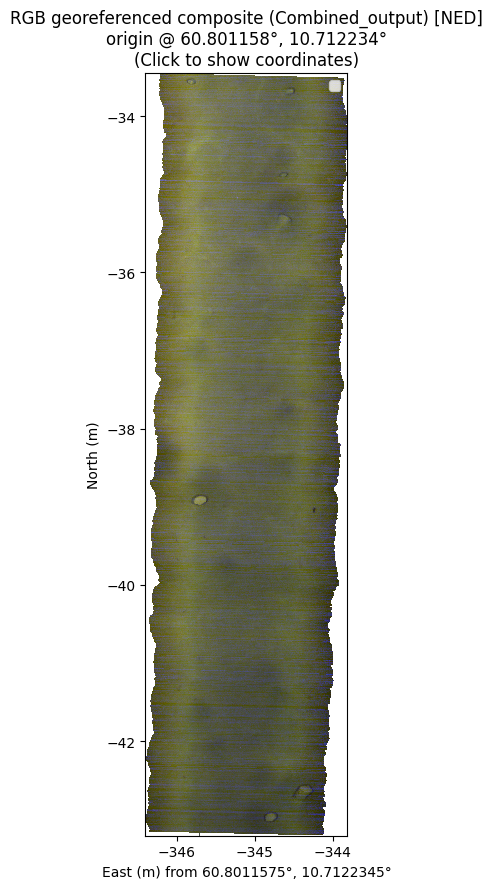

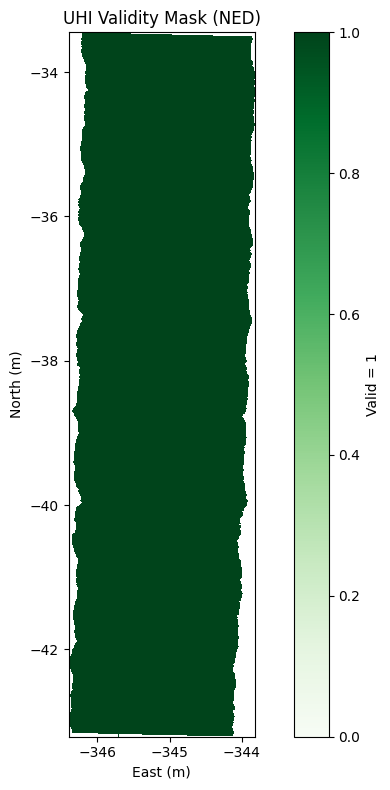

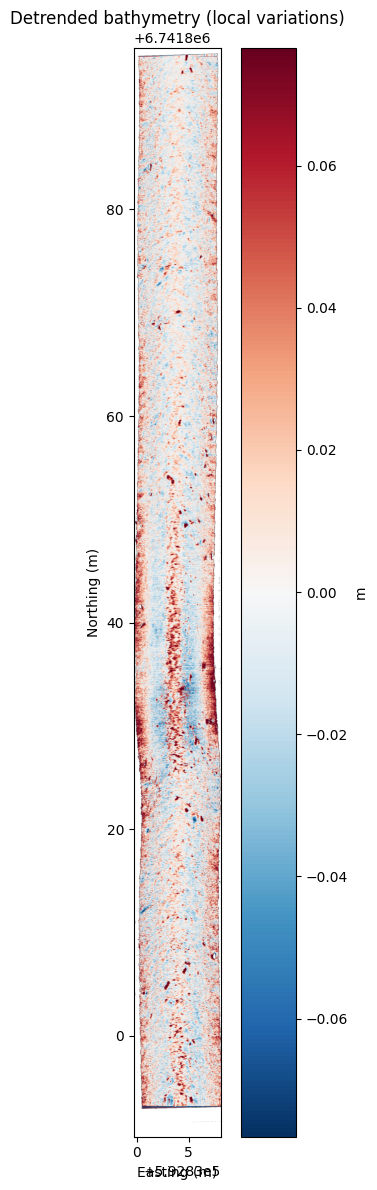

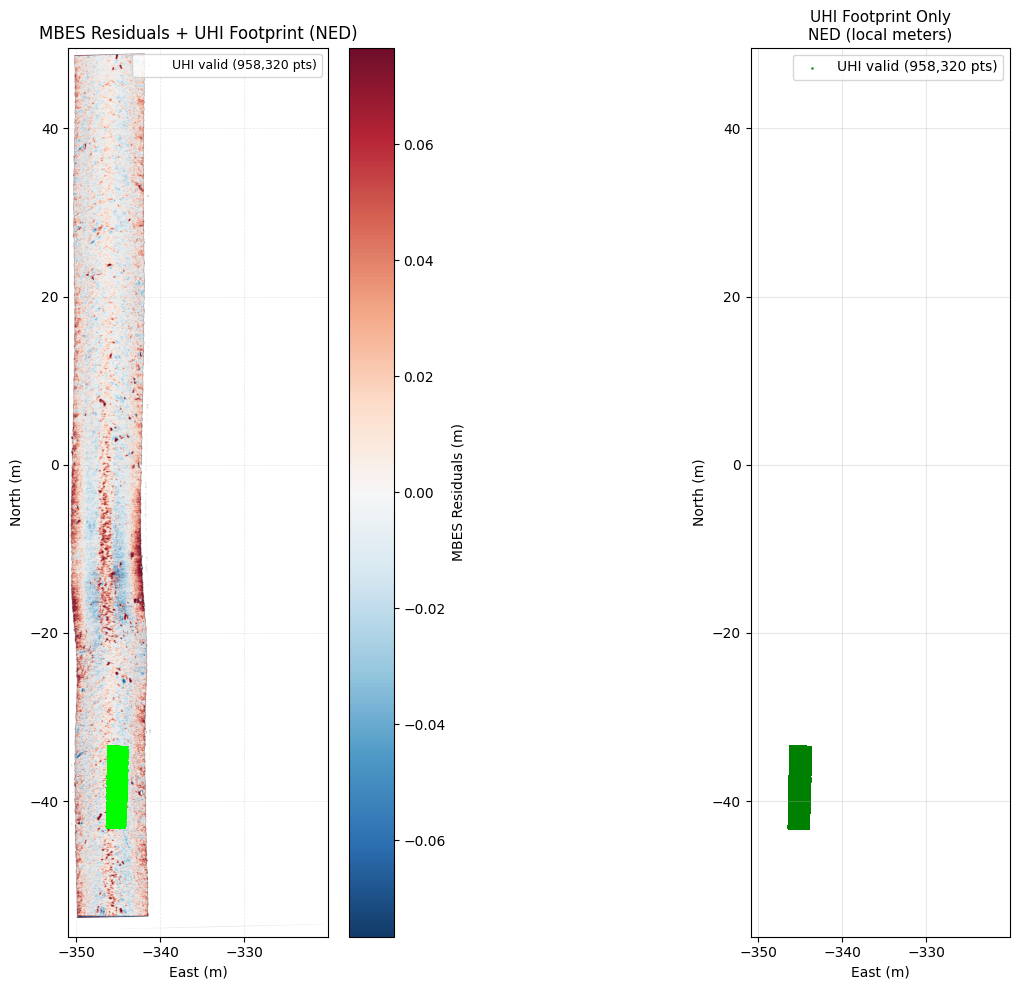

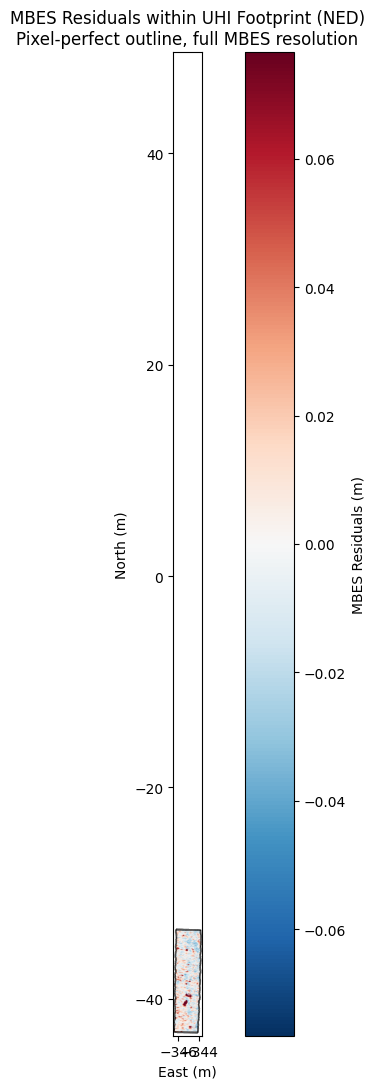

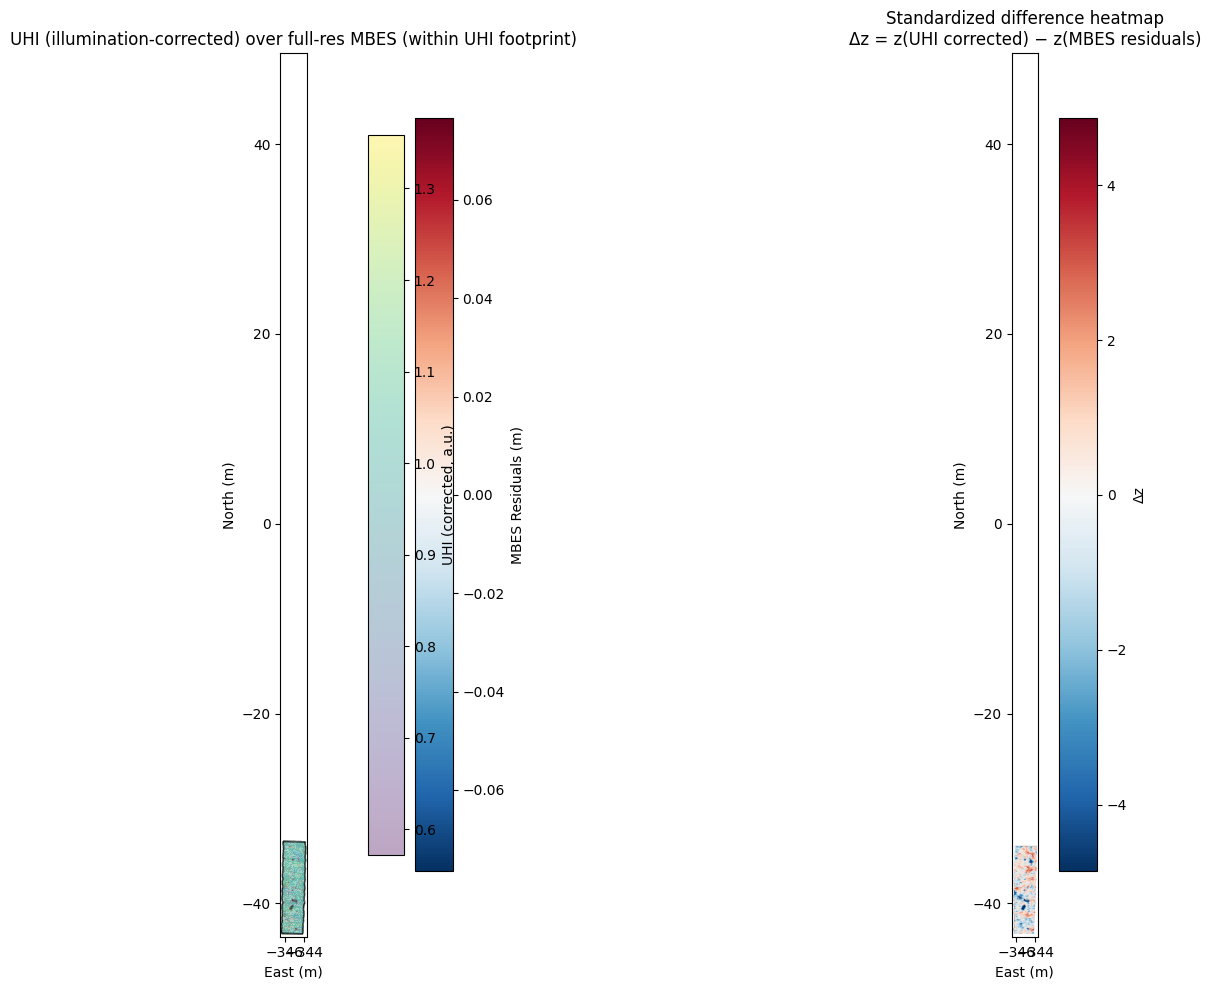


================  ✅ All figures opened (originals + new fig5 + new fig6)  ================



In [ ]:
# ============================
# 6) NEW figure: UHI (illumination-corrected) + MBES (left) and standardized difference (right)
# ============================
print(
    "\n🆕  Preparing Plot 6: UHI (illumination-corrected) vs MBES — overlay + difference heatmap"
)

# 6a) Apply illumination correction (now with automatic save/load!)
#     First run: computes and saves to HDF5 files (slow)
#     Subsequent runs: loads from disk if parameters match (fast!)
cube.apply_illumination_correction(window_size=1000, strength=1.0)

# Choose a UHI band to compare (green ~560 nm is a safe default)
wavelengths = cube.wavelengths


def _nearest_band_idx(wl_nm: float):
    return int(np.argmin(np.abs(wavelengths - wl_nm)))


idx_green = _nearest_band_idx(560.0)

# Extract corrected UHI band for the same track slice
uhi_corr = cube.data_corrected[track_start:track_end, :, idx_green]  # shape (T,S)

# Build exact UHI footprint (corners path) to clip/limit to overlap region
Xc_uhi, Yc_uhi = pcolormesh_pad(E, N)
segs_xy, segs_idx = _boundary_segments_from_mask(full_valid, Xc_uhi, Yc_uhi)
loops = _trace_loops_from_segments(segs_idx)
footprint_path = _compound_path_from_loops(loops, Xc_uhi, Yc_uhi)

# MBES grid in NED (recompute here to keep this figure independent)
MBES_X, MBES_Y = np.meshgrid(mb.x_cols, mb.y_rows)
epsg_src = mb.epsg if mb.epsg is not None else 32633
tf_to_ll = Transformer.from_crs(f"EPSG:{epsg_src}", "EPSG:4326", always_xy=True)
mbes_lon, mbes_lat = tf_to_ll.transform(MBES_X, MBES_Y)
tf_geo_to_ecef = Transformer.from_crs("EPSG:4979", "EPSG:4978", always_xy=True)
mbes_x_ecef, mbes_y_ecef, mbes_z_ecef = tf_geo_to_ecef.transform(
    mbes_lon, mbes_lat, np.zeros_like(mbes_lon)
)
mbes_n_ned, mbes_e_ned, _ = _ecef_to_ned_arrays(
    mbes_x_ecef, mbes_y_ecef, mbes_z_ecef, lat0, lon0, h0
)

# Determine which MBES pixel centers fall inside the UHI footprint
pts_mbes = np.column_stack([mbes_e_ned.ravel(), mbes_n_ned.ravel()])
inside = footprint_path.contains_points(pts_mbes).reshape(mbes_e_ned.shape)

# Resample UHI (illum-corrected) to the MBES grid via nearest neighbor
valid_uhi = full_valid & np.isfinite(uhi_corr) & np.isfinite(E) & np.isfinite(N)
if not np.any(valid_uhi):
    print("⚠️  No valid UHI pixels for resampling.")
    uhi_on_mbes = np.full(mb.residuals.shape, np.nan, dtype=float)
else:
    uhi_pts = np.column_stack([E[valid_uhi], N[valid_uhi]])
    uhi_vals = uhi_corr[valid_uhi]
    tree = cKDTree(uhi_pts)
    # Only query for MBES pixels inside the footprint to keep it fast
    idx_inside = np.where(inside.ravel())[0]
    d, nn = tree.query(pts_mbes[idx_inside], k=1)
    uhi_on_mbes_flat = np.full(pts_mbes.shape[0], np.nan, dtype=float)
    uhi_on_mbes_flat[idx_inside] = uhi_vals[nn]
    uhi_on_mbes = uhi_on_mbes_flat.reshape(mbes_e_ned.shape)

# Build standardized difference: robust z-scores then Δz = z_UHI - z_MBES
mbes_in = np.where(inside, mb.residuals, np.nan)
uhi_in = np.where(inside, uhi_on_mbes, np.nan)


def _robust_z(a):
    m = np.nanmedian(a)
    finite = np.isfinite(a)
    if np.any(finite):
        mad = median_abs_deviation(a[finite], scale="normal")
    else:
        mad = np.nan
    if not np.isfinite(mad) or mad == 0:
        mad = 1.0
    return (a - m) / mad


z_mbes = _robust_z(mbes_in)
z_uhi = _robust_z(uhi_in)
diff_z = z_uhi - z_mbes
# Robust symmetric limits for plotting
finite_diff = np.isfinite(diff_z)
if np.any(finite_diff):
    vmax_diff = np.nanpercentile(np.abs(diff_z[finite_diff]), 98.0)
else:
    vmax_diff = 1.0
vmin_diff = -vmax_diff

# ---- Make FIGURE 6 ----
fig6, (axL, axR) = plt.subplots(
    1, 2, figsize=(18, 10), num="Figure 6: UHI(corrected)+MBES & Difference"
)

# LEFT: MBES full-res (clipped) + semi-transparent UHI (illum-corrected)
extent_ned = [
    np.min(mbes_e_ned),
    np.max(mbes_e_ned),
    np.min(mbes_n_ned),
    np.max(mbes_n_ned),
]
im_mbes = axL.imshow(
    np.ma.masked_invalid(mb.residuals),
    extent=extent_ned,
    origin="upper",
    cmap="RdBu_r",
    vmin=mb._robust_sym_vlim(mb.residuals, q=0.98)[0],
    vmax=mb._robust_sym_vlim(mb.residuals, q=0.98)[1],
)
# Clip to footprint
axL_img_patch = PathPatch(footprint_path, transform=axL.transData, facecolor="none")
im_mbes.set_clip_path(axL_img_patch)

# Overlay UHI (illum-corrected) on its native grid (no smoothing), semi-transparent
Xc_show, Yc_show = pcolormesh_pad(E, N)
im_uhi = axL.pcolormesh(
    Xc_show, Yc_show, uhi_corr, shading="flat", cmap="viridis", alpha=0.35
)

# Jagged outline
segs_xy_plot, _ = _boundary_segments_from_mask(full_valid, Xc_uhi, Yc_uhi)
if len(segs_xy_plot) > 0:
    axL.add_collection(
        LineCollection(segs_xy_plot, colors="k", linewidths=1.1, alpha=0.9)
    )

# Zoom to footprint with padding
xs_outline = footprint_path.vertices[:, 0]
ys_outline = footprint_path.vertices[:, 1]
x_min, x_max = np.nanmin(xs_outline), np.nanmax(xs_outline)
y_min, y_max = np.nanmin(ys_outline), np.nanmax(ys_outline)
_pad_limits(axL, x_min, x_max, y_min, y_max, pad_frac=0.03, equal_aspect=True)
axL.set_title("UHI (illumination-corrected) over full-res MBES (within UHI footprint)")
axL.set_xlabel("East (m)")
axL.set_ylabel("North (m)")
cbarL1 = fig6.colorbar(im_mbes, ax=axL, fraction=0.035, pad=0.01)
cbarL1.set_label("MBES Residuals (m)")
cbarL2 = fig6.colorbar(im_uhi, ax=axL, fraction=0.035, pad=0.06)
cbarL2.set_label("UHI (corrected, a.u.)")

# RIGHT: standardized difference heatmap (z_UHI - z_MBES) on MBES grid
im_diff = axR.imshow(
    np.ma.masked_invalid(diff_z),
    extent=extent_ned,
    origin="upper",
    cmap="RdBu_r",
    vmin=vmin_diff,
    vmax=vmax_diff,
)
# Clip to footprint as well
axR_img_patch = PathPatch(footprint_path, transform=axR.transData, facecolor="none")
im_diff.set_clip_path(axR_img_patch)

_pad_limits(axR, x_min, x_max, y_min, y_max, pad_frac=0.03, equal_aspect=True)
axR.set_title(
    "Standardized difference heatmap\nΔz = z(UHI corrected) − z(MBES residuals)"
)
axR.set_xlabel("East (m)")
axR.set_ylabel("North (m)")
fig6.colorbar(im_diff, ax=axR, fraction=0.035, pad=0.02, label="Δz")

fig6.tight_layout()

# Safe tight_layout where applicable
try:
    fig2.tight_layout()
except Exception:
    pass

# Show all open figures together
plt.show()

print(
    "\n================  ✅ All figures opened (originals + new fig5 + new fig6)  ================\n"
)

🔄 Rebuilding grids from georef hits for selected files...
   • rad_uhi_20241029_115057_4
  rad_uhi_20241029_115057_4: Using GRIDDED format (T=2463, S=968)
  rad_uhi_20241029_115057_4: Using GRIDDED format (T=2463, S=968)
   • rad_uhi_20241029_115057_5
   • rad_uhi_20241029_115057_5
  rad_uhi_20241029_115057_5: Using GRIDDED format (T=2462, S=968)
  rad_uhi_20241029_115057_5: Using GRIDDED format (T=2462, S=968)
✅ Combined shapes: X/Y/Z (4925, 968), RGB (4925, 968)
🔄 Computing illumination correction: rolling (window=1000), strength=1.0
✅ Combined shapes: X/Y/Z (4925, 968), RGB (4925, 968)
🔄 Computing illumination correction: rolling (window=1000), strength=1.0


   Processing slits: 100%|██████████| 968/968 [04:39<00:00,  3.46slit/s]



✅ data_corrected ready (rolling (window=1000))
💾 Saving illumination correction to 2 files...
   ✓ rad_uhi_20241029_115057_4: saved (2463, 968, 210)
   ✓ rad_uhi_20241029_115057_4: saved (2463, 968, 210)
   ✓ rad_uhi_20241029_115057_5: saved (2462, 968, 210)
   ✓ rad_uhi_20241029_115057_5: saved (2462, 968, 210)
✅ Illumination correction saved to disk
✅ Illumination correction saved to disk


C:\Users\Erik Liu\AppData\Local\Temp\ipykernel_39376\2170383676.py:157: RuntimeWarning: All-NaN slice encountered
  m = np.nanmedian(a)


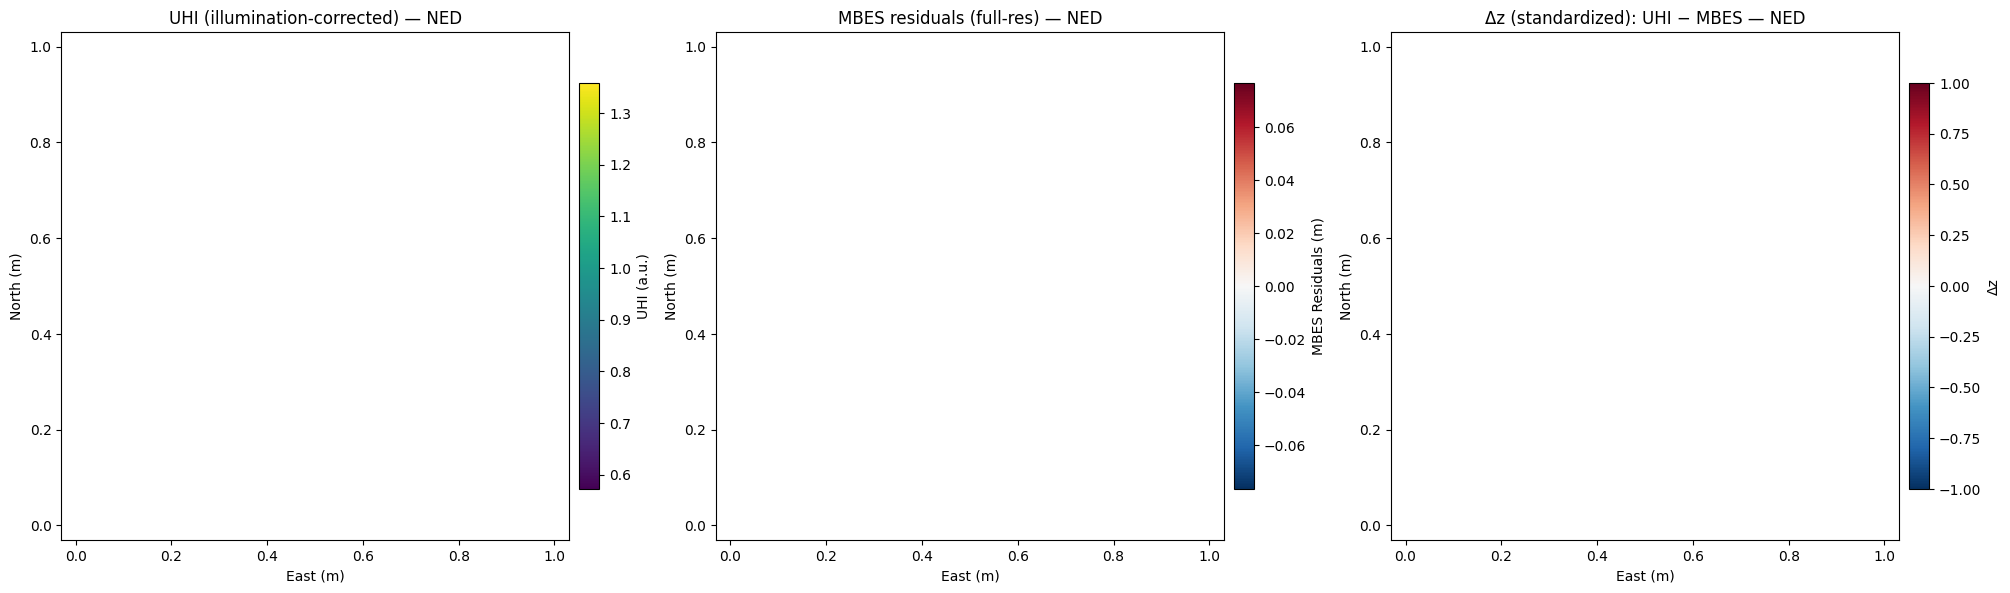

In [5]:
# === Figure 6 (three panels): UHI(corrected) | MBES | Δz (NED) ===
# This cell is self-contained: it finds your repo, imports utils.georef + config,
# creates transect/cube if missing, applies illumination correction (with your persistence),
# and draws Fig 6 with tight framing and the jagged UHI outline.

import sys, os
from pathlib import Path
import importlib

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec
from matplotlib.path import Path as MplPath
from matplotlib.patches import PathPatch
from matplotlib.collections import LineCollection

from scipy.spatial import cKDTree
from scipy.stats import median_abs_deviation
from scipy.signal import savgol_filter
from pyproj import Transformer
import rasterio


# ------------------------------------------------------------
# 0) Find and add repo root so `utils` and `config` import OK
# ------------------------------------------------------------
def _add_repo_to_sys_path():
    here = Path.cwd()
    candidates = [here, *here.parents]
    for p in candidates:
        if (p / "utils" / "georef.py").exists() and (p / "config.py").exists():
            if str(p) not in sys.path:
                sys.path.insert(0, str(p))
            return p
    raise ImportError(
        "Could not locate repo root with 'utils/georef.py' and 'config.py'. "
        "Run this cell from inside the project, or adjust the search logic above."
    )


REPO_ROOT = _add_repo_to_sys_path()

# ------------------------------------------------------------
# 1) Repo imports
# ------------------------------------------------------------
from utils import georef
import config

importlib.reload(georef)  # pick up local edits

from utils.georef import (
    _ecef_to_ned_arrays,
)  # use the same helper as the rest of your code


# ------------------------------------------------------------
# 2) Helpers (outline, padding, corners)
# ------------------------------------------------------------
def _pad_limits(ax, x_min, x_max, y_min, y_max, pad_frac=0.03, equal_aspect=True):
    xr = max(1e-12, x_max - x_min)
    yr = max(1e-12, y_max - y_min)
    ax.set_xlim(x_min - xr * pad_frac, x_max + xr * pad_frac)
    ax.set_ylim(y_min - yr * pad_frac, y_max + yr * pad_frac)
    if equal_aspect:
        ax.set_aspect("equal", adjustable="box")


def pcolormesh_pad(X, Y):
    Xc = np.pad(X, ((0, 1), (0, 1)), mode="edge")
    Yc = np.pad(Y, ((0, 1), (0, 1)), mode="edge")
    return Xc, Yc


def _build_full_valid(X, Y, Z, R, G, B):
    coords_valid = np.isfinite(X) & np.isfinite(Y) & np.isfinite(Z)
    rgb_valid = np.isfinite(R) & np.isfinite(G) & np.isfinite(B)
    return coords_valid & rgb_valid


def _boundary_segments_from_mask(mask_bool, Xc, Yc):
    """
    Build jagged outline segments from a boolean mask aligned to pcolormesh corners Xc,Yc.
    Returns:
      segs_xy: list of ((x0,y0),(x1,y1)) segments to draw
      segs_idx: same in integer-corner index space ((i0,j0),(i1,j1)) for path building
    """
    mask = mask_bool.astype(bool)
    T, S = mask.shape
    segs_xy, segs_idx = [], []

    # vertical boundaries between columns
    diff_h = mask[:, :-1] ^ mask[:, 1:]
    ih, jh = np.where(diff_h)
    for i, j in zip(ih, jh):
        p0 = (i, j + 1)
        p1 = (i + 1, j + 1)
        segs_xy.append(((float(Xc[p0]), float(Yc[p0])), (float(Xc[p1]), float(Yc[p1]))))
        segs_idx.append((p0, p1))

    # horizontal boundaries between rows
    diff_v = mask[:-1, :] ^ mask[1:, :]
    iv, jv = np.where(diff_v)
    for i, j in zip(iv, jv):
        p0 = (i + 1, j)
        p1 = (i + 1, j + 1)
        segs_xy.append(((float(Xc[p0]), float(Yc[p0])), (float(Xc[p1]), float(Yc[p1]))))
        segs_idx.append((p0, p1))

    return segs_xy, segs_idx


def _trace_loops_from_segments(segs_idx):
    """Trace closed loops (lists of corner indices) from boundary segments."""
    adj = {}
    for a, b in segs_idx:
        adj.setdefault(a, []).append(b)
        adj.setdefault(b, []).append(a)

    visited_edges = set()
    loops = []

    for start in list(adj.keys()):
        for nxt in adj[start]:
            edge = (start, nxt) if start <= nxt else (nxt, start)
            if edge in visited_edges:
                continue
            loop = [start, nxt]
            visited_edges.add(edge)
            prev, cur = start, nxt
            while True:
                neigh = adj.get(cur, [])
                nxt2 = None
                for cand in neigh:
                    if cand != prev:
                        e = (cur, cand) if cur <= cand else (cand, cur)
                        if e not in visited_edges:
                            nxt2 = cand
                            visited_edges.add(e)
                            break
                if nxt2 is None:
                    break
                loop.append(nxt2)
                if nxt2 == start:
                    loops.append(loop)
                    break
                prev, cur = cur, nxt2

    closed = [L for L in loops if len(L) >= 2 and L[0] == L[-1]]
    return closed


def _compound_path_from_loops(loops, Xc, Yc):
    """Create a Matplotlib Path from traced loops (union)."""
    verts, codes = [], []
    for loop in loops:
        for k, (i, j) in enumerate(loop):
            x, y = float(Xc[i, j]), float(Yc[i, j])
            verts.append((x, y))
            codes.append(MplPath.MOVETO if k == 0 else MplPath.LINETO)
        verts.append((0.0, 0.0))
        codes.append(MplPath.CLOSEPOLY)
    if not verts:  # fallback safe square
        verts = [(0, 0), (1, 0), (1, 1), (0, 1), (0, 0)]
        codes = [
            MplPath.MOVETO,
            MplPath.LINETO,
            MplPath.LINETO,
            MplPath.LINETO,
            MplPath.CLOSEPOLY,
        ]
    return MplPath(verts, codes)


def _robust_z(a):
    m = np.nanmedian(a)
    finite = np.isfinite(a)
    mad = median_abs_deviation(a[finite], scale="normal") if np.any(finite) else np.nan
    if not np.isfinite(mad) or mad == 0:
        mad = 1.0
    return (a - m) / mad


# ------------------------------------------------------------
# 3) MBES loader/detrender (minimal, self-contained)
# ------------------------------------------------------------
class MBESDetrender:
    def __init__(
        self,
        tif_path,
        nodata_value=9999.0,
        smooth_baseline_m=0.5,
        smooth_tilt_m=0.5,
        smooth_center_m=1.0,
    ):
        self.tif_path = tif_path
        self.nodata_value = nodata_value
        self.smooth_baseline_m = smooth_baseline_m
        self.smooth_tilt_m = smooth_tilt_m
        self.smooth_center_m = smooth_center_m

        self.data = None
        self.valid_mask = None
        self.transform = None
        self.extent = None
        self.px_x = None
        self.px_y = None
        self.x_cols = None
        self.y_rows = None
        self.epsg = None

        self.A_s = self.B_s = self.C_s = None
        self.trend = None
        self.residuals = None

    def load(self):
        with rasterio.open(self.tif_path) as src:
            z = src.read(1).astype(np.float64)
            tf = src.transform
            bounds = src.bounds
            self.epsg = src.crs.to_epsg() if src.crs else None

        if self.nodata_value is not None:
            z = np.where(z == self.nodata_value, np.nan, z)

        self.valid_mask = np.isfinite(z)
        a, b, c, d, e, f = tf.a, tf.b, tf.c, tf.d, tf.e, tf.f
        H, W = z.shape
        cols = np.arange(W)
        rows = np.arange(H)
        self.x_cols = c + a * (cols + 0.5)
        self.y_rows = f + e * (rows + 0.5)
        self.px_x = abs(a)
        self.px_y = abs(e)
        self.data = z
        self.transform = tf
        self.extent = (
            float(bounds.left),
            float(bounds.right),
            float(bounds.bottom),
            float(bounds.top),
        )
        return self

    def detrend(self, order_x=2, robust=True, central_frac=0.8, max_row_iters=3):
        if self.data is None:
            self.load()
        z = self.data
        x = self.x_cols
        H, W = z.shape
        valid_rows = np.any(self.valid_mask, axis=1)
        valid_row_indices = np.where(valid_rows)[0]

        A = np.full(H, np.nan)
        B = np.full(H, 0.0)
        C = np.full(H, 0.0)

        for i in valid_row_indices:
            row = z[i, :]
            m = np.isfinite(row)
            if m.sum() < 6:
                continue
            xv = x[m]
            yv = row[m]
            xc_row = np.median(xv)

            if 0 < central_frac < 1:
                lo = np.quantile(xv, 0.5 - 0.5 * central_frac)
                hi = np.quantile(xv, 0.5 + 0.5 * central_frac)
                keep = (xv >= lo) & (xv <= hi)
                xv, yv = xv[keep], yv[keep]

            xi = xv - xc_row
            deg = min(order_x, 2)
            coef = np.polyfit(xi, yv, deg)
            if deg == 0:
                a0, a1, a2 = float(coef[0]), 0.0, 0.0
            elif deg == 1:
                a1, a0 = float(coef[0]), float(coef[1])
                a2 = 0.0
            else:
                a2, a1, a0 = float(coef[0]), float(coef[1]), float(coef[2])

            if robust and deg > 0:
                for _ in range(max_row_iters):
                    pred = a0 + a1 * xi + a2 * (xi**2)
                    resid = yv - pred
                    s = median_abs_deviation(resid, scale="normal")
                    if not np.isfinite(s) or s == 0:
                        break
                    w = 1.0 / (1.0 + (resid / (3 * s)) ** 2)
                    X = np.vstack([np.ones_like(xi), xi])
                    if deg == 2:
                        X = np.vstack([X, xi**2])
                    XtW = X * w
                    beta = np.linalg.lstsq(XtW.T, (yv * w), rcond=None)[0]
                    if deg == 2:
                        a0, a1, a2 = float(beta[0]), float(beta[1]), float(beta[2])
                    else:
                        a0, a1 = float(beta[0]), float(beta[1])
                        a2 = 0.0

            A[i], B[i], C[i] = a0, a1, a2

        def smooth_1d(arr, scale_m):
            if scale_m <= 0 or self.px_y <= 0:
                return arr
            m = np.isfinite(arr)
            if m.sum() < 5:
                return arr
            w = max(3, int(np.round(scale_m / self.px_y)))
            if w % 2 == 0:
                w += 1
            w = min(w, m.sum() - 1 if m.sum() > 1 else 1)
            if w < 3:
                return arr
            out = arr.copy()
            out[m] = savgol_filter(arr[m], window_length=w, polyorder=2)
            return out

        self.A_s = smooth_1d(A, self.smooth_baseline_m)
        self.B_s = smooth_1d(B, self.smooth_tilt_m)
        self.C_s = smooth_1d(C, self.smooth_tilt_m)

        trend = np.full_like(z, np.nan)
        for i in valid_row_indices:
            if not np.isfinite(self.A_s[i]):
                continue
            xc = np.median(x[np.isfinite(z[i, :])])
            xi = x - xc
            trend[i, :] = self.A_s[i] + self.B_s[i] * xi + self.C_s[i] * xi**2

        self.trend = trend
        self.residuals = z - trend
        return self

    def _robust_sym_vlim(self, arr, q=0.98):
        finite = arr[np.isfinite(arr)]
        if len(finite) == 0:
            return -1, 1
        vmax = np.quantile(np.abs(finite), q)
        return -vmax, vmax


# ------------------------------------------------------------
# 4) Build transect/cube (robust) + slice + NED + mask
# ------------------------------------------------------------
transect = georef.load_transect(config.OUTPUT_FOLDER)

# Try user-specified files; if they’re not present, fall back to all files.
try:
    cube = transect.select_files(
        [
            "rad_uhi_20241029_115057_4",
            "rad_uhi_20241029_115057_5",
        ]
    )
except Exception:
    cube = transect.select_all_files()

# Track slice (use your previous range if you want)
track_start = 3039 if cube.X_ecef.shape[0] > 4029 else 0
track_end = 4029 if cube.X_ecef.shape[0] > 4029 else cube.X_ecef.shape[0]

# UHI arrays/slice
X = cube.X_ecef[track_start:track_end, :]
Y = cube.Y_ecef[track_start:track_end, :]
Z = cube.Z_ecef[track_start:track_end, :]
R = cube.R[track_start:track_end, :]
G = cube.G[track_start:track_end, :]
B = cube.B[track_start:track_end, :]

lat0, lon0, h0 = config.LAT0, config.LON0, config.H0
N, E, D = _ecef_to_ned_arrays(X, Y, Z, lat0, lon0, h0)
full_valid = _build_full_valid(X, Y, Z, R, G, B)

# ------------------------------------------------------------
# 5) Illumination correction (uses your persistent method)
# ------------------------------------------------------------
if not hasattr(cube, "apply_illumination_correction"):
    raise AttributeError(
        "cube.apply_illumination_correction(...) not found on your Cube class."
    )

cube.apply_illumination_correction(
    window_size=1000, strength=1.0
)  # loads fast if already saved
wavelengths = cube.wavelengths
idx_green = int(np.argmin(np.abs(wavelengths - 560.0)))  # ~560 nm
uhi_corr = cube.data_corrected[track_start:track_end, :, idx_green]  # (T,S)

# ------------------------------------------------------------
# 6) Build jagged footprint path from mask (no smoothing)
# ------------------------------------------------------------
Xc_uhi, Yc_uhi = pcolormesh_pad(E, N)
segs_xy, segs_idx = _boundary_segments_from_mask(full_valid, Xc_uhi, Yc_uhi)
loops = _trace_loops_from_segments(segs_idx)
footprint_path = _compound_path_from_loops(loops, Xc_uhi, Yc_uhi)
xs_outline = footprint_path.vertices[:, 0]
ys_outline = footprint_path.vertices[:, 1]
x_min, x_max = np.nanmin(xs_outline), np.nanmax(xs_outline)
y_min, y_max = np.nanmin(ys_outline), np.nanmax(ys_outline)

# ------------------------------------------------------------
# 7) MBES residuals in NED (same local frame as UHI)
# ------------------------------------------------------------
mb = MBESDetrender(
    config.MBES_GEOTIFF, smooth_baseline_m=0.5, smooth_tilt_m=0.5, smooth_center_m=1.0
).load()
mb.detrend(order_x=2, robust=True, central_frac=0.8)

MBES_X, MBES_Y = np.meshgrid(mb.x_cols, mb.y_rows)
epsg_src = mb.epsg if mb.epsg is not None else 32633
tf_to_ll = Transformer.from_crs(f"EPSG:{epsg_src}", "EPSG:4326", always_xy=True)
mbes_lon, mbes_lat = tf_to_ll.transform(MBES_X, MBES_Y)

tf_geo_to_ecef = Transformer.from_crs("EPSG:4979", "EPSG:4978", always_xy=True)
mbes_x_ecef, mbes_y_ecef, mbes_z_ecef = tf_geo_to_ecef.transform(
    mbes_lon, mbes_lat, np.zeros_like(mbes_lon)
)
mbes_n_ned, mbes_e_ned, _ = _ecef_to_ned_arrays(
    mbes_x_ecef, mbes_y_ecef, mbes_z_ecef, lat0, lon0, h0
)
extent_ned = [
    np.min(mbes_e_ned),
    np.max(mbes_e_ned),
    np.min(mbes_n_ned),
    np.max(mbes_n_ned),
]

# MBES pixels inside footprint
pts_mbes = np.column_stack([mbes_e_ned.ravel(), mbes_n_ned.ravel()])
inside = footprint_path.contains_points(pts_mbes).reshape(mbes_e_ned.shape)

# ------------------------------------------------------------
# 8) Resample UHI(corrected) to MBES grid (nearest) for Δz
# ------------------------------------------------------------
valid_uhi = full_valid & np.isfinite(uhi_corr) & np.isfinite(E) & np.isfinite(N)
if np.any(valid_uhi):
    uhi_pts = np.column_stack([E[valid_uhi], N[valid_uhi]])
    uhi_vals = uhi_corr[valid_uhi]
    tree = cKDTree(uhi_pts)
    idx_inside = np.where(inside.ravel())[0]
    d, nn = tree.query(pts_mbes[idx_inside], k=1)
    uhi_on_mbes_flat = np.full(pts_mbes.shape[0], np.nan, dtype=float)
    uhi_on_mbes_flat[idx_inside] = uhi_vals[nn]
    uhi_on_mbes = uhi_on_mbes_flat.reshape(mbes_e_ned.shape)
else:
    uhi_on_mbes = np.full_like(mb.residuals, np.nan, dtype=float)

# standardized difference on MBES grid
mbes_in = np.where(inside, mb.residuals, np.nan)
uhi_in = np.where(inside, uhi_on_mbes, np.nan)
z_mbes = _robust_z(mbes_in)
z_uhi = _robust_z(uhi_in)
diff_z = z_uhi - z_mbes
finite_diff = np.isfinite(diff_z)
vmax_diff = (
    np.nanpercentile(np.abs(diff_z[finite_diff]), 98.0) if np.any(finite_diff) else 1.0
)
vmin_diff = -vmax_diff

# color limits for MBES
vmin_mbes, vmax_mbes = mb._robust_sym_vlim(mb.residuals, q=0.98)

# ------------------------------------------------------------
# 9) FIGURE 6: THREE PANELS (tight zoom, minimal whitespace)
# ------------------------------------------------------------
fig6 = plt.figure(
    constrained_layout=True, figsize=(20, 7), num="Figure 6: UHI | MBES | Δz (NED)"
)
gs = gridspec.GridSpec(ncols=3, nrows=1, figure=fig6, width_ratios=[1, 1, 1])

axU = fig6.add_subplot(gs[0, 0])  # UHI
axM = fig6.add_subplot(gs[0, 1])  # MBES
axD = fig6.add_subplot(gs[0, 2])  # Δz

# LEFT: UHI (illumination-corrected) on native grid; clip to footprint; jagged outline
uhi_plot = uhi_corr.copy()
uhi_plot[~full_valid] = np.nan
Xc_show, Yc_show = Xc_uhi, Yc_uhi
im_uhi = axU.pcolormesh(Xc_show, Yc_show, uhi_plot, shading="flat", cmap="viridis")
im_uhi.set_clip_path(
    PathPatch(footprint_path, transform=axU.transData, facecolor="none")
)
if len(segs_xy) > 0:
    axU.add_collection(LineCollection(segs_xy, colors="k", linewidths=1.0, alpha=0.9))
_pad_limits(axU, x_min, x_max, y_min, y_max, pad_frac=0.03, equal_aspect=True)
axU.set_title("UHI (illumination-corrected) — NED")
axU.set_xlabel("East (m)")
axU.set_ylabel("North (m)")
fig6.colorbar(im_uhi, ax=axU, fraction=0.04, pad=0.02, label="UHI (a.u.)")

# MIDDLE: MBES residuals (full res) clipped to identical footprint
im_mbes = axM.imshow(
    np.ma.masked_invalid(mb.residuals),
    extent=extent_ned,
    origin="upper",
    cmap="RdBu_r",
    vmin=vmin_mbes,
    vmax=vmax_mbes,
)
im_mbes.set_clip_path(
    PathPatch(footprint_path, transform=axM.transData, facecolor="none")
)
_pad_limits(axM, x_min, x_max, y_min, y_max, pad_frac=0.03, equal_aspect=True)
axM.set_title("MBES residuals (full-res) — NED")
axM.set_xlabel("East (m)")
axM.set_ylabel("North (m)")
fig6.colorbar(im_mbes, ax=axM, fraction=0.04, pad=0.02, label="MBES Residuals (m)")

# RIGHT: standardized difference Δz = z(UHI) − z(MBES) (on MBES grid), clipped
im_diff = axD.imshow(
    np.ma.masked_invalid(diff_z),
    extent=extent_ned,
    origin="upper",
    cmap="RdBu_r",
    vmin=vmin_diff,
    vmax=vmax_diff,
)
im_diff.set_clip_path(
    PathPatch(footprint_path, transform=axD.transData, facecolor="none")
)
_pad_limits(axD, x_min, x_max, y_min, y_max, pad_frac=0.03, equal_aspect=True)
axD.set_title("Δz (standardized): UHI − MBES — NED")
axD.set_xlabel("East (m)")
axD.set_ylabel("North (m)")
fig6.colorbar(im_diff, ax=axD, fraction=0.04, pad=0.02, label="Δz")

plt.show()
# === end ===

🔄 Rebuilding grids from georef hits for selected files...
   • rad_uhi_20241029_115057_4
  rad_uhi_20241029_115057_4: Using GRIDDED format (T=2463, S=968)
  rad_uhi_20241029_115057_4: Using GRIDDED format (T=2463, S=968)
   • rad_uhi_20241029_115057_5
   • rad_uhi_20241029_115057_5
  rad_uhi_20241029_115057_5: Using GRIDDED format (T=2462, S=968)
  rad_uhi_20241029_115057_5: Using GRIDDED format (T=2462, S=968)
✅ Combined shapes: X/Y/Z (4925, 968), RGB (4925, 968)
✅ Illumination correction already applied with window=1000, strength=1.0
   Loading from disk...
📂 Loading saved illumination correction from 2 files...
✅ Combined shapes: X/Y/Z (4925, 968), RGB (4925, 968)
✅ Illumination correction already applied with window=1000, strength=1.0
   Loading from disk...
📂 Loading saved illumination correction from 2 files...
   rad_uhi_20241029_115057_4: window=1000, strength=1.0
   rad_uhi_20241029_115057_4: window=1000, strength=1.0
   rad_uhi_20241029_115057_5: window=1000, strength=1.0
✅ L

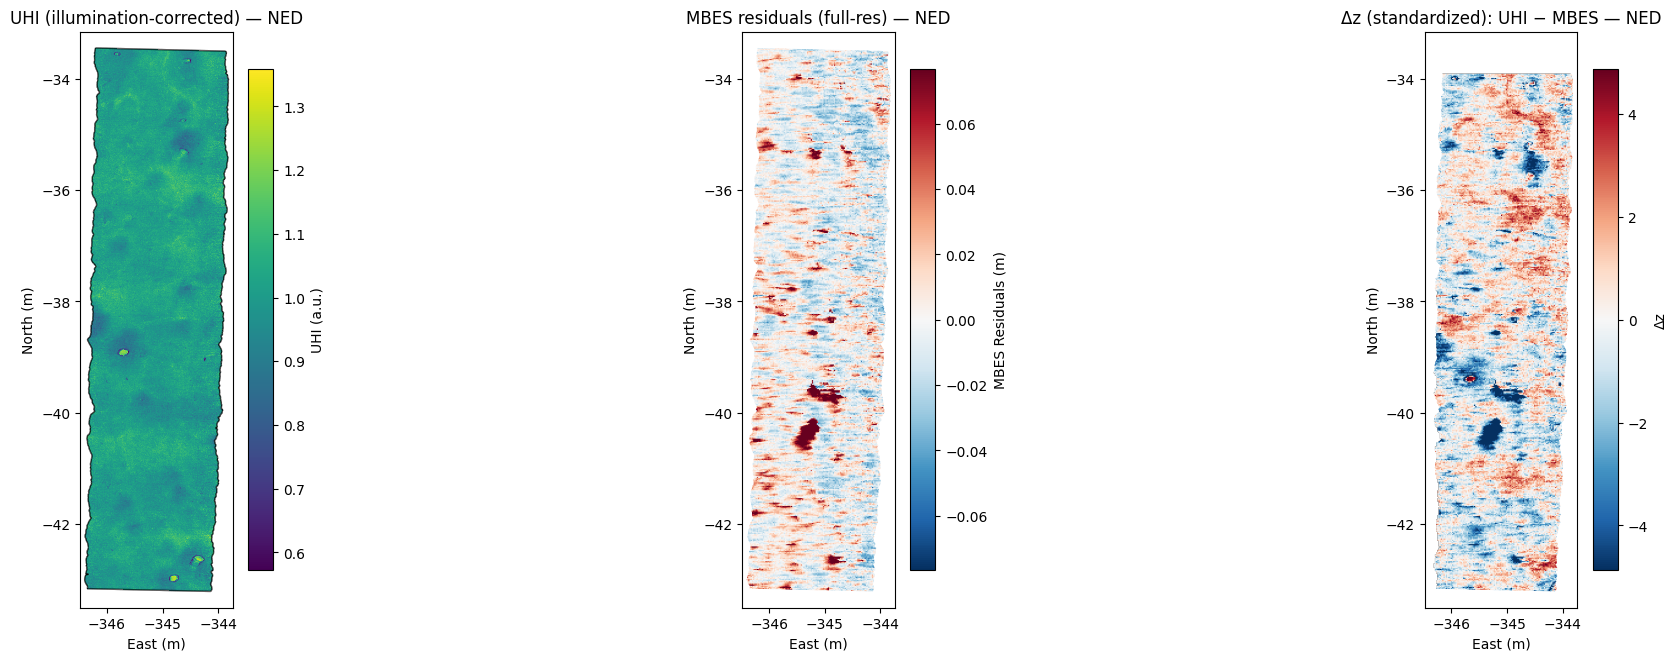

In [6]:
# === Figure 6 (three panels): UHI(corrected) | MBES | Δz (NED) ===
# Self-contained: fixes the “blank 0–1 axes” bug by using a boundary
# builder that includes OUTER EDGES of the UHI mask (no smoothing).

import sys, os
from pathlib import Path
import importlib
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec
from matplotlib.path import Path as MplPath
from matplotlib.patches import PathPatch
from matplotlib.collections import LineCollection
from scipy.spatial import cKDTree
from scipy.stats import median_abs_deviation
from pyproj import Transformer
import rasterio


# -----------------------------
# Locate repo (utils/, config)
# -----------------------------
def _add_repo_to_sys_path():
    here = Path.cwd()
    for p in [here, *here.parents]:
        if (p / "utils" / "georef.py").exists() and (p / "config.py").exists():
            sys.path.insert(0, str(p))
            return p
    raise ImportError(
        "Could not find repo root containing utils/georef.py and config.py"
    )


REPO_ROOT = _add_repo_to_sys_path()

from utils import georef
import config

importlib.reload(georef)
from utils.georef import _ecef_to_ned_arrays


# -----------------------------
# Helpers
# -----------------------------
def _pad_limits(ax, x_min, x_max, y_min, y_max, pad_frac=0.03, equal_aspect=True):
    xr = max(1e-12, x_max - x_min)
    yr = max(1e-12, y_max - y_min)
    ax.set_xlim(x_min - xr * pad_frac, x_max + xr * pad_frac)
    ax.set_ylim(y_min - yr * pad_frac, y_max + yr * pad_frac)
    if equal_aspect:
        ax.set_aspect("equal", adjustable="box")


def pcolormesh_pad(X, Y):
    Xc = np.pad(X, ((0, 1), (0, 1)), mode="edge")
    Yc = np.pad(Y, ((0, 1), (0, 1)), mode="edge")
    return Xc, Yc


def _build_full_valid(X, Y, Z, R, G, B):
    return (
        np.isfinite(X)
        & np.isfinite(Y)
        & np.isfinite(Z)
        & np.isfinite(R)
        & np.isfinite(G)
        & np.isfinite(B)
    )


def _boundary_segments_from_mask(mask: np.ndarray, Xc: np.ndarray, Yc: np.ndarray):
    """
    EXACT grid-edge outline including OUTER edges. This is the piece you were missing.
    Returns:
        segs_xy  : list of [[x0,y0],[x1,y1]] for plotting with LineCollection
        segs_idx : list of ((i0,j0),(i1,j1)) corner-index pairs to build paths
    """
    T, S = mask.shape
    segs_xy, segs_idx = [], []

    # internal vertical edges
    vdiff = mask[:, 1:] != mask[:, :-1]
    iv, jv = np.nonzero(vdiff)
    jline = jv + 1
    for i, j in zip(iv, jline):
        a = (i, j)
        b = (i + 1, j)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    # outer left (j=0) and right (j=S)
    i_left = np.nonzero(mask[:, 0])[0]
    for i in i_left:
        a = (i, 0)
        b = (i + 1, 0)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    i_right = np.nonzero(mask[:, -1])[0]
    for i in i_right:
        a = (i, S)
        b = (i + 1, S)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    # internal horizontal edges
    hdiff = mask[1:, :] != mask[:-1, :]
    ih, jh = np.nonzero(hdiff)
    iline = ih + 1
    for i, j in zip(iline, jh):
        a = (i, j)
        b = (i, j + 1)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    # outer top (i=0) and bottom (i=T)
    j_top = np.nonzero(mask[0, :])[0]
    for j in j_top:
        a = (0, j)
        b = (0, j + 1)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    j_bot = np.nonzero(mask[-1, :])[0]
    for j in j_bot:
        a = (T, j)
        b = (T, j + 1)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    return np.asarray(segs_xy, float), segs_idx


def _trace_loops_from_segments(segs_idx):
    """Turn corner-index segments into closed loops (rings)."""
    adj = {}
    for a, b in segs_idx:
        adj.setdefault(a, []).append(b)
        adj.setdefault(b, []).append(a)

    unvisited = set(frozenset((a, b)) for a, b in segs_idx)
    loops = []

    while unvisited:
        e = unvisited.pop()
        a, b = tuple(e)
        loop = [a, b]
        prev, cur = a, b
        while True:
            nbrs = adj.get(cur, [])
            nxt = next((n for n in nbrs if n != prev), None)
            if nxt is None:
                break
            edge = frozenset((cur, nxt))
            if edge in unvisited:
                unvisited.remove(edge)
            loop.append(nxt)
            prev, cur = cur, nxt
            if nxt == loop[0]:
                break
        loops.append(loop)

        # clean any remaining edges of this loop
        for i in range(len(loop) - 1):
            unvisited.discard(frozenset((loop[i], loop[i + 1])))

    return loops


def _compound_path_from_loops(loops, Xc, Yc):
    """Matplotlib Path from loops."""
    paths = []
    for ring in loops:
        xs = [Xc[idx] for idx in ring]
        ys = [Yc[idx] for idx in ring]
        if xs[0] != xs[-1] or ys[0] != ys[-1]:
            xs.append(xs[0])
            ys.append(ys[0])
        verts = np.column_stack([xs, ys])
        codes = np.full(len(verts), MplPath.LINETO, dtype=MplPath.code_type)
        codes[0] = MplPath.MOVETO
        codes[-1] = MplPath.CLOSEPOLY
        paths.append(MplPath(verts, codes))
    if len(paths) == 0:
        raise RuntimeError("Footprint loops empty — check your mask inputs.")
    if len(paths) == 1:
        return paths[0]
    return MplPath.make_compound_path(*paths)


def _robust_z(a):
    finite = np.isfinite(a)
    if not np.any(finite):
        return np.full_like(a, np.nan, dtype=float)
    m = np.nanmedian(a)
    mad = median_abs_deviation(a[finite], scale="normal")
    if not np.isfinite(mad) or mad == 0:
        mad = 1.0
    return (a - m) / mad


# -----------------------------
# MBES detrending (minimal)
# -----------------------------
class MBESDetrender:
    def __init__(
        self,
        tif_path,
        nodata_value=9999.0,
        smooth_baseline_m=0.5,
        smooth_tilt_m=0.5,
        smooth_center_m=1.0,
    ):
        self.tif_path = tif_path
        self.nodata_value = nodata_value
        self.smooth_baseline_m = smooth_baseline_m
        self.smooth_tilt_m = smooth_tilt_m
        self.smooth_center_m = smooth_center_m
        self.data = None
        self.valid_mask = None
        self.transform = None
        self.extent = None
        self.px_x = None
        self.px_y = None
        self.x_cols = None
        self.y_rows = None
        self.epsg = None
        self.A_s = self.B_s = self.C_s = None
        self.trend = None
        self.residuals = None

    def load(self):
        with rasterio.open(self.tif_path) as src:
            z = src.read(1).astype(np.float64)
            tf = src.transform
            bounds = src.bounds
            self.epsg = src.crs.to_epsg() if src.crs else None
        if self.nodata_value is not None:
            z = np.where(z == self.nodata_value, np.nan, z)
        self.valid_mask = np.isfinite(z)
        a, b, c, d, e, f = tf.a, tf.b, tf.c, tf.d, tf.e, tf.f
        H, W = z.shape
        cols = np.arange(W)
        rows = np.arange(H)
        self.x_cols = c + a * (cols + 0.5)
        self.y_rows = f + e * (rows + 0.5)
        self.px_x = abs(a)
        self.px_y = abs(e)
        self.data = z
        self.transform = tf
        self.extent = (
            float(bounds.left),
            float(bounds.right),
            float(bounds.bottom),
            float(bounds.top),
        )
        return self

    def detrend(self, order_x=2, robust=True, central_frac=0.8, max_row_iters=3):
        from scipy.signal import savgol_filter

        z = self.data if self.data is not None else self.load().data
        x = self.x_cols
        H, W = z.shape
        valid_rows = np.any(self.valid_mask, axis=1)
        idxs = np.where(valid_rows)[0]
        A = np.full(H, np.nan)
        B = np.full(H, 0.0)
        C = np.full(H, 0.0)
        for i in idxs:
            row = z[i, :]
            m = np.isfinite(row)
            if m.sum() < 6:
                continue
            xv = x[m]
            yv = row[m]
            xc_row = np.median(xv)
            if 0 < central_frac < 1:
                lo = np.quantile(xv, 0.5 - 0.5 * central_frac)
                hi = np.quantile(xv, 0.5 + 0.5 * central_frac)
                keep = (xv >= lo) & (xv <= hi)
                xv, yv = xv[keep], yv[keep]
            xi = xv - xc_row
            deg = min(order_x, 2)
            coef = np.polyfit(xi, yv, deg)
            if deg == 0:
                a0, a1, a2 = float(coef[0]), 0.0, 0.0
            elif deg == 1:
                a1, a0 = float(coef[0]), float(coef[1])
                a2 = 0.0
            else:
                a2, a1, a0 = float(coef[0]), float(coef[1]), float(coef[2])
            if robust and deg > 0:
                for _ in range(max_row_iters):
                    pred = a0 + a1 * xi + a2 * (xi**2)
                    resid = yv - pred
                    s = median_abs_deviation(resid, scale="normal")
                    if not np.isfinite(s) or s == 0:
                        break
                    w = 1.0 / (1.0 + (resid / (3 * s)) ** 2)
                    X = np.vstack([np.ones_like(xi), xi])
                    if deg == 2:
                        X = np.vstack([X, xi**2])
                    beta = np.linalg.lstsq((X * w).T, (yv * w), rcond=None)[0]
                    if deg == 2:
                        a0, a1, a2 = float(beta[0]), float(beta[1]), float(beta[2])
                    else:
                        a0, a1 = float(beta[0]), float(beta[1])
                        a2 = 0.0
            A[i], B[i], C[i] = a0, a1, a2

        def smooth_1d(arr, scale_m):
            if scale_m <= 0 or self.px_y <= 0:
                return arr
            m = np.isfinite(arr)
            if m.sum() < 5:
                return arr
            w = max(3, int(np.round(scale_m / self.px_y)))
            if w % 2 == 0:
                w += 1
            w = min(w, m.sum() - 1 if m.sum() > 1 else 1)
            if w < 3:
                return arr
            out = arr.copy()
            out[m] = savgol_filter(arr[m], window_length=w, polyorder=2)
            return out

        self.A_s = smooth_1d(A, self.smooth_baseline_m)
        self.B_s = smooth_1d(B, self.smooth_tilt_m)
        self.C_s = smooth_1d(C, self.smooth_tilt_m)

        trend = np.full_like(z, np.nan)
        for i in idxs:
            if not np.isfinite(self.A_s[i]):
                continue
            xc = np.median(x[np.isfinite(z[i, :])])
            xi = x - xc
            trend[i, :] = self.A_s[i] + self.B_s[i] * xi + self.C_s[i] * (xi**2)
        self.trend = trend
        self.residuals = z - trend
        return self

    def _robust_sym_vlim(self, arr, q=0.98):
        finite = arr[np.isfinite(arr)]
        if finite.size == 0:
            return -1, 1
        vmax = np.quantile(np.abs(finite), q)
        return -vmax, vmax


# -----------------------------
# Build/ensure cube & MBES
# -----------------------------
transect = georef.load_transect(config.OUTPUT_FOLDER)
try:
    cube = transect.select_files(
        [
            "rad_uhi_20241029_115057_4",
            "rad_uhi_20241029_115057_5",
        ]
    )
except Exception:
    cube = transect.select_all_files()

# slice range
track_start = 3039 if cube.X_ecef.shape[0] > 4029 else 0
track_end = 4029 if cube.X_ecef.shape[0] > 4029 else cube.X_ecef.shape[0]

# UHI arrays
X = cube.X_ecef[track_start:track_end, :]
Y = cube.Y_ecef[track_start:track_end, :]
Z = cube.Z_ecef[track_start:track_end, :]
R = cube.R[track_start:track_end, :]
G = cube.G[track_start:track_end, :]
B = cube.B[track_start:track_end, :]

lat0, lon0, h0 = config.LAT0, config.LON0, config.H0
N, E, D = _ecef_to_ned_arrays(X, Y, Z, lat0, lon0, h0)
mask_valid = _build_full_valid(X, Y, Z, R, G, B)

# Illumination correction (persistent)
cube.apply_illumination_correction(window_size=1000, strength=1.0)
wl = cube.wavelengths
idx_green = int(np.argmin(np.abs(wl - 560.0)))
uhi_corr = cube.data_corrected[track_start:track_end, :, idx_green]

# Footprint (pixel-perfect)
Xc_uhi, Yc_uhi = pcolormesh_pad(E, N)
segs_xy, segs_idx = _boundary_segments_from_mask(mask_valid, Xc_uhi, Yc_uhi)
loops = _trace_loops_from_segments(segs_idx)
footprint_path = _compound_path_from_loops(loops, Xc_uhi, Yc_uhi)
xs_outline = footprint_path.vertices[:, 0]
ys_outline = footprint_path.vertices[:, 1]
x_min, x_max = np.nanmin(xs_outline), np.nanmax(xs_outline)
y_min, y_max = np.nanmin(ys_outline), np.nanmax(ys_outline)

# MBES → NED
mb = MBESDetrender(
    config.MBES_GEOTIFF, smooth_baseline_m=0.5, smooth_tilt_m=0.5, smooth_center_m=1.0
).load()
mb.detrend(order_x=2, robust=True, central_frac=0.8)

MBES_X, MBES_Y = np.meshgrid(mb.x_cols, mb.y_rows)
epsg_src = mb.epsg if mb.epsg is not None else 32633
tf_to_ll = Transformer.from_crs(f"EPSG:{epsg_src}", "EPSG:4326", always_xy=True)
mbes_lon, mbes_lat = tf_to_ll.transform(MBES_X, MBES_Y)
tf_geo_to_ecef = Transformer.from_crs("EPSG:4979", "EPSG:4978", always_xy=True)
mbes_x_ecef, mbes_y_ecef, mbes_z_ecef = tf_geo_to_ecef.transform(
    mbes_lon, mbes_lat, np.zeros_like(mbes_lon)
)
mbes_n_ned, mbes_e_ned, _ = _ecef_to_ned_arrays(
    mbes_x_ecef, mbes_y_ecef, mbes_z_ecef, lat0, lon0, h0
)
extent_ned = [
    np.min(mbes_e_ned),
    np.max(mbes_e_ned),
    np.min(mbes_n_ned),
    np.max(mbes_n_ned),
]

# Which MBES pixels are inside the UHI footprint?
pts_mbes = np.column_stack([mbes_e_ned.ravel(), mbes_n_ned.ravel()])
inside = footprint_path.contains_points(pts_mbes).reshape(mbes_e_ned.shape)
if not np.any(inside):
    raise RuntimeError("No MBES pixels found inside UHI footprint. CRS/NED mismatch?")

# Resample UHI(corrected) to MBES grid (nearest) only for inside pixels
valid_uhi = mask_valid & np.isfinite(uhi_corr) & np.isfinite(E) & np.isfinite(N)
uhi_on_mbes = np.full(mb.residuals.shape, np.nan, dtype=float)
if np.any(valid_uhi):
    uhi_pts = np.column_stack([E[valid_uhi], N[valid_uhi]])
    uhi_vals = uhi_corr[valid_uhi]
    tree = cKDTree(uhi_pts)
    idx_inside = np.where(inside.ravel())[0]
    d, nn = tree.query(pts_mbes[idx_inside], k=1)
    flat = uhi_on_mbes.ravel()
    flat[idx_inside] = uhi_vals[nn]
    uhi_on_mbes = flat.reshape(mbes_e_ned.shape)

# Standardized difference (robust z-scores)
mbes_in = np.where(inside, mb.residuals, np.nan)
uhi_in = np.where(inside, uhi_on_mbes, np.nan)
z_mbes = _robust_z(mbes_in)
z_uhi = _robust_z(uhi_in)
diff_z = z_uhi - z_mbes
finite_diff = np.isfinite(diff_z)
vmax_diff = (
    np.nanpercentile(np.abs(diff_z[finite_diff]), 98.0) if np.any(finite_diff) else 1.0
)
vmin_diff = -vmax_diff
vmin_mbes, vmax_mbes = mb._robust_sym_vlim(mb.residuals, q=0.98)

# -----------------------------
# FIGURE 6: Three panels
# -----------------------------
fig6 = plt.figure(
    constrained_layout=True, figsize=(20, 6.5), num="Figure 6: UHI | MBES | Δz (NED)"
)
gs = gridspec.GridSpec(ncols=3, nrows=1, figure=fig6, width_ratios=[1, 1, 1])

axU = fig6.add_subplot(gs[0, 0])  # UHI
axM = fig6.add_subplot(gs[0, 1])  # MBES
axD = fig6.add_subplot(gs[0, 2])  # Δz

# UHI (native grid), clipped to footprint, jagged outline
uhi_plot = uhi_corr.copy()
uhi_plot[~mask_valid] = np.nan
Xc_show, Yc_show = Xc_uhi, Yc_uhi
im_uhi = axU.pcolormesh(Xc_show, Yc_show, uhi_plot, shading="flat", cmap="viridis")
im_uhi.set_clip_path(
    PathPatch(footprint_path, transform=axU.transData, facecolor="none")
)
if len(segs_xy) > 0:
    axU.add_collection(LineCollection(segs_xy, colors="k", linewidths=1.0, alpha=0.9))
_pad_limits(axU, x_min, x_max, y_min, y_max, pad_frac=0.03, equal_aspect=True)
axU.set_title("UHI (illumination-corrected) — NED")
axU.set_xlabel("East (m)")
axU.set_ylabel("North (m)")
fig6.colorbar(im_uhi, ax=axU, fraction=0.045, pad=0.02, label="UHI (a.u.)")

# MBES residuals (full-res), clipped to same footprint
im_mbes = axM.imshow(
    np.ma.masked_invalid(mb.residuals),
    extent=extent_ned,
    origin="upper",
    cmap="RdBu_r",
    vmin=vmin_mbes,
    vmax=vmax_mbes,
)
im_mbes.set_clip_path(
    PathPatch(footprint_path, transform=axM.transData, facecolor="none")
)
_pad_limits(axM, x_min, x_max, y_min, y_max, pad_frac=0.03, equal_aspect=True)
axM.set_title("MBES residuals (full-res) — NED")
axM.set_xlabel("East (m)")
axM.set_ylabel("North (m)")
fig6.colorbar(im_mbes, ax=axM, fraction=0.045, pad=0.02, label="MBES Residuals (m)")

# Δz (standardized)
im_diff = axD.imshow(
    np.ma.masked_invalid(diff_z),
    extent=extent_ned,
    origin="upper",
    cmap="RdBu_r",
    vmin=vmin_diff,
    vmax=vmax_diff,
)
im_diff.set_clip_path(
    PathPatch(footprint_path, transform=axD.transData, facecolor="none")
)
_pad_limits(axD, x_min, x_max, y_min, y_max, pad_frac=0.03, equal_aspect=True)
axD.set_title("Δz (standardized): UHI − MBES — NED")
axD.set_xlabel("East (m)")
axD.set_ylabel("North (m)")
fig6.colorbar(im_diff, ax=axD, fraction=0.045, pad=0.02, label="Δz")

plt.show()

🔄 Rebuilding grids from georef hits for selected files...
   • rad_uhi_20241029_115057_4
  rad_uhi_20241029_115057_4: Using GRIDDED format (T=2463, S=968)
   • rad_uhi_20241029_115057_5
  rad_uhi_20241029_115057_5: Using GRIDDED format (T=2462, S=968)
   • rad_uhi_20241029_115057_5
  rad_uhi_20241029_115057_5: Using GRIDDED format (T=2462, S=968)
✅ Combined shapes: X/Y/Z (4925, 968), RGB (4925, 968)
✅ Illumination correction already applied with window=1000, strength=1.0
   Loading from disk...
📂 Loading saved illumination correction from 2 files...
✅ Combined shapes: X/Y/Z (4925, 968), RGB (4925, 968)
✅ Illumination correction already applied with window=1000, strength=1.0
   Loading from disk...
📂 Loading saved illumination correction from 2 files...
   rad_uhi_20241029_115057_4: window=1000, strength=1.0
   rad_uhi_20241029_115057_4: window=1000, strength=1.0
   rad_uhi_20241029_115057_5: window=1000, strength=1.0
✅ Loaded illumination correction from disk
   rad_uhi_20241029_115057

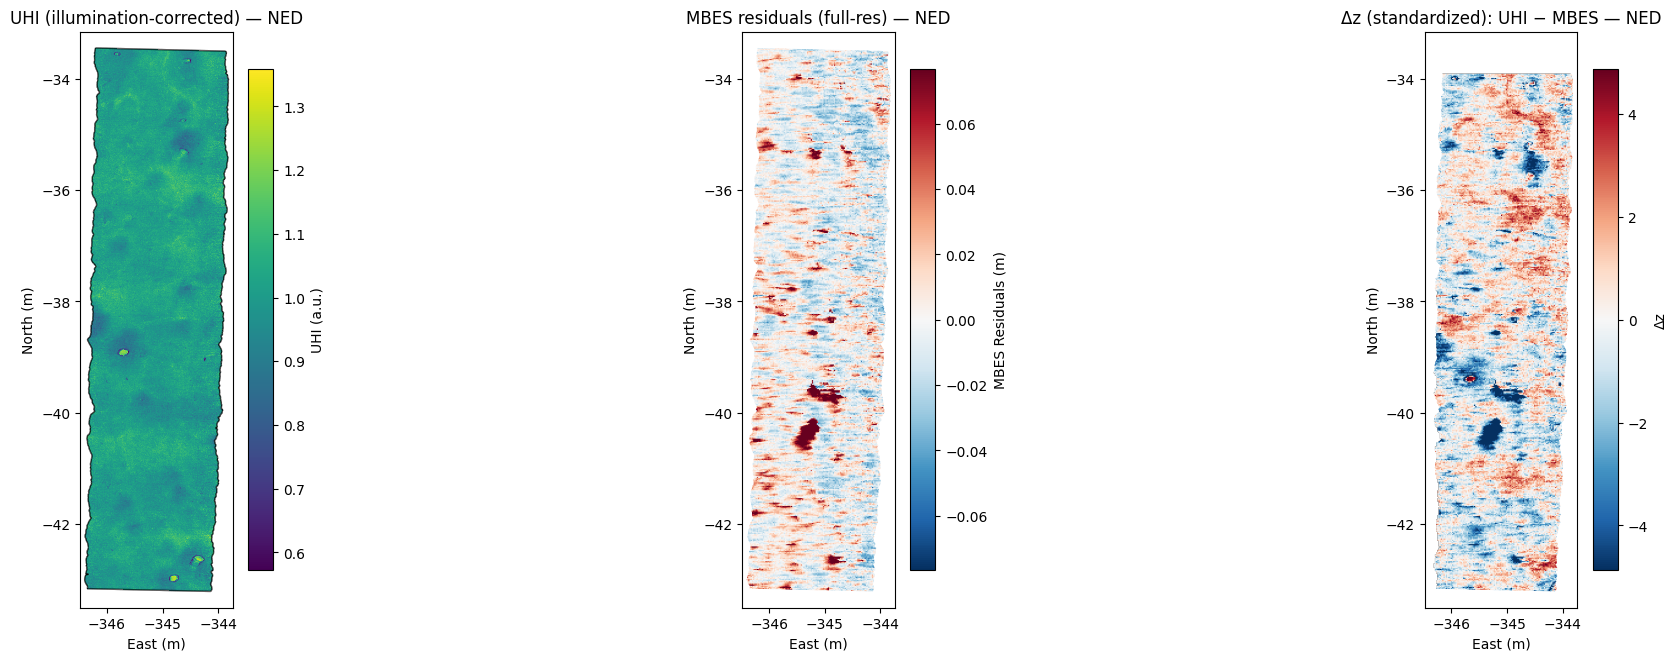


🆕  Preparing Plot 7: metrics & diagnostics (UHI vs MBES in z-units)

----- UHI vs MBES metrics (z-units; inside UHI footprint) -----
inside-footprint pixels         : 56,319
valid in both (coverage)        : 56,319  (100.0%)
Pearson r / Spearman ρ          : -0.051 / -0.029
Linear fit (zU = a + b*zM)      : a=-0.048, b=-0.044, R²=0.003
Δz = zU − zM: median/MAD        : -0.073 / 1.508
Δz RMSE / MAE                   : 1.826 / 1.325
fraction |Δz| ≤ 0.5 / 1 / 2     : 26.3% / 49.4% / 79.5%
---------------------------------------------------------------



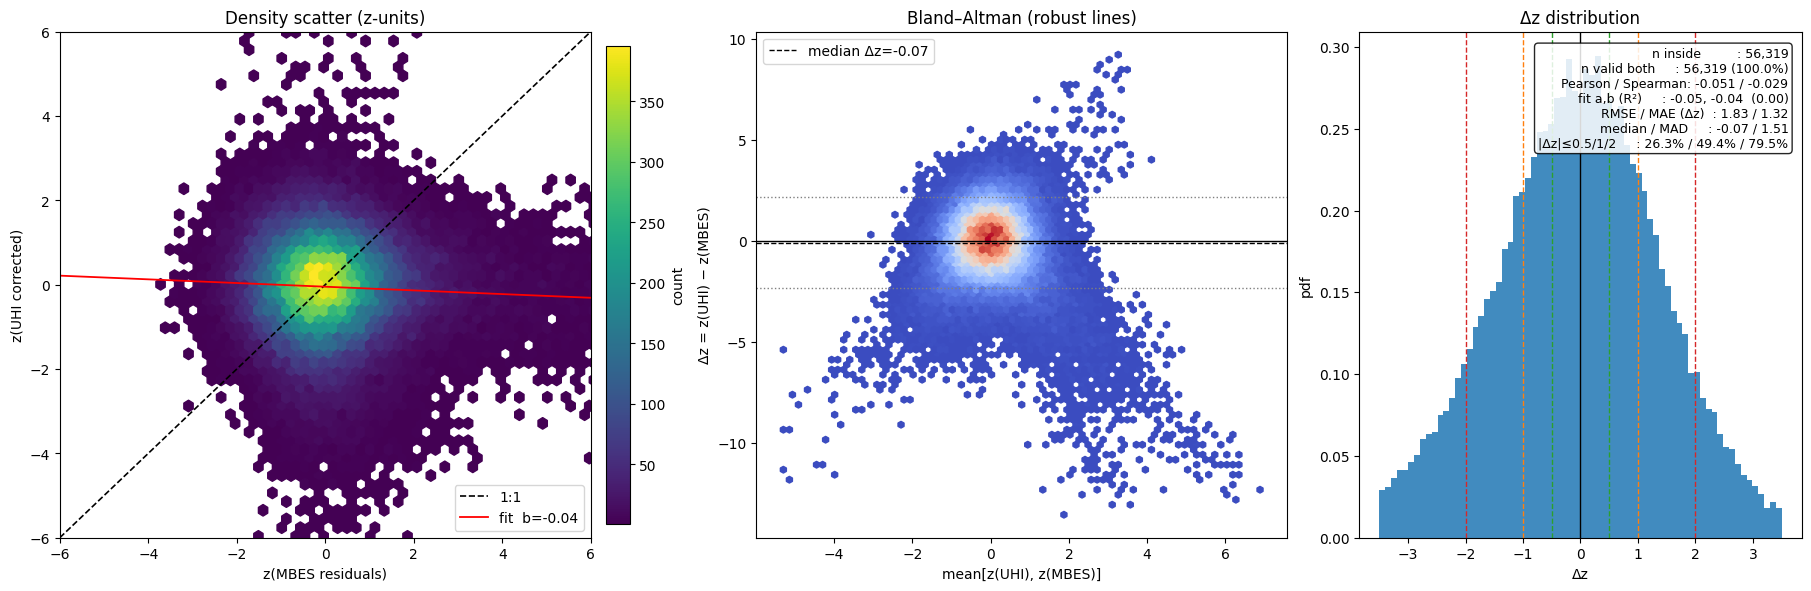

In [8]:
# === Figure 6 (three panels): UHI(corrected) | MBES | Δz (NED) ===
# Self-contained: fixes the “blank 0–1 axes” bug by using a boundary
# builder that includes OUTER EDGES of the UHI mask (no smoothing).

import sys, os
from pathlib import Path
import importlib
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec
from matplotlib.path import Path as MplPath
from matplotlib.patches import PathPatch
from matplotlib.collections import LineCollection
from scipy.spatial import cKDTree
from scipy.stats import median_abs_deviation
from pyproj import Transformer
import rasterio


# -----------------------------
# Locate repo (utils/, config)
# -----------------------------
def _add_repo_to_sys_path():
    here = Path.cwd()
    for p in [here, *here.parents]:
        if (p / "utils" / "georef.py").exists() and (p / "config.py").exists():
            sys.path.insert(0, str(p))
            return p
    raise ImportError(
        "Could not find repo root containing utils/georef.py and config.py"
    )


REPO_ROOT = _add_repo_to_sys_path()

from utils import georef
import config

importlib.reload(georef)
from utils.georef import _ecef_to_ned_arrays


# -----------------------------
# Helpers
# -----------------------------
def _pad_limits(ax, x_min, x_max, y_min, y_max, pad_frac=0.03, equal_aspect=True):
    xr = max(1e-12, x_max - x_min)
    yr = max(1e-12, y_max - y_min)
    ax.set_xlim(x_min - xr * pad_frac, x_max + xr * pad_frac)
    ax.set_ylim(y_min - yr * pad_frac, y_max + yr * pad_frac)
    if equal_aspect:
        ax.set_aspect("equal", adjustable="box")


def pcolormesh_pad(X, Y):
    Xc = np.pad(X, ((0, 1), (0, 1)), mode="edge")
    Yc = np.pad(Y, ((0, 1), (0, 1)), mode="edge")
    return Xc, Yc


def _build_full_valid(X, Y, Z, R, G, B):
    return (
        np.isfinite(X)
        & np.isfinite(Y)
        & np.isfinite(Z)
        & np.isfinite(R)
        & np.isfinite(G)
        & np.isfinite(B)
    )


def _boundary_segments_from_mask(mask: np.ndarray, Xc: np.ndarray, Yc: np.ndarray):
    """
    EXACT grid-edge outline including OUTER edges. This is the piece you were missing.
    Returns:
        segs_xy  : list of [[x0,y0],[x1,y1]] for plotting with LineCollection
        segs_idx : list of ((i0,j0),(i1,j1)) corner-index pairs to build paths
    """
    T, S = mask.shape
    segs_xy, segs_idx = [], []

    # internal vertical edges
    vdiff = mask[:, 1:] != mask[:, :-1]
    iv, jv = np.nonzero(vdiff)
    jline = jv + 1
    for i, j in zip(iv, jline):
        a = (i, j)
        b = (i + 1, j)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    # outer left (j=0) and right (j=S)
    i_left = np.nonzero(mask[:, 0])[0]
    for i in i_left:
        a = (i, 0)
        b = (i + 1, 0)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    i_right = np.nonzero(mask[:, -1])[0]
    for i in i_right:
        a = (i, S)
        b = (i + 1, S)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    # internal horizontal edges
    hdiff = mask[1:, :] != mask[:-1, :]
    ih, jh = np.nonzero(hdiff)
    iline = ih + 1
    for i, j in zip(iline, jh):
        a = (i, j)
        b = (i, j + 1)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    # outer top (i=0) and bottom (i=T)
    j_top = np.nonzero(mask[0, :])[0]
    for j in j_top:
        a = (0, j)
        b = (0, j + 1)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    j_bot = np.nonzero(mask[-1, :])[0]
    for j in j_bot:
        a = (T, j)
        b = (T, j + 1)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    return np.asarray(segs_xy, float), segs_idx


def _trace_loops_from_segments(segs_idx):
    """Turn corner-index segments into closed loops (rings)."""
    adj = {}
    for a, b in segs_idx:
        adj.setdefault(a, []).append(b)
        adj.setdefault(b, []).append(a)

    unvisited = set(frozenset((a, b)) for a, b in segs_idx)
    loops = []

    while unvisited:
        e = unvisited.pop()
        a, b = tuple(e)
        loop = [a, b]
        prev, cur = a, b
        while True:
            nbrs = adj.get(cur, [])
            nxt = next((n for n in nbrs if n != prev), None)
            if nxt is None:
                break
            edge = frozenset((cur, nxt))
            if edge in unvisited:
                unvisited.remove(edge)
            loop.append(nxt)
            prev, cur = cur, nxt
            if nxt == loop[0]:
                break
        loops.append(loop)

        # clean any remaining edges of this loop
        for i in range(len(loop) - 1):
            unvisited.discard(frozenset((loop[i], loop[i + 1])))

    return loops


def _compound_path_from_loops(loops, Xc, Yc):
    """Matplotlib Path from loops."""
    paths = []
    for ring in loops:
        xs = [Xc[idx] for idx in ring]
        ys = [Yc[idx] for idx in ring]
        if xs[0] != xs[-1] or ys[0] != ys[-1]:
            xs.append(xs[0])
            ys.append(ys[0])
        verts = np.column_stack([xs, ys])
        codes = np.full(len(verts), MplPath.LINETO, dtype=MplPath.code_type)
        codes[0] = MplPath.MOVETO
        codes[-1] = MplPath.CLOSEPOLY
        paths.append(MplPath(verts, codes))
    if len(paths) == 0:
        raise RuntimeError("Footprint loops empty — check your mask inputs.")
    if len(paths) == 1:
        return paths[0]
    return MplPath.make_compound_path(*paths)


def _robust_z(a):
    finite = np.isfinite(a)
    if not np.any(finite):
        return np.full_like(a, np.nan, dtype=float)
    m = np.nanmedian(a)
    mad = median_abs_deviation(a[finite], scale="normal")
    if not np.isfinite(mad) or mad == 0:
        mad = 1.0
    return (a - m) / mad


# -----------------------------
# MBES detrending (minimal)
# -----------------------------
class MBESDetrender:
    def __init__(
        self,
        tif_path,
        nodata_value=9999.0,
        smooth_baseline_m=0.5,
        smooth_tilt_m=0.5,
        smooth_center_m=1.0,
    ):
        self.tif_path = tif_path
        self.nodata_value = nodata_value
        self.smooth_baseline_m = smooth_baseline_m
        self.smooth_tilt_m = smooth_tilt_m
        self.smooth_center_m = smooth_center_m
        self.data = None
        self.valid_mask = None
        self.transform = None
        self.extent = None
        self.px_x = None
        self.px_y = None
        self.x_cols = None
        self.y_rows = None
        self.epsg = None
        self.A_s = self.B_s = self.C_s = None
        self.trend = None
        self.residuals = None

    def load(self):
        with rasterio.open(self.tif_path) as src:
            z = src.read(1).astype(np.float64)
            tf = src.transform
            bounds = src.bounds
            self.epsg = src.crs.to_epsg() if src.crs else None
        if self.nodata_value is not None:
            z = np.where(z == self.nodata_value, np.nan, z)
        self.valid_mask = np.isfinite(z)
        a, b, c, d, e, f = tf.a, tf.b, tf.c, tf.d, tf.e, tf.f
        H, W = z.shape
        cols = np.arange(W)
        rows = np.arange(H)
        self.x_cols = c + a * (cols + 0.5)
        self.y_rows = f + e * (rows + 0.5)
        self.px_x = abs(a)
        self.px_y = abs(e)
        self.data = z
        self.transform = tf
        self.extent = (
            float(bounds.left),
            float(bounds.right),
            float(bounds.bottom),
            float(bounds.top),
        )
        return self

    def detrend(self, order_x=2, robust=True, central_frac=0.8, max_row_iters=3):
        from scipy.signal import savgol_filter

        z = self.data if self.data is not None else self.load().data
        x = self.x_cols
        H, W = z.shape
        valid_rows = np.any(self.valid_mask, axis=1)
        idxs = np.where(valid_rows)[0]
        A = np.full(H, np.nan)
        B = np.full(H, 0.0)
        C = np.full(H, 0.0)
        for i in idxs:
            row = z[i, :]
            m = np.isfinite(row)
            if m.sum() < 6:
                continue
            xv = x[m]
            yv = row[m]
            xc_row = np.median(xv)
            if 0 < central_frac < 1:
                lo = np.quantile(xv, 0.5 - 0.5 * central_frac)
                hi = np.quantile(xv, 0.5 + 0.5 * central_frac)
                keep = (xv >= lo) & (xv <= hi)
                xv, yv = xv[keep], yv[keep]
            xi = xv - xc_row
            deg = min(order_x, 2)
            coef = np.polyfit(xi, yv, deg)
            if deg == 0:
                a0, a1, a2 = float(coef[0]), 0.0, 0.0
            elif deg == 1:
                a1, a0 = float(coef[0]), float(coef[1])
                a2 = 0.0
            else:
                a2, a1, a0 = float(coef[0]), float(coef[1]), float(coef[2])
            if robust and deg > 0:
                for _ in range(max_row_iters):
                    pred = a0 + a1 * xi + a2 * (xi**2)
                    resid = yv - pred
                    s = median_abs_deviation(resid, scale="normal")
                    if not np.isfinite(s) or s == 0:
                        break
                    w = 1.0 / (1.0 + (resid / (3 * s)) ** 2)
                    X = np.vstack([np.ones_like(xi), xi])
                    if deg == 2:
                        X = np.vstack([X, xi**2])
                    beta = np.linalg.lstsq((X * w).T, (yv * w), rcond=None)[0]
                    if deg == 2:
                        a0, a1, a2 = float(beta[0]), float(beta[1]), float(beta[2])
                    else:
                        a0, a1 = float(beta[0]), float(beta[1])
                        a2 = 0.0
            A[i], B[i], C[i] = a0, a1, a2

        def smooth_1d(arr, scale_m):
            if scale_m <= 0 or self.px_y <= 0:
                return arr
            m = np.isfinite(arr)
            if m.sum() < 5:
                return arr
            w = max(3, int(np.round(scale_m / self.px_y)))
            if w % 2 == 0:
                w += 1
            w = min(w, m.sum() - 1 if m.sum() > 1 else 1)
            if w < 3:
                return arr
            out = arr.copy()
            out[m] = savgol_filter(arr[m], window_length=w, polyorder=2)
            return out

        self.A_s = smooth_1d(A, self.smooth_baseline_m)
        self.B_s = smooth_1d(B, self.smooth_tilt_m)
        self.C_s = smooth_1d(C, self.smooth_tilt_m)

        trend = np.full_like(z, np.nan)
        for i in idxs:
            if not np.isfinite(self.A_s[i]):
                continue
            xc = np.median(x[np.isfinite(z[i, :])])
            xi = x - xc
            trend[i, :] = self.A_s[i] + self.B_s[i] * xi + self.C_s[i] * (xi**2)
        self.trend = trend
        self.residuals = z - trend
        return self

    def _robust_sym_vlim(self, arr, q=0.98):
        finite = arr[np.isfinite(arr)]
        if finite.size == 0:
            return -1, 1
        vmax = np.quantile(np.abs(finite), q)
        return -vmax, vmax


# -----------------------------
# Build/ensure cube & MBES
# -----------------------------
transect = georef.load_transect(config.OUTPUT_FOLDER)
try:
    cube = transect.select_files(
        [
            "rad_uhi_20241029_115057_4",
            "rad_uhi_20241029_115057_5",
        ]
    )
except Exception:
    cube = transect.select_all_files()

# slice range
track_start = 3039 if cube.X_ecef.shape[0] > 4029 else 0
track_end = 4029 if cube.X_ecef.shape[0] > 4029 else cube.X_ecef.shape[0]

# UHI arrays
X = cube.X_ecef[track_start:track_end, :]
Y = cube.Y_ecef[track_start:track_end, :]
Z = cube.Z_ecef[track_start:track_end, :]
R = cube.R[track_start:track_end, :]
G = cube.G[track_start:track_end, :]
B = cube.B[track_start:track_end, :]

lat0, lon0, h0 = config.LAT0, config.LON0, config.H0
N, E, D = _ecef_to_ned_arrays(X, Y, Z, lat0, lon0, h0)
mask_valid = _build_full_valid(X, Y, Z, R, G, B)

# Illumination correction (persistent)
cube.apply_illumination_correction(window_size=1000, strength=1.0)
wl = cube.wavelengths
idx_green = int(np.argmin(np.abs(wl - 560.0)))
uhi_corr = cube.data_corrected[track_start:track_end, :, idx_green]

# Footprint (pixel-perfect)
Xc_uhi, Yc_uhi = pcolormesh_pad(E, N)
segs_xy, segs_idx = _boundary_segments_from_mask(mask_valid, Xc_uhi, Yc_uhi)
loops = _trace_loops_from_segments(segs_idx)
footprint_path = _compound_path_from_loops(loops, Xc_uhi, Yc_uhi)
xs_outline = footprint_path.vertices[:, 0]
ys_outline = footprint_path.vertices[:, 1]
x_min, x_max = np.nanmin(xs_outline), np.nanmax(xs_outline)
y_min, y_max = np.nanmin(ys_outline), np.nanmax(ys_outline)

# MBES → NED
mb = MBESDetrender(
    config.MBES_GEOTIFF, smooth_baseline_m=0.5, smooth_tilt_m=0.5, smooth_center_m=1.0
).load()
mb.detrend(order_x=2, robust=True, central_frac=0.8)

MBES_X, MBES_Y = np.meshgrid(mb.x_cols, mb.y_rows)
epsg_src = mb.epsg if mb.epsg is not None else 32633
tf_to_ll = Transformer.from_crs(f"EPSG:{epsg_src}", "EPSG:4326", always_xy=True)
mbes_lon, mbes_lat = tf_to_ll.transform(MBES_X, MBES_Y)
tf_geo_to_ecef = Transformer.from_crs("EPSG:4979", "EPSG:4978", always_xy=True)
mbes_x_ecef, mbes_y_ecef, mbes_z_ecef = tf_geo_to_ecef.transform(
    mbes_lon, mbes_lat, np.zeros_like(mbes_lon)
)
mbes_n_ned, mbes_e_ned, _ = _ecef_to_ned_arrays(
    mbes_x_ecef, mbes_y_ecef, mbes_z_ecef, lat0, lon0, h0
)
extent_ned = [
    np.min(mbes_e_ned),
    np.max(mbes_e_ned),
    np.min(mbes_n_ned),
    np.max(mbes_n_ned),
]

# Which MBES pixels are inside the UHI footprint?
pts_mbes = np.column_stack([mbes_e_ned.ravel(), mbes_n_ned.ravel()])
inside = footprint_path.contains_points(pts_mbes).reshape(mbes_e_ned.shape)
if not np.any(inside):
    raise RuntimeError("No MBES pixels found inside UHI footprint. CRS/NED mismatch?")

# Resample UHI(corrected) to MBES grid (nearest) only for inside pixels
valid_uhi = mask_valid & np.isfinite(uhi_corr) & np.isfinite(E) & np.isfinite(N)
uhi_on_mbes = np.full(mb.residuals.shape, np.nan, dtype=float)
if np.any(valid_uhi):
    uhi_pts = np.column_stack([E[valid_uhi], N[valid_uhi]])
    uhi_vals = uhi_corr[valid_uhi]
    tree = cKDTree(uhi_pts)
    idx_inside = np.where(inside.ravel())[0]
    d, nn = tree.query(pts_mbes[idx_inside], k=1)
    flat = uhi_on_mbes.ravel()
    flat[idx_inside] = uhi_vals[nn]
    uhi_on_mbes = flat.reshape(mbes_e_ned.shape)

# Standardized difference (robust z-scores)
mbes_in = np.where(inside, mb.residuals, np.nan)
uhi_in = np.where(inside, uhi_on_mbes, np.nan)
z_mbes = _robust_z(mbes_in)
z_uhi = _robust_z(uhi_in)
diff_z = z_uhi - z_mbes
finite_diff = np.isfinite(diff_z)
vmax_diff = (
    np.nanpercentile(np.abs(diff_z[finite_diff]), 98.0) if np.any(finite_diff) else 1.0
)
vmin_diff = -vmax_diff
vmin_mbes, vmax_mbes = mb._robust_sym_vlim(mb.residuals, q=0.98)

# -----------------------------
# FIGURE 6: Three panels
# -----------------------------
fig6 = plt.figure(
    constrained_layout=True, figsize=(20, 6.5), num="Figure 6: UHI | MBES | Δz (NED)"
)
gs = gridspec.GridSpec(ncols=3, nrows=1, figure=fig6, width_ratios=[1, 1, 1])

axU = fig6.add_subplot(gs[0, 0])  # UHI
axM = fig6.add_subplot(gs[0, 1])  # MBES
axD = fig6.add_subplot(gs[0, 2])  # Δz

# UHI (native grid), clipped to footprint, jagged outline
uhi_plot = uhi_corr.copy()
uhi_plot[~mask_valid] = np.nan
Xc_show, Yc_show = Xc_uhi, Yc_uhi
im_uhi = axU.pcolormesh(Xc_show, Yc_show, uhi_plot, shading="flat", cmap="viridis")
im_uhi.set_clip_path(
    PathPatch(footprint_path, transform=axU.transData, facecolor="none")
)
if len(segs_xy) > 0:
    axU.add_collection(LineCollection(segs_xy, colors="k", linewidths=1.0, alpha=0.9))
_pad_limits(axU, x_min, x_max, y_min, y_max, pad_frac=0.03, equal_aspect=True)
axU.set_title("UHI (illumination-corrected) — NED")
axU.set_xlabel("East (m)")
axU.set_ylabel("North (m)")
fig6.colorbar(im_uhi, ax=axU, fraction=0.045, pad=0.02, label="UHI (a.u.)")

# MBES residuals (full-res), clipped to same footprint
im_mbes = axM.imshow(
    np.ma.masked_invalid(mb.residuals),
    extent=extent_ned,
    origin="upper",
    cmap="RdBu_r",
    vmin=vmin_mbes,
    vmax=vmax_mbes,
)
im_mbes.set_clip_path(
    PathPatch(footprint_path, transform=axM.transData, facecolor="none")
)
_pad_limits(axM, x_min, x_max, y_min, y_max, pad_frac=0.03, equal_aspect=True)
axM.set_title("MBES residuals (full-res) — NED")
axM.set_xlabel("East (m)")
axM.set_ylabel("North (m)")
fig6.colorbar(im_mbes, ax=axM, fraction=0.045, pad=0.02, label="MBES Residuals (m)")

# Δz (standardized)
im_diff = axD.imshow(
    np.ma.masked_invalid(diff_z),
    extent=extent_ned,
    origin="upper",
    cmap="RdBu_r",
    vmin=vmin_diff,
    vmax=vmax_diff,
)
im_diff.set_clip_path(
    PathPatch(footprint_path, transform=axD.transData, facecolor="none")
)
_pad_limits(axD, x_min, x_max, y_min, y_max, pad_frac=0.03, equal_aspect=True)
axD.set_title("Δz (standardized): UHI − MBES — NED")
axD.set_xlabel("East (m)")
axD.set_ylabel("North (m)")
fig6.colorbar(im_diff, ax=axD, fraction=0.045, pad=0.02, label="Δz")

plt.show()


# ============================
# 7) NEW: Metrics + diagnostic plots (scatter, Bland–Altman, histogram)
# ============================
print("\n🆕  Preparing Plot 7: metrics & diagnostics (UHI vs MBES in z-units)\n")

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec
from scipy.stats import spearmanr, median_abs_deviation
from scipy.spatial import cKDTree
from pyproj import Transformer


# ---- helpers ----
def _robust_z(a):
    finite = np.isfinite(a)
    if not np.any(finite):
        return np.full_like(a, np.nan, dtype=float)
    m = np.nanmedian(a)
    mad = median_abs_deviation(a[finite], scale="normal")
    if not np.isfinite(mad) or mad == 0:
        mad = 1.0
    return (a - m) / mad


def _safe_percentile_abs(a, p=98.0):
    finite = np.isfinite(a)
    if not np.any(finite):
        return 1.0
    return np.nanpercentile(np.abs(a[finite]), p)


# ---- reuse what we can; otherwise rebuild minimal pieces ----
try:
    uhi_corr  # corrected UHI (T,S) for selected band
    inside  # MBES-pixel boolean mask inside UHI footprint (MBES grid)
    uhi_on_mbes  # UHI resampled to MBES grid
    z_mbes
    z_uhi
    diff_z
except NameError:
    # Recompute the essentials (works if `cube`, `mb`, `E`, `N`, `full_valid`, lat0,lon0,h0 exist)
    wavelengths = cube.wavelengths
    idx_green = int(np.argmin(np.abs(wavelengths - 560.0)))
    uhi_corr = cube.data_corrected[track_start:track_end, :, idx_green]

    # Build footprint (pixel-perfect) from mask on UHI grid
    Xc_uhi, Yc_uhi = pcolormesh_pad(E, N)
    segs_xy, segs_idx = _boundary_segments_from_mask(full_valid, Xc_uhi, Yc_uhi)
    loops = _trace_loops_from_segments(segs_idx)
    footprint_path = _compound_path_from_loops(loops, Xc_uhi, Yc_uhi)

    # MBES grid -> NED
    MBES_X, MBES_Y = np.meshgrid(mb.x_cols, mb.y_rows)
    epsg_src = mb.epsg if mb.epsg is not None else 32633
    tf_to_ll = Transformer.from_crs(f"EPSG:{epsg_src}", "EPSG:4326", always_xy=True)
    mbes_lon, mbes_lat = tf_to_ll.transform(MBES_X, MBES_Y)
    tf_geo_to_ecef = Transformer.from_crs("EPSG:4979", "EPSG:4978", always_xy=True)
    mbes_x_ecef, mbes_y_ecef, mbes_z_ecef = tf_geo_to_ecef.transform(
        mbes_lon, mbes_lat, np.zeros_like(mbes_lon)
    )
    mbes_n_ned, mbes_e_ned, _ = _ecef_to_ned_arrays(
        mbes_x_ecef, mbes_y_ecef, mbes_z_ecef, lat0, lon0, h0
    )
    pts_mbes = np.column_stack([mbes_e_ned.ravel(), mbes_n_ned.ravel()])
    inside = footprint_path.contains_points(pts_mbes).reshape(mbes_e_ned.shape)

    # Resample UHI -> MBES (nearest) only for pixels inside footprint
    valid_uhi = full_valid & np.isfinite(uhi_corr) & np.isfinite(E) & np.isfinite(N)
    uhi_on_mbes = np.full(mb.residuals.shape, np.nan, dtype=float)
    if np.any(valid_uhi):
        uhi_pts = np.column_stack([E[valid_uhi], N[valid_uhi]])
        uhi_vals = uhi_corr[valid_uhi]
        tree = cKDTree(uhi_pts)
        idx_inside = np.where(inside.ravel())[0]
        d, nn = tree.query(pts_mbes[idx_inside], k=1)
        flat = uhi_on_mbes.ravel()
        flat[idx_inside] = uhi_vals[nn]
        uhi_on_mbes = flat.reshape(mb.residuals.shape)

    # Standardize to z-units for comparison
    mbes_in = np.where(inside, mb.residuals, np.nan)
    uhi_in = np.where(inside, uhi_on_mbes, np.nan)
    z_mbes = _robust_z(mbes_in)
    z_uhi = _robust_z(uhi_in)
    diff_z = z_uhi - z_mbes

# ---- vectorize valid pair samples ----
valid_pairs = np.isfinite(z_mbes) & np.isfinite(z_uhi)
zM = z_mbes[valid_pairs].ravel()
zU = z_uhi[valid_pairs].ravel()
Dz = zU - zM

if zM.size == 0:
    raise RuntimeError(
        "No overlapping valid samples to compute metrics. Check footprints/masks."
    )

# ---- metrics ----
pearson_r = float(np.corrcoef(zM, zU)[0, 1]) if zM.size > 1 else np.nan
spearman_rho = (
    float(spearmanr(zM, zU, nan_policy="omit").correlation) if zM.size > 1 else np.nan
)
# linear fit zU = a + b*zM
b, a = np.polyfit(zM, zU, 1) if zM.size > 1 else (np.nan, np.nan)
r2 = float(pearson_r**2) if np.isfinite(pearson_r) else np.nan
rmse = float(np.sqrt(np.nanmean((zU - zM) ** 2)))
mae = float(np.nanmean(np.abs(Dz)))
median_dz = float(np.nanmedian(Dz))
mad_dz = float(median_abs_deviation(Dz, scale="normal"))
pct_w05 = float(100.0 * np.nanmean(np.abs(Dz) <= 0.5))
pct_w10 = float(100.0 * np.nanmean(np.abs(Dz) <= 1.0))
pct_w20 = float(100.0 * np.nanmean(np.abs(Dz) <= 2.0))

n_inside = int(np.sum(inside))
n_valid_both = int(np.sum(valid_pairs))
coverage_pct = 100.0 * n_valid_both / max(1, n_inside)

# ---- print concise report ----
print("----- UHI vs MBES metrics (z-units; inside UHI footprint) -----")
print(f"inside-footprint pixels         : {n_inside:,}")
print(f"valid in both (coverage)        : {n_valid_both:,}  ({coverage_pct:.1f}%)")
print(f"Pearson r / Spearman ρ          : {pearson_r:.3f} / {spearman_rho:.3f}")
print(f"Linear fit (zU = a + b*zM)      : a={a:.3f}, b={b:.3f}, R²={r2:.3f}")
print(f"Δz = zU − zM: median/MAD        : {median_dz:.3f} / {mad_dz:.3f}")
print(f"Δz RMSE / MAE                   : {rmse:.3f} / {mae:.3f}")
print(
    f"fraction |Δz| ≤ 0.5 / 1 / 2     : {pct_w05:.1f}% / {pct_w10:.1f}% / {pct_w20:.1f}%"
)
print("---------------------------------------------------------------\n")

# ---- Figure 7: scatter + Bland–Altman + histogram ----
fig7 = plt.figure(
    constrained_layout=True, figsize=(18, 5.8), num="Figure 7: Metrics & Diagnostics"
)
gs = gridspec.GridSpec(ncols=3, nrows=1, figure=fig7, width_ratios=[1.2, 1.2, 1.0])

# (A) density scatter (hexbin) with 1:1 and regression
axA = fig7.add_subplot(gs[0, 0])
hb = axA.hexbin(zM, zU, gridsize=80, mincnt=1, cmap="viridis")
lim = np.nanmax(np.abs([np.nanmin([zM, zU]), np.nanmax([zM, zU])]))
lim = float(np.clip(lim, 2.0, 6.0))
axA.plot([-lim, lim], [-lim, lim], "k--", lw=1.2, label="1:1")
axA.plot(
    [-lim, lim], [a + b * (-lim), a + b * (lim)], "r-", lw=1.3, label=f"fit  b={b:.2f}"
)
axA.set_xlim(-lim, lim)
axA.set_ylim(-lim, lim)
axA.set_xlabel("z(MBES residuals)")
axA.set_ylabel("z(UHI corrected)")
axA.set_title("Density scatter (z-units)")
cb = fig7.colorbar(hb, ax=axA, fraction=0.045, pad=0.02)
cb.set_label("count")
axA.legend(loc="lower right")

# (B) Bland–Altman: Δz vs mean(zU,zM)
axB = fig7.add_subplot(gs[0, 1])
mean_z = 0.5 * (zU + zM)
axB.hexbin(mean_z, Dz, gridsize=80, mincnt=1, cmap="coolwarm")
axB.axhline(0.0, color="k", lw=1.0)
axB.axhline(median_dz, color="k", lw=1.0, ls="--", label=f"median Δz={median_dz:.2f}")
axB.axhline(median_dz + 1.4826 * mad_dz, color="gray", lw=1.0, ls=":")
axB.axhline(median_dz - 1.4826 * mad_dz, color="gray", lw=1.0, ls=":")
axB.set_xlabel("mean[z(UHI), z(MBES)]")
axB.set_ylabel("Δz = z(UHI) − z(MBES)")
axB.set_title("Bland–Altman (robust lines)")
axB.legend(loc="upper left")

# (C) Histogram of Δz with thresholds
axC = fig7.add_subplot(gs[0, 2])
bins = np.linspace(-3.5, 3.5, 70)
axC.hist(Dz, bins=bins, density=True, alpha=0.85)
axC.axvline(0.0, color="k", lw=1.0)
for thr, col in [(0.5, "tab:green"), (1.0, "tab:orange"), (2.0, "tab:red")]:
    axC.axvline(+thr, color=col, lw=1.0, ls="--")
    axC.axvline(-thr, color=col, lw=1.0, ls="--")
axC.set_xlabel("Δz")
axC.set_ylabel("pdf")
axC.set_title("Δz distribution")

# metrics text box inside panel C
txt = (
    f"n inside         : {n_inside:,}\n"
    f"n valid both     : {n_valid_both:,} ({coverage_pct:.1f}%)\n"
    f"Pearson / Spearman: {pearson_r:.3f} / {spearman_rho:.3f}\n"
    f"fit a,b (R²)     : {a:.2f}, {b:.2f}  ({r2:.2f})\n"
    f"RMSE / MAE (Δz)  : {rmse:.2f} / {mae:.2f}\n"
    f"median / MAD     : {median_dz:.2f} / {mad_dz:.2f}\n"
    f"|Δz|≤0.5/1/2     : {pct_w05:.1f}% / {pct_w10:.1f}% / {pct_w20:.1f}%"
)
axC.text(
    0.97,
    0.97,
    txt,
    transform=axC.transAxes,
    va="top",
    ha="right",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.85),
    fontsize=9,
)

plt.show()

In [ ]:
# ============================
# 8) EXTRA DIAGNOSTICS: CCC, Kendall, Local r-map, Binned curve, Shift correlation
# ============================
print(
    "\n🆕  Preparing Plot 8: spatial diagnostics (local r, binned curve, shift correlation)\n"
)

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec
from scipy.stats import kendalltau
from scipy.ndimage import uniform_filter


# --- helpers ---
def concordance_correlation_coefficient(x, y):
    """Lin's CCC (agreement, not just correlation) on pair-valid samples."""
    x = np.asarray(x)
    y = np.asarray(y)
    m_x, m_y = np.mean(x), np.mean(y)
    v_x, v_y = np.var(x, ddof=1), np.var(y, ddof=1)
    cov = np.cov(x, y, ddof=1)[0, 1]
    return (2 * cov) / (v_x + v_y + (m_x - m_y) ** 2)


def local_corr_map(A, B, win=11, min_count=20):
    """
    Fast NaN-aware local Pearson r using uniform_filter.
    A,B: 2D arrays (same shape). win: odd window size in pixels.
    """
    A = np.array(A, float)
    B = np.array(B, float)
    maskA = np.isfinite(A)
    maskB = np.isfinite(B)
    M = (maskA & maskB).astype(float)
    A = np.nan_to_num(A, nan=0.0)
    B = np.nan_to_num(B, nan=0.0)

    k = win
    sumM = uniform_filter(M, size=k, mode="nearest") * (k * k)
    sumA = uniform_filter(A, size=k, mode="nearest") * (k * k)
    sumB = uniform_filter(B, size=k, mode="nearest") * (k * k)
    sumAA = uniform_filter(A * A, size=k, mode="nearest") * (k * k)
    sumBB = uniform_filter(B * B, size=k, mode="nearest") * (k * k)
    sumAB = uniform_filter(A * B, size=k, mode="nearest") * (k * k)

    # convert filtered sums of zero-filled arrays to actual sums by multiplying by coverage
    sumA = sumA * 0 + sumA  # (already sums over kxk due to scale; we’ll rely on M)
    sumB = sumB * 0 + sumB
    sumAA = sumAA * 0 + sumAA
    sumBB = sumBB * 0 + sumBB
    sumAB = sumAB * 0 + sumAB

    # effective counts per window
    N = uniform_filter(M, size=k, mode="nearest") * (k * k)

    # correct moments using counts
    meanA = sumA / np.maximum(N, 1)
    meanB = sumB / np.maximum(N, 1)
    varA = (sumAA / np.maximum(N, 1)) - meanA**2
    varB = (sumBB / np.maximum(N, 1)) - meanB**2
    covAB = (sumAB / np.maximum(N, 1)) - meanA * meanB

    r = covAB / np.sqrt(np.maximum(varA, 0) * np.maximum(varB, 0))
    r[(N < min_count) | ~np.isfinite(r)] = np.nan
    return r


def binned_curve(x, y, nbins=25, qrange=(0.01, 0.99)):
    """Bin x into quantiles and compute mean/±SEM of y per bin."""
    qlo, qhi = np.quantile(x, qrange)
    sel = (x >= qlo) & (x <= qhi)
    x, y = x[sel], y[sel]
    bins = np.quantile(x, np.linspace(qrange[0], qrange[1], nbins + 1))
    idx = np.digitize(x, bins, right=True) - 1
    centers, ymean, ysem = [], [], []
    for b in range(nbins):
        m = idx == b
        if np.any(m):
            centers.append(0.5 * (bins[b] + bins[b + 1]))
            ymean.append(np.nanmean(y[m]))
            ysem.append(np.nanstd(y[m], ddof=1) / np.sqrt(np.sum(m)))
    return np.array(centers), np.array(ymean), np.array(ysem)


def best_shift_correlation(A, B, inside_mask, max_shift=10):
    """
    Explore small integer pixel shifts of B relative to A and return a
    correlation surface plus the best shift.
    """
    A = np.array(A, float)
    B = np.array(B, float)
    best_r, best = -np.inf, (0, 0)
    surf = np.full((2 * max_shift + 1, 2 * max_shift + 1), np.nan)
    for dy in range(-max_shift, max_shift + 1):
        Bdy = np.roll(B, dy, axis=0)
        for dx in range(-max_shift, max_shift + 1):
            Bsh = np.roll(Bdy, dx, axis=1)
            m = np.isfinite(A) & np.isfinite(Bsh) & inside_mask
            if np.sum(m) < 50:
                r = np.nan
            else:
                r = np.corrcoef(A[m], Bsh[m])[0, 1]
            surf[dy + max_shift, dx + max_shift] = r
            if np.isfinite(r) and r > best_r:
                best_r, best = r, (dx, dy)
    return surf, best, best_r


# --- use your existing arrays from Plot 7 ---
# z_mbes, z_uhi, diff_z, inside, uhi_on_mbes must be defined from your previous step.
valid_pairs = np.isfinite(z_mbes) & np.isfinite(z_uhi)
zM = z_mbes[valid_pairs]
zU = z_uhi[valid_pairs]

# Global extras
kendall_tau, _ = kendalltau(zM, zU)
ccc = concordance_correlation_coefficient(zM, zU)
print(f"Extras — Kendall τ: {kendall_tau:.3f},  CCC: {ccc:.3f}")

# Local correlation (sliding window on the MBES grid)
win_px = 11  # adjust (odd number). Try 21 for smoother.
r_local = local_corr_map(
    z_mbes, z_uhi, win=win_px, min_count=int(0.4 * win_px * win_px)
)

# Binned curve (relation shape)
xc, ymean, ysem = binned_curve(zM, zU, nbins=25, qrange=(0.02, 0.98))

# Shift correlation surface (quick registration sanity check)
surf, (dx_best, dy_best), r_best = best_shift_correlation(
    z_mbes, z_uhi, inside, max_shift=10
)
print(f"Best small-pixel shift (dx,dy) = ({dx_best}, {dy_best}), corr = {r_best:.3f}")

# ---- Figure 8 ----
fig8 = plt.figure(
    constrained_layout=True, figsize=(18, 6), num="Figure 8: Spatial diagnostics"
)
gs = gridspec.GridSpec(ncols=3, nrows=1, figure=fig8, width_ratios=[1.2, 1.0, 1.0])

# (A) Local correlation heatmap
axA = fig8.add_subplot(gs[0, 0])
imA = axA.imshow(r_local, origin="upper", cmap="coolwarm", vmin=-1, vmax=1)
axA.set_title(f"Local Pearson r (window={win_px} px)")
axA.set_xlabel("East (px)")
axA.set_ylabel("North (px)")
cbA = fig8.colorbar(imA, ax=axA, fraction=0.045, pad=0.02)
cbA.set_label("r")

# (B) Binned relationship
axB = fig8.add_subplot(gs[0, 1])
axB.plot(xc, ymean, lw=2)
axB.fill_between(xc, ymean - 2 * ysem, ymean + 2 * ysem, alpha=0.2)
axB.plot([-3, 3], [-3, 3], "k--", lw=1, label="1:1")
axB.set_xlim(np.min(xc), np.max(xc))
axB.set_xlabel("z(MBES residuals) — binned")
axB.set_ylabel("mean z(UHI corrected)")
axB.set_title("Binned curve (±2·SEM)")
axB.legend()

# (C) Shift–correlation surface
axC = fig8.add_subplot(gs[0, 2])
extent = [-10, 10, -10, 10]  # if max_shift changed, update this
imC = axC.imshow(
    surf, origin="lower", cmap="viridis", extent=extent, vmin=-1, vmax=1, aspect="equal"
)
axC.scatter([dx_best], [dy_best], c="r", s=60, marker="x", label=f"best r={r_best:.2f}")
axC.set_xlabel("dx (pixels)")
axC.set_ylabel("dy (pixels)")
axC.set_title("Small-shift correlation (MBES vs UHI)")
axC.legend()
cbC = fig8.colorbar(imC, ax=axC, fraction=0.045, pad=0.02)
cbC.set_label("corr")

plt.show()

# try to make it fit better

In [9]:
# ========= Alignment helpers: move+rotate UHI mask to best match MBES =========
import numpy as np
from matplotlib.path import Path
from matplotlib.patches import PathPatch
from matplotlib.collections import LineCollection
from scipy.spatial import cKDTree
from scipy.stats import median_abs_deviation


# 1) Footprint builder (uses your existing helpers if available)
def build_footprint_path_from_valid(full_valid, E, N):
    Xc, Yc = pcolormesh_pad(E, N)
    segs_xy, segs_idx = _boundary_segments_from_mask(full_valid, Xc, Yc)
    loops = _trace_loops_from_segments(segs_idx)
    return _compound_path_from_loops(loops, Xc, Yc)


# 2) Standardization and robust loss
def robust_z(a):
    m = np.nanmedian(a)
    mask = np.isfinite(a)
    if not mask.any():
        return np.full_like(a, np.nan, dtype=float)
    mad = median_abs_deviation(a[mask], scale="normal")
    if not np.isfinite(mad) or mad == 0:
        mad = 1.0
    return (a - m) / mad


def loss_median_abs_diff(z_uhi, z_mbes):
    d = np.abs(z_uhi - z_mbes)
    d = d[np.isfinite(d)]
    if d.size == 0:
        return np.inf
    return np.nanmedian(d)


# 3) KD-tree sampler on the original UHI grid
def make_uhi_sampler(E, N, UHI, valid_mask):
    pts = np.column_stack([E[valid_mask], N[valid_mask]])
    vals = UHI[valid_mask].astype(float)
    tree = cKDTree(pts)

    def sampler(xy_query):
        # returns nearest neighbor samples with NaN for empty queries
        if xy_query.size == 0:
            return np.array([], dtype=float)
        d, idx = tree.query(xy_query, k=1)
        out = np.full(xy_query.shape[0], np.nan, dtype=float)
        out[:] = vals[idx]
        return out

    return sampler


# 4) Geometry transforms
def centroid_of_path(path: Path):
    v = path.vertices
    return float(np.nanmean(v[:, 0])), float(np.nanmean(v[:, 1]))


def inverse_transform_points(xy, cx, cy, dx, dy, theta_deg):
    """
    Map MBES points back to original UHI frame:
      - undo translation (dx, dy)
      - rotate by -theta around centroid (cx, cy)
    """
    theta = np.deg2rad(theta_deg)
    cos_t, sin_t = np.cos(-theta), np.sin(-theta)
    # undo translation
    x = xy[:, 0] - dx
    y = xy[:, 1] - dy
    # rotate around centroid
    x0 = x - cx
    y0 = y - cy
    xr = cos_t * x0 - sin_t * y0 + cx
    yr = sin_t * x0 + cos_t * y0 + cy
    return np.column_stack([xr, yr])


def transform_path(path: Path, cx, cy, dx, dy, theta_deg):
    v = path.vertices
    theta = np.deg2rad(theta_deg)
    cos_t, sin_t = np.cos(theta), np.sin(theta)
    x0 = v[:, 0] - cx
    y0 = v[:, 1] - cy
    xt = cos_t * x0 - sin_t * y0 + cx + dx
    yt = sin_t * x0 + cos_t * y0 + cy + dy
    return Path(np.column_stack([xt, yt]), path.codes)


# 5) Cost function for a given pose (dx, dy, theta)
def alignment_cost(
    params, *, mbes_E, mbes_N, mbes_residuals, uhi_sampler, footprint_path
):
    dx, dy, theta = params
    # centroid in original UHI frame
    cx, cy = centroid_of_path(footprint_path)

    # MBES centers as list
    mb_pts = np.column_stack([mbes_E.ravel(), mbes_N.ravel()])

    # inverse transform: MBES points -> original UHI frame
    mb_pts_in_uhi = inverse_transform_points(mb_pts, cx, cy, dx, dy, theta)

    # inside original UHI mask?
    inside = footprint_path.contains_points(mb_pts_in_uhi)
    if not np.any(inside):
        return np.inf

    # sample UHI at those inverse-transformed locations
    uhi_vals = uhi_sampler(mb_pts_in_uhi[inside])

    # build arrays on MBES grid
    uhi_on_mbes = np.full(mbes_residuals.size, np.nan, dtype=float)
    uhi_on_mbes[inside] = uhi_vals
    uhi_on_mbes = uhi_on_mbes.reshape(mbes_residuals.shape)

    # restrict MBES to the transformed mask
    mbes_in = np.where(inside.reshape(mbes_residuals.shape), mbes_residuals, np.nan)

    # robust, scale-free loss
    z_uhi = robust_z(uhi_on_mbes)
    z_mbes = robust_z(mbes_in)
    return loss_median_abs_diff(z_uhi, z_mbes)


# 6) Coarse search + local refine
def run_alignment_search(
    E,
    N,
    UHI_corr,
    full_valid,
    mbes_E,
    mbes_N,
    mbes_residuals,
    footprint_path=None,
    dx_range=(-2.0, 2.0),
    dy_range=(-2.0, 2.0),
    th_range=(-3.0, 3.0),
    dx_step=0.25,
    dy_step=0.25,
    th_step=0.5,
    verbose=True,
):
    if footprint_path is None:
        footprint_path = build_footprint_path_from_valid(full_valid, E, N)

    # sampler on original UHI frame
    sampler = make_uhi_sampler(
        E,
        N,
        UHI_corr,
        valid_mask=(
            full_valid & np.isfinite(UHI_corr) & np.isfinite(E) & np.isfinite(N)
        ),
    )

    # coarse grid
    dxs = np.arange(dx_range[0], dx_range[1] + 1e-9, dx_step)
    dys = np.arange(dy_range[0], dy_range[1] + 1e-9, dy_step)
    ths = np.arange(th_range[0], th_range[1] + 1e-9, th_step)

    best = (0.0, 0.0, 0.0)
    best_loss = np.inf
    for dx in dxs:
        for dy in dys:
            for th in ths:
                L = alignment_cost(
                    (dx, dy, th),
                    mbes_E=mbes_E,
                    mbes_N=mbes_N,
                    mbes_residuals=mbes_residuals,
                    uhi_sampler=sampler,
                    footprint_path=footprint_path,
                )
                if L < best_loss:
                    best_loss, best = L, (dx, dy, th)
    if verbose:
        print(
            f"Coarse best: dx={best[0]:.3f} m, dy={best[1]:.3f} m, θ={best[2]:.3f} deg, loss={best_loss:.4f}"
        )

    # local refine with Nelder–Mead (no heavy deps beyond scipy already used)
    try:
        from scipy.optimize import minimize

        res = minimize(
            lambda p: alignment_cost(
                p,
                mbes_E=mbes_E,
                mbes_N=mbes_N,
                mbes_residuals=mbes_residuals,
                uhi_sampler=sampler,
                footprint_path=footprint_path,
            ),
            x0=np.array(best, dtype=float),
            method="Nelder-Mead",
            options=dict(maxiter=200, xatol=1e-3, fatol=1e-4, disp=False),
        )
        if res.success and res.fun < best_loss:
            best = tuple(res.x.tolist())
            best_loss = float(res.fun)
            if verbose:
                print(
                    f"Refined best: dx={best[0]:.3f}, dy={best[1]:.3f}, θ={best[2]:.3f}, loss={best_loss:.4f}"
                )
    except Exception as e:
        if verbose:
            print(f"Refine step skipped: {e}")

    return {
        "best_params": {"dx": best[0], "dy": best[1], "theta_deg": best[2]},
        "best_loss": best_loss,
        "sampler": sampler,
        "footprint_path": footprint_path,
    }


# 7) Build aligned fields for plotting at the best pose
def build_aligned_fields(best, sampler, footprint_path, mbes_E, mbes_N, mbes_residuals):
    dx, dy, th = best["dx"], best["dy"], best["theta_deg"]
    cx, cy = centroid_of_path(footprint_path)

    mb_pts = np.column_stack([mbes_E.ravel(), mbes_N.ravel()])
    mb_pts_in_uhi = inverse_transform_points(mb_pts, cx, cy, dx, dy, th)

    inside = footprint_path.contains_points(mb_pts_in_uhi)
    uhi_vals = sampler(mb_pts_in_uhi[inside])

    uhi_on_mbes = np.full(mbes_residuals.size, np.nan, dtype=float)
    uhi_on_mbes[inside] = uhi_vals
    uhi_on_mbes = uhi_on_mbes.reshape(mbes_residuals.shape)

    mbes_in = np.where(inside.reshape(mbes_residuals.shape), mbes_residuals, np.nan)

    z_uhi = robust_z(uhi_on_mbes)
    z_mbes = robust_z(mbes_in)
    diff_z = z_uhi - z_mbes

    # transformed footprint for display
    tf_path = transform_path(footprint_path, cx, cy, dx, dy, th)
    return uhi_on_mbes, mbes_in, diff_z, tf_path


# 8) Convenience plot: UHI, MBES, Δz side by side using the same layout you like
def plot_triptych(uhi_on_mbes, mbes_in, diff_z, tf_path, mbes_E, mbes_N):
    extent = [
        np.nanmin(mbes_E),
        np.nanmax(mbes_E),
        np.nanmin(mbes_N),
        np.nanmax(mbes_N),
    ]
    vmin_res, vmax_res = mb._robust_sym_vlim(mb.residuals, q=0.98)

    # UHI limits
    finite_uhi = np.isfinite(uhi_on_mbes)
    if finite_uhi.any():
        umin = np.nanpercentile(uhi_on_mbes[finite_uhi], 2)
        umax = np.nanpercentile(uhi_on_mbes[finite_uhi], 98)
        if umin == umax:
            umin, umax = float(np.nanmin(uhi_on_mbes)), float(np.nanmax(uhi_on_mbes))
    else:
        umin, umax = 0.0, 1.0

    # Δz limits
    finite_d = np.isfinite(diff_z)
    if finite_d.any():
        vmax_d = np.nanpercentile(np.abs(diff_z[finite_d]), 98.0)
    else:
        vmax_d = 1.0
    vmin_d = -vmax_d

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    axU, axM, axD = axes

    imU = axU.imshow(
        np.ma.masked_invalid(uhi_on_mbes),
        extent=extent,
        origin="upper",
        cmap="viridis",
        vmin=umin,
        vmax=umax,
    )
    axU.add_patch(
        PathPatch(
            tf_path,
            transform=axU.transData,
            facecolor="none",
            edgecolor="k",
            linewidth=1.0,
        )
    )
    axU.set_title("UHI (corr) sampled on MBES grid")
    axU.set_xlabel("East (m)")
    axU.set_ylabel("North (m)")
    fig.colorbar(imU, ax=axU, fraction=0.035, pad=0.02, label="UHI (a.u.)")

    imM = axM.imshow(
        np.ma.masked_invalid(mbes_in),
        extent=extent,
        origin="upper",
        cmap="RdBu_r",
        vmin=vmin_res,
        vmax=vmax_res,
    )
    axM.add_patch(
        PathPatch(
            tf_path,
            transform=axM.transData,
            facecolor="none",
            edgecolor="k",
            linewidth=1.0,
        )
    )
    axM.set_title("MBES residuals inside moved UHI mask")
    axM.set_xlabel("East (m)")
    axM.set_ylabel("North (m)")
    fig.colorbar(imM, ax=axM, fraction=0.035, pad=0.02, label="MBES Residuals (m)")

    imD = axD.imshow(
        np.ma.masked_invalid(diff_z),
        extent=extent,
        origin="upper",
        cmap="RdBu_r",
        vmin=vmin_d,
        vmax=vmax_d,
    )
    axD.add_patch(
        PathPatch(
            tf_path,
            transform=axD.transData,
            facecolor="none",
            edgecolor="k",
            linewidth=1.0,
        )
    )
    axD.set_title("Standardized difference Δz = z(UHI) − z(MBES)")
    axD.set_xlabel("East (m)")
    axD.set_ylabel("North (m)")
    fig.colorbar(imD, ax=axD, fraction=0.035, pad=0.02, label="Δz")

    for ax in axes:
        ax.set_aspect("equal", adjustable="box")
    try:
        fig.tight_layout()
    except Exception:
        pass
    return fig


# ======================== End alignment helpers ========================

In [10]:
# Build footprint (or reuse your existing footprint_path)
try:
    footprint = footprint_path
except NameError:
    footprint = build_footprint_path_from_valid(full_valid, E, N)

# Run alignment search around zero pose, tweak ranges if needed
search = run_alignment_search(
    E,
    N,
    uhi_corr,
    full_valid,
    mbes_E=mbes_e_ned,
    mbes_N=mbes_n_ned,
    mbes_residuals=mb.residuals,
    footprint_path=footprint,
    dx_range=(-2.0, 2.0),
    dy_range=(-2.0, 2.0),
    th_range=(-3.0, 3.0),
    dx_step=0.25,
    dy_step=0.25,
    th_step=0.5,
    verbose=True,
)

best = search["best_params"]
print(
    f"Best pose → dx={best['dx']:.3f} m, dy={best['dy']:.3f} m, θ={best['theta_deg']:.3f}°"
)

# Build aligned fields at the best pose
uhi_on_mbes, mbes_in, diff_z, tf_path = build_aligned_fields(
    best,
    search["sampler"],
    search["footprint_path"],
    mbes_e_ned,
    mbes_n_ned,
    mb.residuals,
)

# Plot the aligned triptych
fig_align = plot_triptych(uhi_on_mbes, mbes_in, diff_z, tf_path, mbes_e_ned, mbes_n_ned)
plt.show()

KeyboardInterrupt: 

🔄 Rebuilding grids from georef hits for selected files...
   • rad_uhi_20241029_115057_4
  rad_uhi_20241029_115057_4: Using GRIDDED format (T=2463, S=968)
   • rad_uhi_20241029_115057_5
  rad_uhi_20241029_115057_5: Using GRIDDED format (T=2462, S=968)
   • rad_uhi_20241029_115057_5
  rad_uhi_20241029_115057_5: Using GRIDDED format (T=2462, S=968)
✅ Combined shapes: X/Y/Z (4925, 968), RGB (4925, 968)
✅ Illumination correction already applied with window=1000, strength=1.0
   Loading from disk...
📂 Loading saved illumination correction from 2 files...
✅ Combined shapes: X/Y/Z (4925, 968), RGB (4925, 968)
✅ Illumination correction already applied with window=1000, strength=1.0
   Loading from disk...
📂 Loading saved illumination correction from 2 files...
   rad_uhi_20241029_115057_4: window=1000, strength=1.0
   rad_uhi_20241029_115057_4: window=1000, strength=1.0
   rad_uhi_20241029_115057_5: window=1000, strength=1.0
✅ Loaded illumination correction from disk
   rad_uhi_20241029_115057

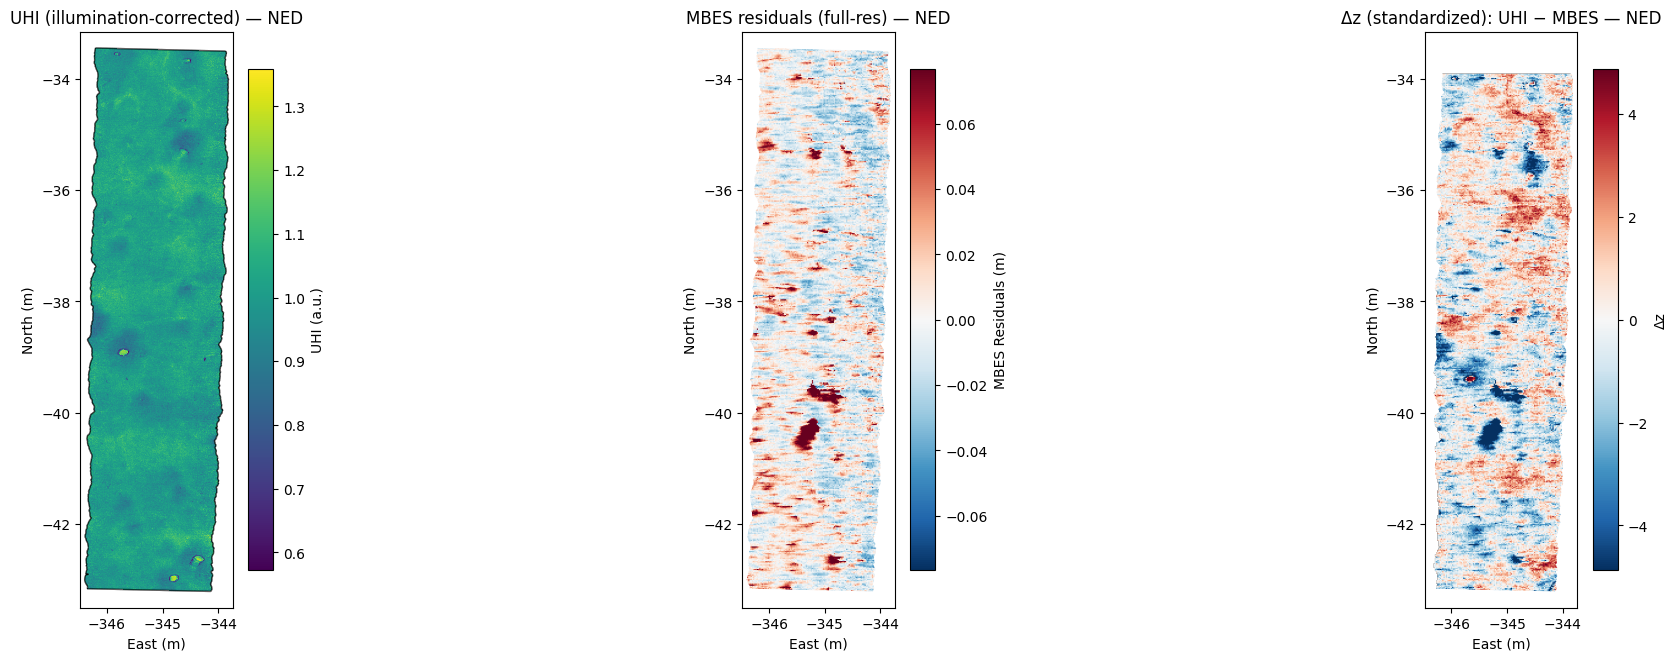


🆕  Preparing Plot 7: metrics & diagnostics (UHI vs MBES in z-units)

----- UHI vs MBES metrics (z-units; inside UHI footprint) -----
inside-footprint pixels         : 56,319
valid in both (coverage)        : 56,319  (100.0%)
Pearson r / Spearman ρ          : -0.051 / -0.029
Linear fit (zU = a + b*zM)      : a=-0.048, b=-0.044, R²=0.003
Δz = zU − zM: median/MAD        : -0.073 / 1.508
Δz RMSE / MAE                   : 1.826 / 1.325
fraction |Δz| ≤ 0.5 / 1 / 2     : 26.3% / 49.4% / 79.5%
---------------------------------------------------------------



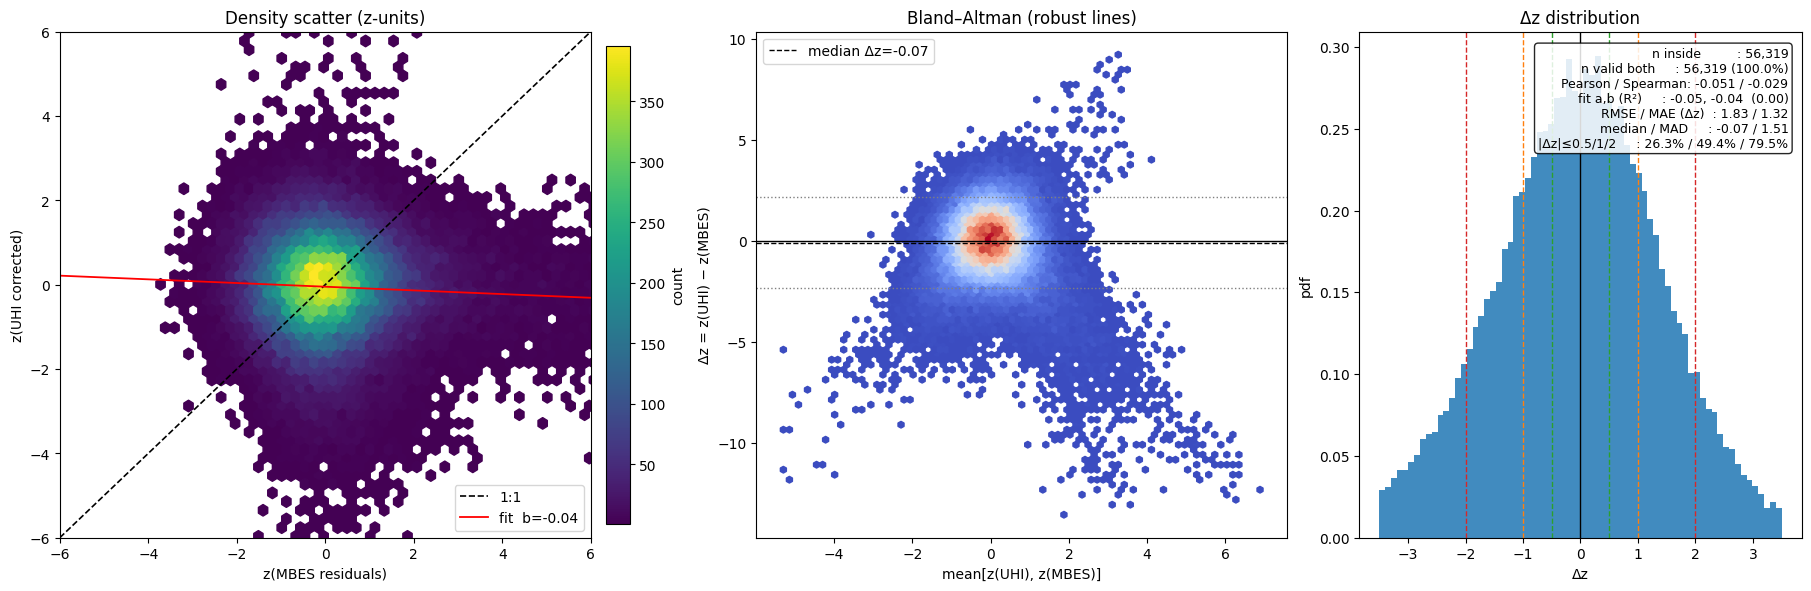


🆕  Preparing Plot 8: alignment search (translations + rotation)



NameError: name 'full_valid' is not defined

In [1]:
# === Figure 6 (three panels): UHI(corrected) | MBES | Δz (NED) ===
# Self-contained: fixes the “blank 0–1 axes” bug by using a boundary
# builder that includes OUTER EDGES of the UHI mask (no smoothing).

import sys, os
from pathlib import Path
import importlib
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec
from matplotlib.path import Path as MplPath
from matplotlib.patches import PathPatch
from matplotlib.collections import LineCollection
from scipy.spatial import cKDTree
from scipy.stats import median_abs_deviation
from pyproj import Transformer
import rasterio


# -----------------------------
# Locate repo (utils/, config)
# -----------------------------
def _add_repo_to_sys_path():
    here = Path.cwd()
    for p in [here, *here.parents]:
        if (p / "utils" / "georef.py").exists() and (p / "config.py").exists():
            sys.path.insert(0, str(p))
            return p
    raise ImportError(
        "Could not find repo root containing utils/georef.py and config.py"
    )


REPO_ROOT = _add_repo_to_sys_path()

from utils import georef
import config

importlib.reload(georef)
from utils.georef import _ecef_to_ned_arrays


# -----------------------------
# Helpers
# -----------------------------
def _pad_limits(ax, x_min, x_max, y_min, y_max, pad_frac=0.03, equal_aspect=True):
    xr = max(1e-12, x_max - x_min)
    yr = max(1e-12, y_max - y_min)
    ax.set_xlim(x_min - xr * pad_frac, x_max + xr * pad_frac)
    ax.set_ylim(y_min - yr * pad_frac, y_max + yr * pad_frac)
    if equal_aspect:
        ax.set_aspect("equal", adjustable="box")


def pcolormesh_pad(X, Y):
    Xc = np.pad(X, ((0, 1), (0, 1)), mode="edge")
    Yc = np.pad(Y, ((0, 1), (0, 1)), mode="edge")
    return Xc, Yc


def _build_full_valid(X, Y, Z, R, G, B):
    return (
        np.isfinite(X)
        & np.isfinite(Y)
        & np.isfinite(Z)
        & np.isfinite(R)
        & np.isfinite(G)
        & np.isfinite(B)
    )


def _boundary_segments_from_mask(mask: np.ndarray, Xc: np.ndarray, Yc: np.ndarray):
    """
    EXACT grid-edge outline including OUTER edges. This is the piece you were missing.
    Returns:
        segs_xy  : list of [[x0,y0],[x1,y1]] for plotting with LineCollection
        segs_idx : list of ((i0,j0),(i1,j1)) corner-index pairs to build paths
    """
    T, S = mask.shape
    segs_xy, segs_idx = [], []

    # internal vertical edges
    vdiff = mask[:, 1:] != mask[:, :-1]
    iv, jv = np.nonzero(vdiff)
    jline = jv + 1
    for i, j in zip(iv, jline):
        a = (i, j)
        b = (i + 1, j)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    # outer left (j=0) and right (j=S)
    i_left = np.nonzero(mask[:, 0])[0]
    for i in i_left:
        a = (i, 0)
        b = (i + 1, 0)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    i_right = np.nonzero(mask[:, -1])[0]
    for i in i_right:
        a = (i, S)
        b = (i + 1, S)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    # internal horizontal edges
    hdiff = mask[1:, :] != mask[:-1, :]
    ih, jh = np.nonzero(hdiff)
    iline = ih + 1
    for i, j in zip(iline, jh):
        a = (i, j)
        b = (i, j + 1)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    # outer top (i=0) and bottom (i=T)
    j_top = np.nonzero(mask[0, :])[0]
    for j in j_top:
        a = (0, j)
        b = (0, j + 1)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    j_bot = np.nonzero(mask[-1, :])[0]
    for j in j_bot:
        a = (T, j)
        b = (T, j + 1)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    return np.asarray(segs_xy, float), segs_idx


def _trace_loops_from_segments(segs_idx):
    """Turn corner-index segments into closed loops (rings)."""
    adj = {}
    for a, b in segs_idx:
        adj.setdefault(a, []).append(b)
        adj.setdefault(b, []).append(a)

    unvisited = set(frozenset((a, b)) for a, b in segs_idx)
    loops = []

    while unvisited:
        e = unvisited.pop()
        a, b = tuple(e)
        loop = [a, b]
        prev, cur = a, b
        while True:
            nbrs = adj.get(cur, [])
            nxt = next((n for n in nbrs if n != prev), None)
            if nxt is None:
                break
            edge = frozenset((cur, nxt))
            if edge in unvisited:
                unvisited.remove(edge)
            loop.append(nxt)
            prev, cur = cur, nxt
            if nxt == loop[0]:
                break
        loops.append(loop)

        # clean any remaining edges of this loop
        for i in range(len(loop) - 1):
            unvisited.discard(frozenset((loop[i], loop[i + 1])))

    return loops


def _compound_path_from_loops(loops, Xc, Yc):
    """Matplotlib Path from loops."""
    paths = []
    for ring in loops:
        xs = [Xc[idx] for idx in ring]
        ys = [Yc[idx] for idx in ring]
        if xs[0] != xs[-1] or ys[0] != ys[-1]:
            xs.append(xs[0])
            ys.append(ys[0])
        verts = np.column_stack([xs, ys])
        codes = np.full(len(verts), MplPath.LINETO, dtype=MplPath.code_type)
        codes[0] = MplPath.MOVETO
        codes[-1] = MplPath.CLOSEPOLY
        paths.append(MplPath(verts, codes))
    if len(paths) == 0:
        raise RuntimeError("Footprint loops empty — check your mask inputs.")
    if len(paths) == 1:
        return paths[0]
    return MplPath.make_compound_path(*paths)


def _robust_z(a):
    finite = np.isfinite(a)
    if not np.any(finite):
        return np.full_like(a, np.nan, dtype=float)
    m = np.nanmedian(a)
    mad = median_abs_deviation(a[finite], scale="normal")
    if not np.isfinite(mad) or mad == 0:
        mad = 1.0
    return (a - m) / mad


# -----------------------------
# MBES detrending (minimal)
# -----------------------------
class MBESDetrender:
    def __init__(
        self,
        tif_path,
        nodata_value=9999.0,
        smooth_baseline_m=0.5,
        smooth_tilt_m=0.5,
        smooth_center_m=1.0,
    ):
        self.tif_path = tif_path
        self.nodata_value = nodata_value
        self.smooth_baseline_m = smooth_baseline_m
        self.smooth_tilt_m = smooth_tilt_m
        self.smooth_center_m = smooth_center_m
        self.data = None
        self.valid_mask = None
        self.transform = None
        self.extent = None
        self.px_x = None
        self.px_y = None
        self.x_cols = None
        self.y_rows = None
        self.epsg = None
        self.A_s = self.B_s = self.C_s = None
        self.trend = None
        self.residuals = None

    def load(self):
        with rasterio.open(self.tif_path) as src:
            z = src.read(1).astype(np.float64)
            tf = src.transform
            bounds = src.bounds
            self.epsg = src.crs.to_epsg() if src.crs else None
        if self.nodata_value is not None:
            z = np.where(z == self.nodata_value, np.nan, z)
        self.valid_mask = np.isfinite(z)
        a, b, c, d, e, f = tf.a, tf.b, tf.c, tf.d, tf.e, tf.f
        H, W = z.shape
        cols = np.arange(W)
        rows = np.arange(H)
        self.x_cols = c + a * (cols + 0.5)
        self.y_rows = f + e * (rows + 0.5)
        self.px_x = abs(a)
        self.px_y = abs(e)
        self.data = z
        self.transform = tf
        self.extent = (
            float(bounds.left),
            float(bounds.right),
            float(bounds.bottom),
            float(bounds.top),
        )
        return self

    def detrend(self, order_x=2, robust=True, central_frac=0.8, max_row_iters=3):
        from scipy.signal import savgol_filter

        z = self.data if self.data is not None else self.load().data
        x = self.x_cols
        H, W = z.shape
        valid_rows = np.any(self.valid_mask, axis=1)
        idxs = np.where(valid_rows)[0]
        A = np.full(H, np.nan)
        B = np.full(H, 0.0)
        C = np.full(H, 0.0)
        for i in idxs:
            row = z[i, :]
            m = np.isfinite(row)
            if m.sum() < 6:
                continue
            xv = x[m]
            yv = row[m]
            xc_row = np.median(xv)
            if 0 < central_frac < 1:
                lo = np.quantile(xv, 0.5 - 0.5 * central_frac)
                hi = np.quantile(xv, 0.5 + 0.5 * central_frac)
                keep = (xv >= lo) & (xv <= hi)
                xv, yv = xv[keep], yv[keep]
            xi = xv - xc_row
            deg = min(order_x, 2)
            coef = np.polyfit(xi, yv, deg)
            if deg == 0:
                a0, a1, a2 = float(coef[0]), 0.0, 0.0
            elif deg == 1:
                a1, a0 = float(coef[0]), float(coef[1])
                a2 = 0.0
            else:
                a2, a1, a0 = float(coef[0]), float(coef[1]), float(coef[2])
            if robust and deg > 0:
                for _ in range(max_row_iters):
                    pred = a0 + a1 * xi + a2 * (xi**2)
                    resid = yv - pred
                    s = median_abs_deviation(resid, scale="normal")
                    if not np.isfinite(s) or s == 0:
                        break
                    w = 1.0 / (1.0 + (resid / (3 * s)) ** 2)
                    X = np.vstack([np.ones_like(xi), xi])
                    if deg == 2:
                        X = np.vstack([X, xi**2])
                    beta = np.linalg.lstsq((X * w).T, (yv * w), rcond=None)[0]
                    if deg == 2:
                        a0, a1, a2 = float(beta[0]), float(beta[1]), float(beta[2])
                    else:
                        a0, a1 = float(beta[0]), float(beta[1])
                        a2 = 0.0
            A[i], B[i], C[i] = a0, a1, a2

        def smooth_1d(arr, scale_m):
            if scale_m <= 0 or self.px_y <= 0:
                return arr
            m = np.isfinite(arr)
            if m.sum() < 5:
                return arr
            w = max(3, int(np.round(scale_m / self.px_y)))
            if w % 2 == 0:
                w += 1
            w = min(w, m.sum() - 1 if m.sum() > 1 else 1)
            if w < 3:
                return arr
            out = arr.copy()
            out[m] = savgol_filter(arr[m], window_length=w, polyorder=2)
            return out

        self.A_s = smooth_1d(A, self.smooth_baseline_m)
        self.B_s = smooth_1d(B, self.smooth_tilt_m)
        self.C_s = smooth_1d(C, self.smooth_tilt_m)

        trend = np.full_like(z, np.nan)
        for i in idxs:
            if not np.isfinite(self.A_s[i]):
                continue
            xc = np.median(x[np.isfinite(z[i, :])])
            xi = x - xc
            trend[i, :] = self.A_s[i] + self.B_s[i] * xi + self.C_s[i] * (xi**2)
        self.trend = trend
        self.residuals = z - trend
        return self

    def _robust_sym_vlim(self, arr, q=0.98):
        finite = arr[np.isfinite(arr)]
        if finite.size == 0:
            return -1, 1
        vmax = np.quantile(np.abs(finite), q)
        return -vmax, vmax


# -----------------------------
# Build/ensure cube & MBES
# -----------------------------
transect = georef.load_transect(config.OUTPUT_FOLDER)
try:
    cube = transect.select_files(
        [
            "rad_uhi_20241029_115057_4",
            "rad_uhi_20241029_115057_5",
        ]
    )
except Exception:
    cube = transect.select_all_files()

# slice range
track_start = 3039 if cube.X_ecef.shape[0] > 4029 else 0
track_end = 4029 if cube.X_ecef.shape[0] > 4029 else cube.X_ecef.shape[0]

# UHI arrays
X = cube.X_ecef[track_start:track_end, :]
Y = cube.Y_ecef[track_start:track_end, :]
Z = cube.Z_ecef[track_start:track_end, :]
R = cube.R[track_start:track_end, :]
G = cube.G[track_start:track_end, :]
B = cube.B[track_start:track_end, :]

lat0, lon0, h0 = config.LAT0, config.LON0, config.H0
N, E, D = _ecef_to_ned_arrays(X, Y, Z, lat0, lon0, h0)
mask_valid = _build_full_valid(X, Y, Z, R, G, B)

# Illumination correction (persistent)
cube.apply_illumination_correction(window_size=1000, strength=1.0)
wl = cube.wavelengths
idx_green = int(np.argmin(np.abs(wl - 560.0)))
uhi_corr = cube.data_corrected[track_start:track_end, :, idx_green]

# Footprint (pixel-perfect)
Xc_uhi, Yc_uhi = pcolormesh_pad(E, N)
segs_xy, segs_idx = _boundary_segments_from_mask(mask_valid, Xc_uhi, Yc_uhi)
loops = _trace_loops_from_segments(segs_idx)
footprint_path = _compound_path_from_loops(loops, Xc_uhi, Yc_uhi)
xs_outline = footprint_path.vertices[:, 0]
ys_outline = footprint_path.vertices[:, 1]
x_min, x_max = np.nanmin(xs_outline), np.nanmax(xs_outline)
y_min, y_max = np.nanmin(ys_outline), np.nanmax(ys_outline)

# MBES → NED
mb = MBESDetrender(
    config.MBES_GEOTIFF, smooth_baseline_m=0.5, smooth_tilt_m=0.5, smooth_center_m=1.0
).load()
mb.detrend(order_x=2, robust=True, central_frac=0.8)

MBES_X, MBES_Y = np.meshgrid(mb.x_cols, mb.y_rows)
epsg_src = mb.epsg if mb.epsg is not None else 32633
tf_to_ll = Transformer.from_crs(f"EPSG:{epsg_src}", "EPSG:4326", always_xy=True)
mbes_lon, mbes_lat = tf_to_ll.transform(MBES_X, MBES_Y)
tf_geo_to_ecef = Transformer.from_crs("EPSG:4979", "EPSG:4978", always_xy=True)
mbes_x_ecef, mbes_y_ecef, mbes_z_ecef = tf_geo_to_ecef.transform(
    mbes_lon, mbes_lat, np.zeros_like(mbes_lon)
)
mbes_n_ned, mbes_e_ned, _ = _ecef_to_ned_arrays(
    mbes_x_ecef, mbes_y_ecef, mbes_z_ecef, lat0, lon0, h0
)
extent_ned = [
    np.min(mbes_e_ned),
    np.max(mbes_e_ned),
    np.min(mbes_n_ned),
    np.max(mbes_n_ned),
]

# Which MBES pixels are inside the UHI footprint?
pts_mbes = np.column_stack([mbes_e_ned.ravel(), mbes_n_ned.ravel()])
inside = footprint_path.contains_points(pts_mbes).reshape(mbes_e_ned.shape)
if not np.any(inside):
    raise RuntimeError("No MBES pixels found inside UHI footprint. CRS/NED mismatch?")

# Resample UHI(corrected) to MBES grid (nearest) only for inside pixels
valid_uhi = mask_valid & np.isfinite(uhi_corr) & np.isfinite(E) & np.isfinite(N)
uhi_on_mbes = np.full(mb.residuals.shape, np.nan, dtype=float)
if np.any(valid_uhi):
    uhi_pts = np.column_stack([E[valid_uhi], N[valid_uhi]])
    uhi_vals = uhi_corr[valid_uhi]
    tree = cKDTree(uhi_pts)
    idx_inside = np.where(inside.ravel())[0]
    d, nn = tree.query(pts_mbes[idx_inside], k=1)
    flat = uhi_on_mbes.ravel()
    flat[idx_inside] = uhi_vals[nn]
    uhi_on_mbes = flat.reshape(mbes_e_ned.shape)

# Standardized difference (robust z-scores)
mbes_in = np.where(inside, mb.residuals, np.nan)
uhi_in = np.where(inside, uhi_on_mbes, np.nan)
z_mbes = _robust_z(mbes_in)
z_uhi = _robust_z(uhi_in)
diff_z = z_uhi - z_mbes
finite_diff = np.isfinite(diff_z)
vmax_diff = (
    np.nanpercentile(np.abs(diff_z[finite_diff]), 98.0) if np.any(finite_diff) else 1.0
)
vmin_diff = -vmax_diff
vmin_mbes, vmax_mbes = mb._robust_sym_vlim(mb.residuals, q=0.98)

# -----------------------------
# FIGURE 6: Three panels
# -----------------------------
fig6 = plt.figure(
    constrained_layout=True, figsize=(20, 6.5), num="Figure 6: UHI | MBES | Δz (NED)"
)
gs = gridspec.GridSpec(ncols=3, nrows=1, figure=fig6, width_ratios=[1, 1, 1])

axU = fig6.add_subplot(gs[0, 0])  # UHI
axM = fig6.add_subplot(gs[0, 1])  # MBES
axD = fig6.add_subplot(gs[0, 2])  # Δz

# UHI (native grid), clipped to footprint, jagged outline
uhi_plot = uhi_corr.copy()
uhi_plot[~mask_valid] = np.nan
Xc_show, Yc_show = Xc_uhi, Yc_uhi
im_uhi = axU.pcolormesh(Xc_show, Yc_show, uhi_plot, shading="flat", cmap="viridis")
im_uhi.set_clip_path(
    PathPatch(footprint_path, transform=axU.transData, facecolor="none")
)
if len(segs_xy) > 0:
    axU.add_collection(LineCollection(segs_xy, colors="k", linewidths=1.0, alpha=0.9))
_pad_limits(axU, x_min, x_max, y_min, y_max, pad_frac=0.03, equal_aspect=True)
axU.set_title("UHI (illumination-corrected) — NED")
axU.set_xlabel("East (m)")
axU.set_ylabel("North (m)")
fig6.colorbar(im_uhi, ax=axU, fraction=0.045, pad=0.02, label="UHI (a.u.)")

# MBES residuals (full-res), clipped to same footprint
im_mbes = axM.imshow(
    np.ma.masked_invalid(mb.residuals),
    extent=extent_ned,
    origin="upper",
    cmap="RdBu_r",
    vmin=vmin_mbes,
    vmax=vmax_mbes,
)
im_mbes.set_clip_path(
    PathPatch(footprint_path, transform=axM.transData, facecolor="none")
)
_pad_limits(axM, x_min, x_max, y_min, y_max, pad_frac=0.03, equal_aspect=True)
axM.set_title("MBES residuals (full-res) — NED")
axM.set_xlabel("East (m)")
axM.set_ylabel("North (m)")
fig6.colorbar(im_mbes, ax=axM, fraction=0.045, pad=0.02, label="MBES Residuals (m)")

# Δz (standardized)
im_diff = axD.imshow(
    np.ma.masked_invalid(diff_z),
    extent=extent_ned,
    origin="upper",
    cmap="RdBu_r",
    vmin=vmin_diff,
    vmax=vmax_diff,
)
im_diff.set_clip_path(
    PathPatch(footprint_path, transform=axD.transData, facecolor="none")
)
_pad_limits(axD, x_min, x_max, y_min, y_max, pad_frac=0.03, equal_aspect=True)
axD.set_title("Δz (standardized): UHI − MBES — NED")
axD.set_xlabel("East (m)")
axD.set_ylabel("North (m)")
fig6.colorbar(im_diff, ax=axD, fraction=0.045, pad=0.02, label="Δz")

plt.show()


# ============================
# 7) NEW: Metrics + diagnostic plots (scatter, Bland–Altman, histogram)
# ============================
print("\n🆕  Preparing Plot 7: metrics & diagnostics (UHI vs MBES in z-units)\n")

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec
from scipy.stats import spearmanr, median_abs_deviation
from scipy.spatial import cKDTree
from pyproj import Transformer


# ---- helpers ----
def _robust_z(a):
    finite = np.isfinite(a)
    if not np.any(finite):
        return np.full_like(a, np.nan, dtype=float)
    m = np.nanmedian(a)
    mad = median_abs_deviation(a[finite], scale="normal")
    if not np.isfinite(mad) or mad == 0:
        mad = 1.0
    return (a - m) / mad


def _safe_percentile_abs(a, p=98.0):
    finite = np.isfinite(a)
    if not np.any(finite):
        return 1.0
    return np.nanpercentile(np.abs(a[finite]), p)


# ---- reuse what we can; otherwise rebuild minimal pieces ----
try:
    uhi_corr  # corrected UHI (T,S) for selected band
    inside  # MBES-pixel boolean mask inside UHI footprint (MBES grid)
    uhi_on_mbes  # UHI resampled to MBES grid
    z_mbes
    z_uhi
    diff_z
except NameError:
    # Recompute the essentials (works if `cube`, `mb`, `E`, `N`, `full_valid`, lat0,lon0,h0 exist)
    wavelengths = cube.wavelengths
    idx_green = int(np.argmin(np.abs(wavelengths - 560.0)))
    uhi_corr = cube.data_corrected[track_start:track_end, :, idx_green]

    # Build footprint (pixel-perfect) from mask on UHI grid
    Xc_uhi, Yc_uhi = pcolormesh_pad(E, N)
    segs_xy, segs_idx = _boundary_segments_from_mask(full_valid, Xc_uhi, Yc_uhi)
    loops = _trace_loops_from_segments(segs_idx)
    footprint_path = _compound_path_from_loops(loops, Xc_uhi, Yc_uhi)

    # MBES grid -> NED
    MBES_X, MBES_Y = np.meshgrid(mb.x_cols, mb.y_rows)
    epsg_src = mb.epsg if mb.epsg is not None else 32633
    tf_to_ll = Transformer.from_crs(f"EPSG:{epsg_src}", "EPSG:4326", always_xy=True)
    mbes_lon, mbes_lat = tf_to_ll.transform(MBES_X, MBES_Y)
    tf_geo_to_ecef = Transformer.from_crs("EPSG:4979", "EPSG:4978", always_xy=True)
    mbes_x_ecef, mbes_y_ecef, mbes_z_ecef = tf_geo_to_ecef.transform(
        mbes_lon, mbes_lat, np.zeros_like(mbes_lon)
    )
    mbes_n_ned, mbes_e_ned, _ = _ecef_to_ned_arrays(
        mbes_x_ecef, mbes_y_ecef, mbes_z_ecef, lat0, lon0, h0
    )
    pts_mbes = np.column_stack([mbes_e_ned.ravel(), mbes_n_ned.ravel()])
    inside = footprint_path.contains_points(pts_mbes).reshape(mbes_e_ned.shape)

    # Resample UHI -> MBES (nearest) only for pixels inside footprint
    valid_uhi = full_valid & np.isfinite(uhi_corr) & np.isfinite(E) & np.isfinite(N)
    uhi_on_mbes = np.full(mb.residuals.shape, np.nan, dtype=float)
    if np.any(valid_uhi):
        uhi_pts = np.column_stack([E[valid_uhi], N[valid_uhi]])
        uhi_vals = uhi_corr[valid_uhi]
        tree = cKDTree(uhi_pts)
        idx_inside = np.where(inside.ravel())[0]
        d, nn = tree.query(pts_mbes[idx_inside], k=1)
        flat = uhi_on_mbes.ravel()
        flat[idx_inside] = uhi_vals[nn]
        uhi_on_mbes = flat.reshape(mb.residuals.shape)

    # Standardize to z-units for comparison
    mbes_in = np.where(inside, mb.residuals, np.nan)
    uhi_in = np.where(inside, uhi_on_mbes, np.nan)
    z_mbes = _robust_z(mbes_in)
    z_uhi = _robust_z(uhi_in)
    diff_z = z_uhi - z_mbes

# ---- vectorize valid pair samples ----
valid_pairs = np.isfinite(z_mbes) & np.isfinite(z_uhi)
zM = z_mbes[valid_pairs].ravel()
zU = z_uhi[valid_pairs].ravel()
Dz = zU - zM

if zM.size == 0:
    raise RuntimeError(
        "No overlapping valid samples to compute metrics. Check footprints/masks."
    )

# ---- metrics ----
pearson_r = float(np.corrcoef(zM, zU)[0, 1]) if zM.size > 1 else np.nan
spearman_rho = (
    float(spearmanr(zM, zU, nan_policy="omit").correlation) if zM.size > 1 else np.nan
)
# linear fit zU = a + b*zM
b, a = np.polyfit(zM, zU, 1) if zM.size > 1 else (np.nan, np.nan)
r2 = float(pearson_r**2) if np.isfinite(pearson_r) else np.nan
rmse = float(np.sqrt(np.nanmean((zU - zM) ** 2)))
mae = float(np.nanmean(np.abs(Dz)))
median_dz = float(np.nanmedian(Dz))
mad_dz = float(median_abs_deviation(Dz, scale="normal"))
pct_w05 = float(100.0 * np.nanmean(np.abs(Dz) <= 0.5))
pct_w10 = float(100.0 * np.nanmean(np.abs(Dz) <= 1.0))
pct_w20 = float(100.0 * np.nanmean(np.abs(Dz) <= 2.0))

n_inside = int(np.sum(inside))
n_valid_both = int(np.sum(valid_pairs))
coverage_pct = 100.0 * n_valid_both / max(1, n_inside)

# ---- print concise report ----
print("----- UHI vs MBES metrics (z-units; inside UHI footprint) -----")
print(f"inside-footprint pixels         : {n_inside:,}")
print(f"valid in both (coverage)        : {n_valid_both:,}  ({coverage_pct:.1f}%)")
print(f"Pearson r / Spearman ρ          : {pearson_r:.3f} / {spearman_rho:.3f}")
print(f"Linear fit (zU = a + b*zM)      : a={a:.3f}, b={b:.3f}, R²={r2:.3f}")
print(f"Δz = zU − zM: median/MAD        : {median_dz:.3f} / {mad_dz:.3f}")
print(f"Δz RMSE / MAE                   : {rmse:.3f} / {mae:.3f}")
print(
    f"fraction |Δz| ≤ 0.5 / 1 / 2     : {pct_w05:.1f}% / {pct_w10:.1f}% / {pct_w20:.1f}%"
)
print("---------------------------------------------------------------\n")

# ---- Figure 7: scatter + Bland–Altman + histogram ----
fig7 = plt.figure(
    constrained_layout=True, figsize=(18, 5.8), num="Figure 7: Metrics & Diagnostics"
)
gs = gridspec.GridSpec(ncols=3, nrows=1, figure=fig7, width_ratios=[1.2, 1.2, 1.0])

# (A) density scatter (hexbin) with 1:1 and regression
axA = fig7.add_subplot(gs[0, 0])
hb = axA.hexbin(zM, zU, gridsize=80, mincnt=1, cmap="viridis")
lim = np.nanmax(np.abs([np.nanmin([zM, zU]), np.nanmax([zM, zU])]))
lim = float(np.clip(lim, 2.0, 6.0))
axA.plot([-lim, lim], [-lim, lim], "k--", lw=1.2, label="1:1")
axA.plot(
    [-lim, lim], [a + b * (-lim), a + b * (lim)], "r-", lw=1.3, label=f"fit  b={b:.2f}"
)
axA.set_xlim(-lim, lim)
axA.set_ylim(-lim, lim)
axA.set_xlabel("z(MBES residuals)")
axA.set_ylabel("z(UHI corrected)")
axA.set_title("Density scatter (z-units)")
cb = fig7.colorbar(hb, ax=axA, fraction=0.045, pad=0.02)
cb.set_label("count")
axA.legend(loc="lower right")

# (B) Bland–Altman: Δz vs mean(zU,zM)
axB = fig7.add_subplot(gs[0, 1])
mean_z = 0.5 * (zU + zM)
axB.hexbin(mean_z, Dz, gridsize=80, mincnt=1, cmap="coolwarm")
axB.axhline(0.0, color="k", lw=1.0)
axB.axhline(median_dz, color="k", lw=1.0, ls="--", label=f"median Δz={median_dz:.2f}")
axB.axhline(median_dz + 1.4826 * mad_dz, color="gray", lw=1.0, ls=":")
axB.axhline(median_dz - 1.4826 * mad_dz, color="gray", lw=1.0, ls=":")
axB.set_xlabel("mean[z(UHI), z(MBES)]")
axB.set_ylabel("Δz = z(UHI) − z(MBES)")
axB.set_title("Bland–Altman (robust lines)")
axB.legend(loc="upper left")

# (C) Histogram of Δz with thresholds
axC = fig7.add_subplot(gs[0, 2])
bins = np.linspace(-3.5, 3.5, 70)
axC.hist(Dz, bins=bins, density=True, alpha=0.85)
axC.axvline(0.0, color="k", lw=1.0)
for thr, col in [(0.5, "tab:green"), (1.0, "tab:orange"), (2.0, "tab:red")]:
    axC.axvline(+thr, color=col, lw=1.0, ls="--")
    axC.axvline(-thr, color=col, lw=1.0, ls="--")
axC.set_xlabel("Δz")
axC.set_ylabel("pdf")
axC.set_title("Δz distribution")

# metrics text box inside panel C
txt = (
    f"n inside         : {n_inside:,}\n"
    f"n valid both     : {n_valid_both:,} ({coverage_pct:.1f}%)\n"
    f"Pearson / Spearman: {pearson_r:.3f} / {spearman_rho:.3f}\n"
    f"fit a,b (R²)     : {a:.2f}, {b:.2f}  ({r2:.2f})\n"
    f"RMSE / MAE (Δz)  : {rmse:.2f} / {mae:.2f}\n"
    f"median / MAD     : {median_dz:.2f} / {mad_dz:.2f}\n"
    f"|Δz|≤0.5/1/2     : {pct_w05:.1f}% / {pct_w10:.1f}% / {pct_w20:.1f}%"
)
axC.text(
    0.97,
    0.97,
    txt,
    transform=axC.transAxes,
    va="top",
    ha="right",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.85),
    fontsize=9,
)

plt.show()

# ============================
# 8) Alignment search: dx, dy, theta  → maximize Pearson r(UHI, MBES)
# ============================
print("\n🆕  Preparing Plot 8: alignment search (translations + rotation)\n")

import os, json, hashlib
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec
from matplotlib.collections import LineCollection
from matplotlib.patches import PathPatch
from matplotlib.path import Path
from scipy.spatial import cKDTree
from scipy.ndimage import uniform_filter
from tqdm import tqdm
from pyproj import Transformer
from scipy.stats import median_abs_deviation


# ---------- tiny helpers ----------
def robust_center_scale(a):
    m = np.nanmedian(a)
    mad = (
        median_abs_deviation(a[np.isfinite(a)], scale="normal")
        if np.isfinite(a).any()
        else np.nan
    )
    if not np.isfinite(mad) or mad == 0:
        mad = 1.0
    return (a - m) / mad


def pearson_r(a, b):
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() < 50:
        return np.nan
    x = a[m]
    y = b[m]
    # mean/std (classic Pearson); z-scaling doesn't change r
    x = (x - x.mean()) / (x.std(ddof=1) if x.std(ddof=1) != 0 else 1.0)
    y = (y - y.mean()) / (y.std(ddof=1) if y.std(ddof=1) != 0 else 1.0)
    return float(np.clip(np.corrcoef(x, y)[0, 1], -1, 1))


def pcolormesh_pad(X, Y):
    Xc = np.pad(X, ((0, 1), (0, 1)), mode="edge")
    Yc = np.pad(Y, ((0, 1), (0, 1)), mode="edge")
    return Xc, Yc


def _boundary_segments_from_mask(mask: np.ndarray, Xc: np.ndarray, Yc: np.ndarray):
    T, S = mask.shape
    segs_xy = []
    segs_idx = []

    vdiff = mask[:, 1:] != mask[:, :-1]
    iv, jv = np.nonzero(vdiff)
    jline = jv + 1
    for i, j in zip(iv, jline):
        a = (i, j)
        b = (i + 1, j)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    i_left = np.nonzero(mask[:, 0])[0]
    for i in i_left:
        a = (i, 0)
        b = (i + 1, 0)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    i_right = np.nonzero(mask[:, -1])[0]
    for i in i_right:
        a = (i, S)
        b = (i + 1, S)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    hdiff = mask[1:, :] != mask[:-1, :]
    ih, jh = np.nonzero(hdiff)
    iline = ih + 1
    for i, j in zip(iline, jh):
        a = (i, j)
        b = (i, j + 1)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    j_top = np.nonzero(mask[0, :])[0]
    for j in j_top:
        a = (0, j)
        b = (0, j + 1)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    j_bot = np.nonzero(mask[-1, :])[0]
    for j in j_bot:
        a = (T, j)
        b = (T, j + 1)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    return np.asarray(segs_xy, float), segs_idx


def _trace_loops_from_segments(segs_idx):
    adj = {}
    for a, b in segs_idx:
        adj.setdefault(a, []).append(b)
        adj.setdefault(b, []).append(a)
    unvisited = set(frozenset((a, b)) for a, b in segs_idx)
    loops = []
    while unvisited:
        e = unvisited.pop()
        a, b = tuple(e)
        loop = [a, b]
        prev, cur = a, b
        while True:
            nbrs = adj[cur]
            nxt_candidates = [n for n in nbrs if n != prev]
            if not nxt_candidates:
                break
            nxt = nxt_candidates[0]
            edge = frozenset((cur, nxt))
            if edge in unvisited:
                unvisited.remove(edge)
            loop.append(nxt)
            prev, cur = cur, nxt
            if nxt == loop[0]:
                break
        loops.append(loop)
        for i in range(len(loop) - 1):
            unvisited.discard(frozenset((loop[i], loop[i + 1])))
    return loops


def _compound_path_from_loops(loops, Xc, Yc) -> Path:
    paths = []
    for ring in loops:
        xs = [Xc[idx] for idx in ring]
        ys = [Yc[idx] for idx in ring]
        if xs[0] != xs[-1] or ys[0] != ys[-1]:
            xs.append(xs[0])
            ys.append(ys[0])
        verts = np.column_stack([xs, ys])
        codes = np.full(len(verts), Path.LINETO, dtype=Path.code_type)
        codes[0] = Path.MOVETO
        codes[-1] = Path.CLOSEPOLY
        paths.append(Path(verts, codes))
    return paths[0] if len(paths) == 1 else Path.make_compound_path(*paths)


def _pad_limits(ax, x_min, x_max, y_min, y_max, pad_frac=0.03, equal_aspect=True):
    xr = max(1e-12, x_max - x_min)
    yr = max(1e-12, y_max - y_min)
    ax.set_xlim(x_min - xr * pad_frac, x_max + xr * pad_frac)
    ax.set_ylim(y_min - yr * pad_frac, y_max + yr * pad_frac)
    if equal_aspect:
        ax.set_aspect("equal", adjustable="box")


# ---------- compute MBES grid in NED if not already ----------
MBES_X, MBES_Y = np.meshgrid(mb.x_cols, mb.y_rows)
epsg_src = getattr(mb, "epsg", 32633) if getattr(mb, "epsg", None) else 32633
tf_to_ll = Transformer.from_crs(f"EPSG:{epsg_src}", "EPSG:4326", always_xy=True)
mbes_lon, mbes_lat = tf_to_ll.transform(MBES_X, MBES_Y)
tf_geo_to_ecef = Transformer.from_crs("EPSG:4979", "EPSG:4978", always_xy=True)
mbes_x_ecef, mbes_y_ecef, mbes_z_ecef = tf_geo_to_ecef.transform(
    mbes_lon, mbes_lat, np.zeros_like(mbes_lon)
)
from utils.georef import _ecef_to_ned_arrays  # already available in your repo

mbes_n_ned, mbes_e_ned, _ = _ecef_to_ned_arrays(
    mbes_x_ecef, mbes_y_ecef, mbes_z_ecef, lat0, lon0, h0
)

# MBES centers flattened
P_mbes = np.column_stack([mbes_e_ned.ravel(), mbes_n_ned.ravel()])

# ---------- UHI footprint path (pixel-perfect, base/original) ----------
Xc_uhi, Yc_uhi = pcolormesh_pad(E, N)
segs_xy, segs_idx = _boundary_segments_from_mask(
    full_valid.astype(bool), Xc_uhi, Yc_uhi
)
loops = _trace_loops_from_segments(segs_idx)
footprint_path0 = _compound_path_from_loops(loops, Xc_uhi, Yc_uhi)

# jagged outline to re-use in plots
outline_lc = LineCollection(segs_xy, colors="k", linewidths=1.1, alpha=0.9)

# ---------- UHI base KDTree (on valid pixels) ----------
valid_uhi = full_valid & np.isfinite(uhi_corr) & np.isfinite(E) & np.isfinite(N)
uhi_pts = np.column_stack([E[valid_uhi], N[valid_uhi]])
uhi_vals = uhi_corr[valid_uhi]
if uhi_pts.size == 0:
    raise RuntimeError("No valid UHI points to build KDTree.")
tree_uhi = cKDTree(uhi_pts)

# ---------- pivot (rotation center): use geometric center of footprint ----------
cx = np.nanmean(E[valid_uhi])
cy = np.nanmean(N[valid_uhi])

# ---------- parameters (tune here) ----------
# translations in meters; rotations in degrees
dx_range = (-1.0, 1.0)  # search ±1 m
dy_range = (-1.0, 1.0)
step_xy = 1.0  # 1 m increments (as requested)
theta_range = (-10.0, 10.0)
theta_step = 1.0  # 1° increments

min_overlap = 2000  # require at least N matched pixels to accept r
k_query = 1  # NN sample (k=1)

# ---------- cache path ----------
try:
    # try to capture your UHI file names if available; else use a small signature
    uhi_ids = getattr(cube, "selected_names", None) or getattr(
        cube, "selected_files", None
    )
except Exception:
    uhi_ids = None
sig_parts = [
    f"mb:{os.path.basename(getattr(mb, 'tif_path', 'mbes'))}",
    f"dx:{dx_range},dy:{dy_range},step:{step_xy}",
    f"th:{theta_range},dth:{theta_step}",
    f"pivot:({cx:.3f},{cy:.3f})",
    f"T:{uhi_corr.shape[0]},S:{uhi_corr.shape[1]}",
]
if uhi_ids:
    sig_parts.append("uhi:" + ",".join(map(str, uhi_ids)))
sig = hashlib.sha1("|".join(sig_parts).encode("utf-8")).hexdigest()[:10]
out_dir = os.path.join(getattr(config, "OUTPUT_FOLDER", "."), "alignment_search")
os.makedirs(out_dir, exist_ok=True)
npz_path = os.path.join(out_dir, f"align_{sig}.npz")
json_path = os.path.join(out_dir, f"align_{sig}.json")

# ---------- search grids ----------
dx_vals = np.arange(dx_range[0], dx_range[1] + 1e-9, step_xy)
dy_vals = np.arange(dy_range[0], dy_range[1] + 1e-9, step_xy)
th_vals = np.arange(theta_range[0], theta_range[1] + 1e-9, theta_step)

# ---------- resume if available ----------
if os.path.exists(npz_path):
    dat = np.load(npz_path, allow_pickle=True)
    r_cube = dat["r_cube"]  # shape (nth, ndy, ndx)
    best = dat["best"].item()
    print(f"✅ Loaded cached alignment search: {npz_path}")
else:
    r_cube = np.full((len(th_vals), len(dy_vals), len(dx_vals)), np.nan, dtype=float)

    # Precompute once: MBES points as 2D arrays for plotting extent later
    E_min, E_max = float(np.nanmin(mbes_e_ned)), float(np.nanmax(mbes_e_ned))
    N_min, N_max = float(np.nanmin(mbes_n_ned)), float(np.nanmax(mbes_n_ned))

    total = len(th_vals) * len(dy_vals) * len(dx_vals)
    pbar = tqdm(total=total, desc="Searching (θ, dy, dx)", unit="try")

    # vectorized helpers for inverse rigid transform
    P = P_mbes  # (M,2)
    ones = np.ones((P.shape[0],))
    for it, th in enumerate(th_vals):
        rad = np.deg2rad(th)
        c, s = np.cos(rad), np.sin(rad)
        Rinv = np.array([[c, s], [-s, c]], float)  # inverse of forward R

        for jy, dy0 in enumerate(dy_vals):
            for ix, dx0 in enumerate(dx_vals):
                # inverse-transform MBES points back into base UHI frame
                Pprime = (P - np.array([dx0, dy0])) - np.array([cx, cy])
                Pprime = Pprime @ Rinv.T + np.array([cx, cy])  # (M,2)

                # keep only points inside original UHI footprint
                inside = footprint_path0.contains_points(Pprime)
                if not inside.any():
                    pbar.update(1)
                    continue

                idx_inside = np.where(inside)[0]
                if idx_inside.size < min_overlap:
                    pbar.update(1)
                    continue

                # nearest-neighbor UHI sample at Pprime[inside]
                d, nn = tree_uhi.query(Pprime[idx_inside], k=k_query)
                u = uhi_vals[nn]
                # MBES residuals at those MBES pixels
                z = mb.residuals.ravel()[idx_inside]

                r = pearson_r(u, z)
                r_cube[it, jy, ix] = r
                pbar.update(1)
    pbar.close()

    # save
    best_idx = np.nanargmax(r_cube) if np.isfinite(r_cube).any() else 0
    it, jy, ix = np.unravel_index(best_idx, r_cube.shape)
    best = {
        "theta_deg": float(th_vals[it]),
        "dx_m": float(dx_vals[ix]),
        "dy_m": float(dy_vals[jy]),
        "r": float(r_cube[it, jy, ix]),
        "sig": sig,
        "dx_vals": dx_vals,
        "dy_vals": dy_vals,
        "th_vals": th_vals,
    }
    np.savez_compressed(npz_path, r_cube=r_cube, best=best)
    with open(json_path, "w") as f:
        json.dump(best, f, indent=2)
    print(f"💾 Saved alignment search to:\n   {npz_path}\n   {json_path}")

# ---------- summary ----------
print("----- Alignment search result -----")
print(f" best r          : {best['r']:.3f}")
print(f" best θ (deg)    : {best['theta_deg']:+.2f}")
print(f" best (dx, dy) m : ({best['dx_m']:+.2f}, {best['dy_m']:+.2f})")
print("-----------------------------------")

# ---------- plots ----------
dx_vals = np.array(best.get("dx_vals", dx_vals))
dy_vals = np.array(best.get("dy_vals", dy_vals))
th_vals = np.array(best.get("th_vals", th_vals))

# (A) r heatmap at best theta (slice)
it_best = (
    int(np.where(th_vals == best["theta_deg"])[0][0])
    if best["theta_deg"] in th_vals
    else int(np.nanargmax(np.nanmax(r_cube, axis=(1, 2))))
)
R_slice = r_cube[it_best, :, :]

# (B) r vs theta curve (max over dx,dy)
r_vs_theta = np.nanmax(r_cube, axis=(1, 2))

# (C) build overlay with best transform (re-using code above)
# forward transform matrix
rad = np.deg2rad(best["theta_deg"])
c, s = np.cos(rad), np.sin(rad)
R = np.array([[c, -s], [s, c]], float)
dx0, dy0 = best["dx_m"], best["dy_m"]

# transform UHI corners path for display
verts = footprint_path0.vertices.copy()
mask_close = np.isfinite(verts[:, 0]) & np.isfinite(verts[:, 1])
V = verts[mask_close]
V2 = (V - np.array([cx, cy])) @ R.T + np.array([cx, cy]) + np.array([dx0, dy0])
verts[mask_close] = V2
footprint_path_best = Path(verts, footprint_path0.codes)

# fig
fig8 = plt.figure(
    constrained_layout=True, figsize=(18, 6), num="Figure 8: Alignment search"
)
gs = gridspec.GridSpec(ncols=3, nrows=1, figure=fig8, width_ratios=[1.1, 1.0, 1.2])

# A) heatmap (dx,dy) at best theta
axA = fig8.add_subplot(gs[0, 0])
imA = axA.imshow(
    R_slice,
    origin="lower",
    extent=[
        dx_vals[0] - 0.5 * step_xy,
        dx_vals[-1] + 0.5 * step_xy,
        dy_vals[0] - 0.5 * step_xy,
        dy_vals[-1] + 0.5 * step_xy,
    ],
    cmap="viridis",
    vmin=-1,
    vmax=1,
    aspect="equal",
)
axA.set_title(f"r(dx,dy) at θ={best['theta_deg']:+.1f}°")
axA.set_xlabel("dx (m)")
axA.set_ylabel("dy (m)")
cbA = fig8.colorbar(imA, ax=axA, fraction=0.045, pad=0.02)
cbA.set_label("Pearson r")

# mark best
axA.scatter([best["dx_m"]], [best["dy_m"]], c="r", s=50, marker="x", zorder=5)

# B) r vs theta
axB = fig8.add_subplot(gs[0, 1])
axB.plot(th_vals, r_vs_theta, lw=2)
axB.axvline(best["theta_deg"], color="r", ls="--", lw=1)
axB.set_xlabel("θ (deg)")
axB.set_ylabel("max r over (dx,dy)")
axB.set_title("Peak r per rotation")

# C) overlay at best transform
axC = fig8.add_subplot(gs[0, 2])
extent_ned = [
    np.min(mbes_e_ned),
    np.max(mbes_e_ned),
    np.min(mbes_n_ned),
    np.max(mbes_n_ned),
]
vmin_mbes, vmax_mbes = mb._robust_sym_vlim(mb.residuals, q=0.98)
imC = axC.imshow(
    np.ma.masked_invalid(mb.residuals),
    extent=extent_ned,
    origin="upper",
    cmap="RdBu_r",
    vmin=vmin_mbes,
    vmax=vmax_mbes,
)
# transformed jagged outline
axC.add_patch(
    PathPatch(
        footprint_path_best,
        transform=axC.transData,
        facecolor="none",
        edgecolor="k",
        lw=1.2,
        alpha=0.95,
    )
)
axC.set_title(
    f"Overlay @ best: θ={best['theta_deg']:+.1f}°, dx={best['dx_m']:+.2f} m, dy={best['dy_m']:+.2f} m\nr={best['r']:.3f}"
)
axC.set_xlabel("East (m)")
axC.set_ylabel("North (m)")
# zoom to transformed outline + small pad
xo, yo = footprint_path_best.vertices[:, 0], footprint_path_best.vertices[:, 1]
x_min, x_max = np.nanmin(xo), np.nanmax(xo)
y_min, y_max = np.nanmin(yo), np.nanmax(yo)
_pad_limits(axC, x_min, x_max, y_min, y_max, pad_frac=0.03, equal_aspect=True)
cbC = fig8.colorbar(imC, ax=axC, fraction=0.045, pad=0.02)
cbC.set_label("MBES Residuals (m)")

plt.show()

In [ ]:
# ============================================================
# Figure 8 — UHI⇔MBES alignment search (dx, dy, theta) with caching
# ============================================================
import os, sys, json, hashlib
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec
from matplotlib.collections import LineCollection
from matplotlib.patches import PathPatch
from matplotlib.path import Path
from scipy.spatial import cKDTree
from scipy.stats import median_abs_deviation
from tqdm import tqdm
from pyproj import Transformer

# ---- make sure repo imports work ----
sys.path.append(os.path.abspath("../"))
from utils import georef
from utils.georef import _ecef_to_ned_arrays
import config


# ----------------------------
# small helpers (self-contained)
# ----------------------------
def build_full_valid_mask(X_ecef, Y_ecef, Z_ecef, R, G, B):
    coords_valid = np.isfinite(X_ecef) & np.isfinite(Y_ecef) & np.isfinite(Z_ecef)
    rgb_valid = np.isfinite(R) & np.isfinite(G) & np.isfinite(B)
    return coords_valid & rgb_valid


def pcolormesh_pad(X, Y):
    Xc = np.pad(X, ((0, 1), (0, 1)), mode="edge")
    Yc = np.pad(Y, ((0, 1), (0, 1)), mode="edge")
    return Xc, Yc


def _boundary_segments_from_mask(mask: np.ndarray, Xc: np.ndarray, Yc: np.ndarray):
    T, S = mask.shape
    segs_xy, segs_idx = [], []

    vdiff = mask[:, 1:] != mask[:, :-1]
    iv, jv = np.nonzero(vdiff)
    jline = jv + 1
    for i, j in zip(iv, jline):
        a = (i, j)
        b = (i + 1, j)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    i_left = np.nonzero(mask[:, 0])[0]
    for i in i_left:
        a = (i, 0)
        b = (i + 1, 0)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    i_right = np.nonzero(mask[:, -1])[0]
    for i in i_right:
        a = (i, S)
        b = (i + 1, S)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    hdiff = mask[1:, :] != mask[:-1, :]
    ih, jh = np.nonzero(hdiff)
    iline = ih + 1
    for i, j in zip(iline, jh):
        a = (i, j)
        b = (i, j + 1)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    j_top = np.nonzero(mask[0, :])[0]
    for j in j_top:
        a = (0, j)
        b = (0, j + 1)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    j_bot = np.nonzero(mask[-1, :])[0]
    for j in j_bot:
        a = (T, j)
        b = (T, j + 1)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    return np.asarray(segs_xy, float), segs_idx


def _trace_loops_from_segments(segs_idx):
    adj = {}
    for a, b in segs_idx:
        adj.setdefault(a, []).append(b)
        adj.setdefault(b, []).append(a)
    unvisited = set(frozenset((a, b)) for a, b in segs_idx)
    loops = []
    while unvisited:
        e = unvisited.pop()
        a, b = tuple(e)
        loop = [a, b]
        prev, cur = a, b
        while True:
            nbrs = adj[cur]
            nxt_candidates = [n for n in nbrs if n != prev]
            if not nxt_candidates:
                break
            nxt = nxt_candidates[0]
            edge = frozenset((cur, nxt))
            if edge in unvisited:
                unvisited.remove(edge)
            loop.append(nxt)
            prev, cur = cur, nxt
            if nxt == loop[0]:
                break
        loops.append(loop)
        for i in range(len(loop) - 1):
            unvisited.discard(frozenset((loop[i], loop[i + 1])))
    return loops


def _compound_path_from_loops(loops, Xc, Yc) -> Path:
    paths = []
    for ring in loops:
        xs = [Xc[idx] for idx in ring]
        ys = [Yc[idx] for idx in ring]
        if xs[0] != xs[-1] or ys[0] != ys[-1]:
            xs.append(xs[0])
            ys.append(ys[0])
        verts = np.column_stack([xs, ys])
        codes = np.full(len(verts), Path.LINETO, dtype=Path.code_type)
        codes[0] = Path.MOVETO
        codes[-1] = Path.CLOSEPOLY
        paths.append(Path(verts, codes))
    return paths[0] if len(paths) == 1 else Path.make_compound_path(*paths)


def pearson_r(a, b, min_n=50):
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() < min_n:
        return np.nan
    x = a[m]
    y = b[m]
    x = (x - x.mean()) / (x.std(ddof=1) or 1.0)
    y = (y - y.mean()) / (y.std(ddof=1) or 1.0)
    return float(np.clip(np.corrcoef(x, y)[0, 1], -1, 1))


# ----------------------------
# MAIN WRAPPER (drop-in)
# ----------------------------
def run_alignment_search(
    cube,
    mb,
    track_start,
    track_end,
    origin_lat,
    origin_lon,
    origin_h,
    wavelength_nm=560.0,
    dx_range=(-1.0, 1.0),
    dy_range=(-1.0, 1.0),
    step_xy=1.0,
    theta_range=(-10.0, 10.0),
    theta_step=1.0,
    min_overlap=2000,
    cache_dir=None,
):
    """
    Searches translation (dx,dy) [m] and rotation theta [deg] to maximize Pearson r
    between UHI (illum-corrected) and MBES residuals, inside the transformed UHI footprint.
    Produces Figure 8 and returns a dict with 'best' and 'cache paths'.
    """

    # ---------- build UHI slice + mask in NED ----------
    X = cube.X_ecef[track_start:track_end, :]
    Y = cube.Y_ecef[track_start:track_end, :]
    Z = cube.Z_ecef[track_start:track_end, :]
    R = cube.R[track_start:track_end, :]
    G = cube.G[track_start:track_end, :]
    B = cube.B[track_start:track_end, :]

    full_valid = build_full_valid_mask(X, Y, Z, R, G, B)
    N, E, _ = _ecef_to_ned_arrays(X, Y, Z, origin_lat, origin_lon, origin_h)

    # illumination-corrected UHI band
    cube.apply_illumination_correction(window_size=1000, strength=1.0)
    wavelengths = cube.wavelengths
    band_idx = int(np.argmin(np.abs(wavelengths - wavelength_nm)))
    uhi_corr = cube.data_corrected[track_start:track_end, :, band_idx]

    # footprint path (pixel-perfect)
    Xc_uhi, Yc_uhi = pcolormesh_pad(E, N)
    segs_xy, segs_idx = _boundary_segments_from_mask(
        full_valid.astype(bool), Xc_uhi, Yc_uhi
    )
    loops = _trace_loops_from_segments(segs_idx)
    footprint_path0 = _compound_path_from_loops(loops, Xc_uhi, Yc_uhi)
    outline_lc = LineCollection(segs_xy, colors="k", linewidths=1.1, alpha=0.9)

    # ---------- MBES grid → NED ----------
    MBES_X, MBES_Y = np.meshgrid(mb.x_cols, mb.y_rows)
    epsg_src = getattr(mb, "epsg", 32633) if getattr(mb, "epsg", None) else 32633
    tf_to_ll = Transformer.from_crs(f"EPSG:{epsg_src}", "EPSG:4326", always_xy=True)
    mbes_lon, mbes_lat = tf_to_ll.transform(MBES_X, MBES_Y)
    tf_geo_to_ecef = Transformer.from_crs("EPSG:4979", "EPSG:4978", always_xy=True)
    mbes_x_ecef, mbes_y_ecef, mbes_z_ecef = tf_geo_to_ecef.transform(
        mbes_lon, mbes_lat, np.zeros_like(mbes_lon)
    )
    mbes_n_ned, mbes_e_ned, _ = _ecef_to_ned_arrays(
        mbes_x_ecef, mbes_y_ecef, mbes_z_ecef, origin_lat, origin_lon, origin_h
    )
    P_mbes = np.column_stack([mbes_e_ned.ravel(), mbes_n_ned.ravel()])

    # ---------- UHI KD-tree ----------
    valid_uhi = full_valid & np.isfinite(uhi_corr) & np.isfinite(E) & np.isfinite(N)
    uhi_pts = np.column_stack([E[valid_uhi], N[valid_uhi]])
    uhi_vals = uhi_corr[valid_uhi]
    if uhi_pts.size == 0:
        raise RuntimeError("No valid UHI points to build KDTree.")
    tree_uhi = cKDTree(uhi_pts)

    # rotation pivot = centroid of valid UHI
    cx = float(np.nanmean(E[valid_uhi]))
    cy = float(np.nanmean(N[valid_uhi]))

    # ---------- grids ----------
    dx_vals = np.arange(dx_range[0], dx_range[1] + 1e-9, step_xy)
    dy_vals = np.arange(dy_range[0], dy_range[1] + 1e-9, step_xy)
    th_vals = np.arange(theta_range[0], theta_range[1] + 1e-9, theta_step)

    # ---------- caching ----------
    if cache_dir is None:
        cache_dir = os.path.join(
            getattr(config, "OUTPUT_FOLDER", "."), "alignment_search"
        )
    os.makedirs(cache_dir, exist_ok=True)
    sig_parts = [
        f"mb:{os.path.basename(getattr(mb, 'tif_path', 'mbes'))}",
        f"dx:{dx_range},dy:{dy_range},step:{step_xy}",
        f"th:{theta_range},dth:{theta_step}",
        f"pivot:({cx:.3f},{cy:.3f})",
        f"T:{uhi_corr.shape[0]},S:{uhi_corr.shape[1]}",
    ]
    if hasattr(cube, "selected_names"):
        sig_parts.append("uhi:" + ",".join(cube.selected_names))
    sig = hashlib.sha1("|".join(sig_parts).encode("utf-8")).hexdigest()[:10]
    npz_path = os.path.join(cache_dir, f"align_{sig}.npz")
    json_path = os.path.join(cache_dir, f"align_{sig}.json")

    if os.path.exists(npz_path):
        dat = np.load(npz_path, allow_pickle=True)
        r_cube = dat["r_cube"]
        best = dat["best"].item()
        print(f"✅ Loaded cached alignment: {npz_path}")
    else:
        r_cube = np.full(
            (len(th_vals), len(dy_vals), len(dx_vals)), np.nan, dtype=float
        )

        total = len(th_vals) * len(dy_vals) * len(dx_vals)
        pbar = tqdm(total=total, desc="Searching (θ, dy, dx)", unit="try")

        P = P_mbes
        for it, th in enumerate(th_vals):
            rad = np.deg2rad(th)
            c, s = np.cos(rad), np.sin(rad)
            Rinv = np.array([[c, s], [-s, c]], float)  # inverse rotation

            for jy, dy0 in enumerate(dy_vals):
                for ix, dx0 in enumerate(dx_vals):
                    # inverse rigid transform MBES→UHI base frame
                    Pprime = (P - np.array([dx0, dy0])) - np.array([cx, cy])
                    Pprime = Pprime @ Rinv.T + np.array([cx, cy])

                    # restrict to inside original (untransformed) footprint
                    inside = footprint_path0.contains_points(Pprime)
                    if not inside.any():
                        pbar.update(1)
                        continue
                    idx_inside = np.where(inside)[0]
                    if idx_inside.size < min_overlap:
                        pbar.update(1)
                        continue

                    # sample UHI by NN at those locations
                    d, nn = tree_uhi.query(Pprime[idx_inside], k=1)
                    u = uhi_vals[nn]
                    z = mb.residuals.ravel()[idx_inside]

                    r = pearson_r(u, z, min_n=min_overlap)
                    r_cube[it, jy, ix] = r
                    pbar.update(1)
        pbar.close()

        # best
        if np.isfinite(r_cube).any():
            best_idx = np.nanargmax(r_cube)
            it, jy, ix = np.unravel_index(best_idx, r_cube.shape)
        else:
            it = jy = ix = 0

        best = {
            "theta_deg": float(th_vals[it]),
            "dx_m": float(dx_vals[ix]),
            "dy_m": float(dy_vals[jy]),
            "r": float(r_cube[it, jy, ix]),
            "sig": sig,
            "dx_vals": dx_vals,
            "dy_vals": dy_vals,
            "th_vals": th_vals,
        }
        np.savez_compressed(npz_path, r_cube=r_cube, best=best)
        with open(json_path, "w") as f:
            json.dump(best, f, indent=2)
        print(f"💾 Saved alignment search to:\n   {npz_path}\n   {json_path}")

    # ---------- plots ----------
    dx_vals = np.array(best.get("dx_vals", dx_vals))
    dy_vals = np.array(best.get("dy_vals", dy_vals))
    th_vals = np.array(best.get("th_vals", th_vals))
    it_best = (
        int(np.where(th_vals == best["theta_deg"])[0][0])
        if best["theta_deg"] in th_vals
        else int(np.nanargmax(np.nanmax(r_cube, axis=(1, 2))))
    )
    R_slice = r_cube[it_best, :, :]
    r_vs_theta = np.nanmax(r_cube, axis=(1, 2))

    # transform UHI outline for display (forward)
    rad = np.deg2rad(best["theta_deg"])
    c, s = np.cos(rad), np.sin(rad)
    Rf = np.array([[c, -s], [s, c]], float)
    dx0, dy0 = best["dx_m"], best["dy_m"]

    verts = footprint_path0.vertices.copy()
    m = np.isfinite(verts[:, 0]) & np.isfinite(verts[:, 1])
    V = verts[m]
    V2 = (V - np.array([cx, cy])) @ Rf.T + np.array([cx, cy]) + np.array([dx0, dy0])
    verts[m] = V2
    footprint_path_best = Path(verts, footprint_path0.codes)

    # MBES image extent + color limits
    extent_ned = [
        np.nanmin(mbes_e_ned),
        np.nanmax(mbes_e_ned),
        np.nanmin(mbes_n_ned),
        np.nanmax(mbes_n_ned),
    ]
    try:
        vmin_mbes, vmax_mbes = mb._robust_sym_vlim(mb.residuals, q=0.98)
    except Exception:
        finite = np.isfinite(mb.residuals)
        vmax_mbes = (
            np.nanpercentile(np.abs(mb.residuals[finite]), 98.0)
            if np.any(finite)
            else 1.0
        )
        vmin_mbes = -vmax_mbes

    fig8 = plt.figure(
        constrained_layout=True, figsize=(18, 6), num="Figure 8: Alignment search"
    )
    gs = gridspec.GridSpec(ncols=3, nrows=1, figure=fig8, width_ratios=[1.1, 1.0, 1.2])

    # A) r heatmap (dx,dy) at best theta
    axA = fig8.add_subplot(gs[0, 0])
    imA = axA.imshow(
        R_slice,
        origin="lower",
        extent=[
            dx_vals[0] - 0.5 * step_xy,
            dx_vals[-1] + 0.5 * step_xy,
            dy_vals[0] - 0.5 * step_xy,
            dy_vals[-1] + 0.5 * step_xy,
        ],
        cmap="viridis",
        vmin=-1,
        vmax=1,
        aspect="equal",
    )
    axA.set_title(f"r(dx,dy) at θ={best['theta_deg']:+.1f}°")
    axA.set_xlabel("dx (m)")
    axA.set_ylabel("dy (m)")
    fig8.colorbar(imA, ax=axA, fraction=0.045, pad=0.02).set_label("Pearson r")
    axA.scatter([best["dx_m"]], [best["dy_m"]], c="r", s=50, marker="x", zorder=5)

    # B) r vs theta
    axB = fig8.add_subplot(gs[0, 1])
    axB.plot(th_vals, r_vs_theta, lw=2)
    axB.axvline(best["theta_deg"], color="r", ls="--", lw=1)
    axB.set_xlabel("θ (deg)")
    axB.set_ylabel("max r over (dx,dy)")
    axB.set_title("Peak r per rotation")

    # C) overlay at best transform
    axC = fig8.add_subplot(gs[0, 2])
    imC = axC.imshow(
        np.ma.masked_invalid(mb.residuals),
        extent=extent_ned,
        origin="upper",
        cmap="RdBu_r",
        vmin=vmin_mbes,
        vmax=vmax_mbes,
    )
    axC.add_patch(
        PathPatch(
            footprint_path_best,
            transform=axC.transData,
            facecolor="none",
            edgecolor="k",
            lw=1.2,
            alpha=0.95,
        )
    )
    axC.set_title(
        f"Overlay @ best: θ={best['theta_deg']:+.1f}°, dx={best['dx_m']:+.2f} m, dy={best['dy_m']:+.2f} m\nr={best['r']:.3f}"
    )
    axC.set_xlabel("East (m)")
    axC.set_ylabel("North (m)")
    xo, yo = footprint_path_best.vertices[:, 0], footprint_path_best.vertices[:, 1]
    x_min, x_max = np.nanmin(xo), np.nanmax(xo)
    y_min, y_max = np.nanmin(yo), np.nanmax(yo)
    xr = max(1e-9, x_max - x_min)
    yr = max(1e-9, y_max - y_min)
    axC.set_xlim(x_min - 0.03 * xr, x_max + 0.03 * xr)
    axC.set_ylim(y_min - 0.03 * yr, y_max + 0.03 * yr)
    axC.set_aspect("equal", adjustable="box")
    fig8.colorbar(imC, ax=axC, fraction=0.045, pad=0.02).set_label("MBES Residuals (m)")

    plt.show()

    print("----- Alignment search result -----")
    print(f" best r          : {best['r']:.3f}")
    print(f" best θ (deg)    : {best['theta_deg']:+.2f}")
    print(f" best (dx, dy) m : ({best['dx_m']:+.2f}, {best['dy_m']:+.2f})")
    print("-----------------------------------")

    return {"best": best, "cache_npz": npz_path, "cache_json": json_path}


# ============================
# CALL IT (same inputs you already have in your notebook)
# ============================
# Requirements before this call:
# - 'cube' already selected (transect.select_files(...))
# - 'mb' already loaded+detrended (MBESDetrender(...).load().detrend(...))
# - 'track_start', 'track_end' as used in your earlier plots
# - origin from config (LAT0, LON0, H0)

result_align = run_alignment_search(
    cube=cube,
    mb=mb,
    track_start=track_start,
    track_end=track_end,
    origin_lat=config.LAT0,
    origin_lon=config.LON0,
    origin_h=config.H0,
    wavelength_nm=560.0,  # UHI band to compare
    dx_range=(-1.0, 1.0),  # ±1 m
    dy_range=(-1.0, 1.0),  # ±1 m
    step_xy=1.0,  # 1 m steps
    theta_range=(-10.0, 10.0),  # ±10°
    theta_step=1.0,  # 1° steps
    min_overlap=2000,  # require at least N pixels when computing r
)

✅ Illumination correction already applied with window=1000, strength=1.0
   Loading from disk...
📂 Loading saved illumination correction from 2 files...
   rad_uhi_20241029_115057_4: window=1000, strength=1.0
   rad_uhi_20241029_115057_4: window=1000, strength=1.0
   rad_uhi_20241029_115057_5: window=1000, strength=1.0
✅ Loaded illumination correction from disk
   rad_uhi_20241029_115057_5: window=1000, strength=1.0
✅ Loaded illumination correction from disk


Searching (θ, dy, dx):   6%|▋         | 12/189 [09:43<2:23:37, 48.69s/try]

KeyboardInterrupt: 

In [ ]:
# ============================
# UHIMBESAligner with multi-resolution pyramid search
# ============================
import os, sys, numpy as np
from dataclasses import dataclass
from typing import Tuple, Optional, List, Dict
from tqdm import tqdm
from joblib import Parallel, delayed
from scipy.spatial import cKDTree
from scipy.stats import spearmanr, median_abs_deviation
from matplotlib.path import Path
from pyproj import Transformer

# Make sure we can import your repo utils
sys.path.append(os.path.abspath("../"))
from utils import georef
from utils.georef import _ecef_to_ned_arrays


# ---------- helpers ----------
def build_full_valid_mask(X, Y, Z, R, G, B):
    return (
        np.isfinite(X)
        & np.isfinite(Y)
        & np.isfinite(Z)
        & np.isfinite(R)
        & np.isfinite(G)
        & np.isfinite(B)
    )


def pcolormesh_pad(X, Y):
    Xc = np.pad(X, ((0, 1), (0, 1)), mode="edge")
    Yc = np.pad(Y, ((0, 1), (0, 1)), mode="edge")
    return Xc, Yc


def robust_z(a):
    m = np.nanmedian(a)
    finite = np.isfinite(a)
    mad = median_abs_deviation(a[finite], scale="normal") if np.any(finite) else np.nan
    if not np.isfinite(mad) or mad == 0:
        mad = 1.0
    return (a - m) / mad


def pearson_r(x, y):
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() < 50:
        return np.nan
    x = x[m]
    y = y[m]
    sx = x.std(ddof=1)
    sy = y.std(ddof=1)
    if sx == 0 or sy == 0:
        return np.nan
    return float(np.corrcoef((x - x.mean()) / sx, (y - y.mean()) / sy)[0, 1])


# ---------- aligner with pyramid ----------
@dataclass
class UHIMBESAligner:
    cube: object
    mb: object
    track_start: int
    track_end: int
    origin: Tuple[float, float, float]  # (lat, lon, h)
    wavelength_nm: float = 560.0
    metric: str = "pearson"  # "pearson" | "spearman" | "rmse_z"
    min_overlap: int = 2000
    n_jobs: int = -1  # use all cores
    verbose: bool = True

    # prepared state
    E: Optional[np.ndarray] = None
    N: Optional[np.ndarray] = None
    mask_valid: Optional[np.ndarray] = None
    uhi_vals: Optional[np.ndarray] = None
    uhi_pts: Optional[np.ndarray] = None
    uhi_tree: Optional[cKDTree] = None
    pivot: Optional[np.ndarray] = None
    mb_P: Optional[np.ndarray] = None
    mb_vals: Optional[np.ndarray] = None
    extent_ned: Optional[Tuple[float, float, float, float]] = None
    _footprint_path: Optional[Path] = None

    # --------- prep I/O ---------
    def prepare(self):
        lat0, lon0, h0 = self.origin

        # slice UHI grids
        X = self.cube.X_ecef[self.track_start : self.track_end, :]
        Y = self.cube.Y_ecef[self.track_start : self.track_end, :]
        Z = self.cube.Z_ecef[self.track_start : self.track_end, :]
        R = self.cube.R[self.track_start : self.track_end, :]
        G = self.cube.G[self.track_start : self.track_end, :]
        B = self.cube.B[self.track_start : self.track_end, :]

        self.mask_valid = build_full_valid_mask(X, Y, Z, R, G, B)
        N, E, _ = _ecef_to_ned_arrays(X, Y, Z, lat0, lon0, h0)
        self.E, self.N = E, N

        # illumination-corrected UHI band
        self.cube.apply_illumination_correction(window_size=1000, strength=1.0)
        wl = self.cube.wavelengths
        bidx = int(np.argmin(np.abs(wl - self.wavelength_nm)))
        uhi_corr = self.cube.data_corrected[self.track_start : self.track_end, :, bidx]

        valid_uhi = (
            self.mask_valid & np.isfinite(uhi_corr) & np.isfinite(E) & np.isfinite(N)
        )
        self.uhi_pts = np.column_stack([E[valid_uhi], N[valid_uhi]])
        self.uhi_vals = uhi_corr[valid_uhi]
        if self.uhi_pts.size == 0:
            raise RuntimeError("No valid UHI points to build KDTree.")
        self.uhi_tree = cKDTree(self.uhi_pts)

        # rotation pivot at UHI centroid
        self.pivot = np.array(
            [float(np.nanmean(E[valid_uhi])), float(np.nanmean(N[valid_uhi]))]
        )

        # MBES grid → NED
        MBES_X, MBES_Y = np.meshgrid(self.mb.x_cols, self.mb.y_rows)
        epsg_src = (
            getattr(self.mb, "epsg", 32633) if getattr(self.mb, "epsg", None) else 32633
        )
        tf_to_ll = Transformer.from_crs(f"EPSG:{epsg_src}", "EPSG:4326", always_xy=True)
        mbes_lon, mbes_lat = tf_to_ll.transform(MBES_X, MBES_Y)
        tf_geo_to_ecef = Transformer.from_crs("EPSG:4979", "EPSG:4978", always_xy=True)
        mx, my, mz = tf_geo_to_ecef.transform(
            mbes_lon, mbes_lat, np.zeros_like(mbes_lon)
        )
        mbN, mbE, _ = _ecef_to_ned_arrays(mx, my, mz, lat0, lon0, h0)

        self.extent_ned = [
            np.nanmin(mbE),
            np.nanmax(mbE),
            np.nanmin(mbN),
            np.nanmax(mbN),
        ]

        # flatten MBES points/values
        self.mb_P = np.column_stack([mbE.ravel(), mbN.ravel()])
        self.mb_vals = self.mb.residuals.ravel()

    # --------- footprint (pixel-perfect) ---------
    def _build_footprint_path(self):
        Xc, Yc = pcolormesh_pad(self.E, self.N)
        T, S = self.mask_valid.shape
        segs_idx = []

        vdiff = self.mask_valid[:, 1:] != self.mask_valid[:, :-1]
        iv, jv = np.nonzero(vdiff)
        jline = jv + 1
        for i, j in zip(iv, jline):
            segs_idx.append(((i, j), (i + 1, j)))

        for i in np.nonzero(self.mask_valid[:, 0])[0]:
            segs_idx.append(((i, 0), (i + 1, 0)))
        for i in np.nonzero(self.mask_valid[:, -1])[0]:
            segs_idx.append(((i, S), (i + 1, S)))

        hdiff = self.mask_valid[1:, :] != self.mask_valid[:-1, :]
        ih, jh = np.nonzero(hdiff)
        iline = ih + 1
        for i, j in zip(iline, jh):
            segs_idx.append(((i, j), (i, j + 1)))

        for j in np.nonzero(self.mask_valid[0, :])[0]:
            segs_idx.append(((0, j), (0, j + 1)))
        for j in np.nonzero(self.mask_valid[-1, :])[0]:
            segs_idx.append(((T, j), (T, j + 1)))

        # trace loops → Path
        adj = {}
        for a, b in segs_idx:
            adj.setdefault(a, []).append(b)
            adj.setdefault(b, []).append(a)
        unvisited = set(frozenset((a, b)) for a, b in segs_idx)
        loops = []
        while unvisited:
            e = unvisited.pop()
            a, b = tuple(e)
            loop = [a, b]
            prev, cur = a, b
            while True:
                nbrs = adj[cur]
                nxts = [n for n in nbrs if n != prev]
                if not nxts:
                    break
                nxt = nxts[0]
                edge = frozenset((cur, nxt))
                if edge in unvisited:
                    unvisited.remove(edge)
                loop.append(nxt)
                prev, cur = cur, nxt
                if nxt == loop[0]:
                    break
            loops.append(loop)
            for i in range(len(loop) - 1):
                unvisited.discard(frozenset((loop[i], loop[i + 1])))

        paths = []
        for ring in loops:
            xs = [Xc[idx] for idx in ring]
            ys = [Yc[idx] for idx in ring]
            if xs[0] != xs[-1] or ys[0] != ys[-1]:
                xs.append(xs[0])
                ys.append(ys[0])
            verts = np.column_stack([xs, ys])
            codes = np.full(len(verts), Path.LINETO, dtype=Path.code_type)
            codes[0] = Path.MOVETO
            codes[-1] = Path.CLOSEPOLY
            paths.append(Path(verts, codes))
        self._footprint_path = (
            paths[0] if len(paths) == 1 else Path.make_compound_path(*paths)
        )

    def _footprint_contains(self, P):
        if self._footprint_path is None:
            self._build_footprint_path()
        return self._footprint_path.contains_points(P)

    # --------- scoring ----------
    def _standardize_if_needed(self, u, z):
        if self.metric == "rmse_z":
            return robust_z(u), robust_z(z)
        return u, z  # pearson/spearman don’t need scaling

    def _score_vecs(self, u, z):
        if self.metric == "pearson":
            return pearson_r(u, z)
        elif self.metric == "spearman":
            m = np.isfinite(u) & np.isfinite(z)
            if m.sum() < 50:
                return np.nan
            return float(spearmanr(u[m], z[m], nan_policy="omit").correlation)
        elif self.metric == "rmse_z":
            u, z = self._standardize_if_needed(u, z)
            m = np.isfinite(u) & np.isfinite(z)
            if m.sum() < 50:
                return np.nan
            return -float(np.sqrt(np.nanmean((u[m] - z[m]) ** 2)))  # larger is better
        else:
            raise ValueError("metric must be 'pearson' | 'spearman' | 'rmse_z'")

    def _sample_uhi_gauss(self, query_pts, k=1, sigma=None):
        """
        Gaussian-weighted kNN sampling (simulates blur).
        If k==1 or sigma is None, returns nearest neighbor values.
        """
        if k <= 1 or sigma is None or sigma <= 0:
            d, nn = self.uhi_tree.query(query_pts, k=1)
            return self.uhi_vals[nn]
        d, nn = self.uhi_tree.query(query_pts, k=min(k, len(self.uhi_vals)))
        # nn, d shapes: (M, k)
        # Gaussian weights on distance
        w = np.exp(-0.5 * (d / float(sigma)) ** 2)
        w_sum = w.sum(axis=1, keepdims=True) + 1e-12
        vals = (w * self.uhi_vals[nn]).sum(axis=1) / w_sum[:, 0]
        return vals

    # --------- pyramid search ---------
    def search_pyramid(self, levels: List[Dict] = None) -> Dict:
        """
        Multi-resolution (blurred) coarse→fine search.
        Each level dict may specify:
          {
            "dx": (-2, 2, 1.0),       # (min, max, step) in meters
            "dy": (-2, 2, 1.0),
            "theta": (-10, 10, 2.0),  # degrees
            "stride": 4,              # subsample MBES for this level
            "k": 8,                   # kNN for UHI
            "sigma": 2.0              # Gaussian sigma (m) for kNN weights
          }
        Returns dict with best params and per-level summaries.
        """
        self.prepare()
        if self._footprint_path is None:
            self._build_footprint_path()

        # default 3-level pyramid if none provided
        if levels is None:
            levels = [
                {
                    "dx": (-2, 2, 1.0),
                    "dy": (-2, 2, 1.0),
                    "theta": (-10, 10, 2.0),
                    "stride": 4,
                    "k": 16,
                    "sigma": 2.0,
                },
                {
                    "dx": (-1, 1, 0.5),
                    "dy": (-1, 1, 0.5),
                    "theta": (-3, 3, 1.0),
                    "stride": 2,
                    "k": 8,
                    "sigma": 1.0,
                },
                {
                    "dx": (-0.5, 0.5, 0.25),
                    "dy": (-0.5, 0.5, 0.25),
                    "theta": (-1, 1, 0.25),
                    "stride": 1,
                    "k": 1,
                    "sigma": None,
                },
            ]

        # start around zero; later levels will be centered on best from previous
        center = {"dx": 0.0, "dy": 0.0, "theta": 0.0}
        summaries = []

        for li, L in enumerate(levels, 1):
            # grids centered around current center
            def _mk_axis(center_v, rng, step):
                lo, hi, st = rng
                return np.arange(center_v + lo, center_v + hi + 1e-9, st)

            dx_vals = _mk_axis(center["dx"], L["dx"], L["dx"][2])
            dy_vals = _mk_axis(center["dy"], L["dy"], L["dy"][2])
            th_vals = _mk_axis(center["theta"], L["theta"], L["theta"][2])

            # subsample MBES points for this level
            P_full = self.mb_P
            V_full = self.mb_vals
            if L["stride"] > 1:
                H, W = self.mb.residuals.shape
                ii = (
                    np.arange(0, H * W)
                    .reshape(H, W)[:: L["stride"], :: L["stride"]]
                    .ravel()
                )
                P = P_full[ii]
                V = V_full[ii]
            else:
                P, V = P_full, V_full

            # containers
            best = {"theta_deg": None, "dx_m": None, "dy_m": None, "score": -np.inf}
            scores = np.full((len(th_vals), len(dy_vals), len(dx_vals)), np.nan, float)

            if self.verbose:
                pbar = tqdm(total=len(th_vals), desc=f"Level {li}: θ loop", unit="θ")
            else:

                class Dummy:
                    def update(self, *a, **k):
                        pass

                    def close(self):
                        pass

                pbar = Dummy()

            for it, th in enumerate(th_vals):
                rad = np.deg2rad(th)
                c, s = np.cos(rad), np.sin(rad)
                Rinv = np.array([[c, s], [-s, c]], float)
                Q = (
                    P - self.pivot
                ) @ Rinv.T + self.pivot  # inverse-rotated MBES points

                def _score_xy(jy, ix):
                    dx, dy = dx_vals[ix], dy_vals[jy]
                    Pprime = Q - np.array([dx, dy])
                    inside = self._footprint_contains(Pprime)
                    if inside.sum() < self.min_overlap:
                        return np.nan
                    idx = np.where(inside)[0]
                    # sample UHI with Gaussian kNN (blur)
                    u = self._sample_uhi_gauss(Pprime[idx], k=L["k"], sigma=L["sigma"])
                    z = V[idx]
                    return self._score_vecs(u, z)

                vals = Parallel(n_jobs=self.n_jobs, prefer="threads")(
                    delayed(_score_xy)(jy, ix)
                    for jy in range(len(dy_vals))
                    for ix in range(len(dx_vals))
                )
                arr = np.array(vals, float).reshape(len(dy_vals), len(dx_vals))
                scores[it, :, :] = arr
                r = np.nanmax(arr)
                if np.isfinite(r) and r > best["score"]:
                    jj, ii = np.unravel_index(np.nanargmax(arr), arr.shape)
                    best.update(
                        {
                            "theta_deg": float(th),
                            "dx_m": float(dx_vals[ii]),
                            "dy_m": float(dy_vals[jj]),
                            "score": float(r),
                        }
                    )
                pbar.update(1)
            pbar.close()

            summaries.append(
                {
                    "level": li,
                    "dx_vals": dx_vals,
                    "dy_vals": dy_vals,
                    "th_vals": th_vals,
                    "best": best,
                    "scores": scores,
                }
            )

            # recenter next level on this best
            center = {
                "dx": best["dx_m"],
                "dy": best["dy_m"],
                "theta": best["theta_deg"],
            }

        return {
            "best": summaries[-1]["best"],
            "summaries": summaries,
            "extent_ned": self.extent_ned,
        }

# try to get visuals

In [ ]:
# ============================
# UHIMBESAligner: coarse→fine search with live debug overlays
# ============================
import os, sys, numpy as np, matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Tuple, Optional, List, Dict
from tqdm import tqdm
from joblib import Parallel, delayed
from scipy.spatial import cKDTree
from scipy.stats import spearmanr, median_abs_deviation
from matplotlib.path import Path
from matplotlib.patches import PathPatch
from matplotlib.collections import LineCollection
from pyproj import Transformer

# Make sure we can import your repo utils
sys.path.append(os.path.abspath("../"))
from utils import georef
from utils.georef import _ecef_to_ned_arrays


# ---------- small helpers ----------
def robust_z(a):
    m = np.nanmedian(a)
    finite = np.isfinite(a)
    mad = median_abs_deviation(a[finite], scale="normal") if np.any(finite) else np.nan
    if not np.isfinite(mad) or mad == 0:
        mad = 1.0
    return (a - m) / mad


def pearson_r(x, y):
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() < 50:
        return np.nan
    x = x[m]
    y = y[m]
    sx = x.std(ddof=1)
    sy = y.std(ddof=1)
    if sx == 0 or sy == 0:
        return np.nan
    return float(np.corrcoef((x - x.mean()) / sx, (y - y.mean()) / sy)[0, 1])


def build_full_valid_mask(X, Y, Z, R, G, B):
    return (
        np.isfinite(X)
        & np.isfinite(Y)
        & np.isfinite(Z)
        & np.isfinite(R)
        & np.isfinite(G)
        & np.isfinite(B)
    )


def pcolormesh_pad(X, Y):
    Xc = np.pad(X, ((0, 1), (0, 1)), mode="edge")
    Yc = np.pad(Y, ((0, 1), (0, 1)), mode="edge")
    return Xc, Yc


def _pad_limits(ax, x_min, x_max, y_min, y_max, pad_frac=0.03, equal_aspect=True):
    xr = max(1e-12, x_max - x_min)
    yr = max(1e-12, y_max - y_min)
    ax.set_xlim(x_min - xr * pad_frac, x_max + xr * pad_frac)
    ax.set_ylim(y_min - yr * pad_frac, y_max + yr * pad_frac)
    if equal_aspect:
        ax.set_aspect("equal", adjustable="box")


# ---------- pixel-perfect footprint from UHI mask ----------
def _footprint_path_from_mask(mask_bool, E, N):
    Xc, Yc = pcolormesh_pad(E, N)
    mask = mask_bool.astype(bool)
    T, S = mask.shape
    segs_idx = []

    # internal vertical edges
    vdiff = mask[:, 1:] != mask[:, :-1]
    iv, jv = np.nonzero(vdiff)
    for i, j in zip(iv, jv + 1):
        segs_idx.append(((i, j), (i + 1, j)))
    # outer left/right
    for i in np.nonzero(mask[:, 0])[0]:
        segs_idx.append(((i, 0), (i + 1, 0)))
    for i in np.nonzero(mask[:, -1])[0]:
        segs_idx.append(((i, S), (i + 1, S)))
    # internal horizontal edges
    hdiff = mask[1:, :] != mask[:-1, :]
    ih, jh = np.nonzero(hdiff)
    for i, j in zip(ih + 1, jh):
        segs_idx.append(((i, j), (i, j + 1)))
    # outer top/bottom
    for j in np.nonzero(mask[0, :])[0]:
        segs_idx.append(((0, j), (0, j + 1)))
    for j in np.nonzero(mask[-1, :])[0]:
        segs_idx.append(((T, j), (T, j + 1)))

    # trace loops
    adj = {}
    for a, b in segs_idx:
        adj.setdefault(a, []).append(b)
        adj.setdefault(b, []).append(a)
    unvisited = set(frozenset((a, b)) for a, b in segs_idx)
    loops = []
    while unvisited:
        e = unvisited.pop()
        a, b = tuple(e)
        loop = [a, b]
        prev, cur = a, b
        while True:
            nbrs = adj[cur]
            nxts = [n for n in nbrs if n != prev]
            if not nxts:
                break
            nxt = nxts[0]
            edge = frozenset((cur, nxt))
            if edge in unvisited:
                unvisited.remove(edge)
            loop.append(nxt)
            prev, cur = cur, nxt
            if nxt == loop[0]:
                break
        loops.append(loop)
        for i in range(len(loop) - 1):
            unvisited.discard(frozenset((loop[i], loop[i + 1])))

    # build compound Path
    paths = []
    for ring in loops:
        xs = [Xc[idx] for idx in ring]
        ys = [Yc[idx] for idx in ring]
        if xs[0] != xs[-1] or ys[0] != ys[-1]:
            xs.append(xs[0])
            ys.append(ys[0])
        verts = np.column_stack([xs, ys])
        codes = np.full(len(verts), Path.LINETO, dtype=Path.code_type)
        codes[0] = Path.MOVETO
        codes[-1] = Path.CLOSEPOLY
        paths.append(Path(verts, codes))
    return paths[0] if len(paths) == 1 else Path.make_compound_path(*paths)


# ---------- aligner ----------
@dataclass
class UHIMBESAligner:
    cube: object
    mb: object
    track_start: int
    track_end: int
    origin: Tuple[float, float, float]  # (lat, lon, h)
    wavelength_nm: float = 560.0
    metric: str = "pearson"  # "pearson" | "spearman" | "rmse_z"
    min_overlap: int = 2000
    n_jobs: int = -1
    verbose: bool = True
    # debug overlay options
    debug_plots: bool = True
    debug_every_theta: int = 1  # show overlay after each θ sweep
    debug_hold_last: bool = True

    # prepared state
    E: Optional[np.ndarray] = None
    N: Optional[np.ndarray] = None
    mask_valid: Optional[np.ndarray] = None
    uhi_vals: Optional[np.ndarray] = None
    uhi_pts: Optional[np.ndarray] = None
    uhi_tree: Optional[cKDTree] = None
    pivot: Optional[np.ndarray] = None
    mb_P: Optional[np.ndarray] = None
    mb_vals: Optional[np.ndarray] = None
    extent_ned: Optional[Tuple[float, float, float, float]] = None
    _footprint_path0: Optional[Path] = None
    _mb_vlim: Optional[Tuple[float, float]] = None
    _dbg_fig_ax: Optional[Tuple[plt.Figure, plt.Axes]] = None

    # --------- prep ---------
    def prepare(self):
        lat0, lon0, h0 = self.origin

        # slice UHI grids
        X = self.cube.X_ecef[self.track_start : self.track_end, :]
        Y = self.cube.Y_ecef[self.track_start : self.track_end, :]
        Z = self.cube.Z_ecef[self.track_start : self.track_end, :]
        R = self.cube.R[self.track_start : self.track_end, :]
        G = self.cube.G[self.track_start : self.track_end, :]
        B = self.cube.B[self.track_start : self.track_end, :]

        self.mask_valid = build_full_valid_mask(X, Y, Z, R, G, B)
        N, E, _ = _ecef_to_ned_arrays(X, Y, Z, lat0, lon0, h0)
        self.E, self.N = E, N

        # get corrected UHI band (already persisted by your method)
        self.cube.apply_illumination_correction(window_size=1000, strength=1.0)
        wl = self.cube.wavelengths
        bidx = int(np.argmin(np.abs(wl - self.wavelength_nm)))
        uhi_corr = self.cube.data_corrected[self.track_start : self.track_end, :, bidx]

        valid_uhi = (
            self.mask_valid & np.isfinite(uhi_corr) & np.isfinite(E) & np.isfinite(N)
        )
        self.uhi_pts = np.column_stack([E[valid_uhi], N[valid_uhi]])
        self.uhi_vals = uhi_corr[valid_uhi]
        if self.uhi_pts.size == 0:
            raise RuntimeError("No valid UHI points to build KDTree.")
        self.uhi_tree = cKDTree(self.uhi_pts)

        # footprint path at native UHI grid (pixel-perfect edges)
        self._footprint_path0 = _footprint_path_from_mask(self.mask_valid, E, N)

        # rotation pivot at UHI centroid
        self.pivot = np.array(
            [float(np.nanmean(E[valid_uhi])), float(np.nanmean(N[valid_uhi]))]
        )

        # MBES grid → NED
        MBES_X, MBES_Y = np.meshgrid(self.mb.x_cols, self.mb.y_rows)
        epsg_src = (
            getattr(self.mb, "epsg", 32633) if getattr(self.mb, "epsg", None) else 32633
        )
        tf_to_ll = Transformer.from_crs(f"EPSG:{epsg_src}", "EPSG:4326", always_xy=True)
        mbes_lon, mbes_lat = tf_to_ll.transform(MBES_X, MBES_Y)
        tf_geo_to_ecef = Transformer.from_crs("EPSG:4979", "EPSG:4978", always_xy=True)
        mx, my, mz = tf_geo_to_ecef.transform(
            mbes_lon, mbes_lat, np.zeros_like(mbes_lon)
        )
        mbN, mbE, _ = _ecef_to_ned_arrays(mx, my, mz, lat0, lon0, h0)

        self.extent_ned = [
            np.nanmin(mbE),
            np.nanmax(mbE),
            np.nanmin(mbN),
            np.nanmax(mbN),
        ]

        # flatten MBES points/values
        self.mb_P = np.column_stack([mbE.ravel(), mbN.ravel()])
        self.mb_vals = self.mb.residuals.ravel()

        # robust MBES vlim for debug imshow
        finite = np.isfinite(self.mb.residuals)
        if np.any(finite):
            vmax = np.nanpercentile(np.abs(self.mb.residuals[finite]), 98.0)
        else:
            vmax = 1.0
        self._mb_vlim = (-vmax, vmax)

    # --------- transforms & scoring ----------
    def _transform_path(self, theta_deg, dx, dy):
        """Return a copy of the footprint path rotated by +theta and shifted by (+dx,+dy)."""
        v = self._footprint_path0.vertices
        c = np.cos(np.deg2rad(theta_deg))
        s = np.sin(np.deg2rad(theta_deg))
        R = np.array([[c, -s], [s, c]])
        vt = (v - self.pivot) @ R.T + self.pivot + np.array([dx, dy])
        return Path(vt, self._footprint_path0.codes)

    def _standardize_if_needed(self, u, z):
        if self.metric == "rmse_z":
            return robust_z(u), robust_z(z)
        return u, z  # pearson/spearman are inherently scale/offset-invariant

    def _score_vecs(self, u, z):
        if self.metric == "pearson":
            return pearson_r(u, z)
        elif self.metric == "spearman":
            m = np.isfinite(u) & np.isfinite(z)
            if m.sum() < 50:
                return np.nan
            return float(spearmanr(u[m], z[m], nan_policy="omit").correlation)
        elif self.metric == "rmse_z":
            u, z = self._standardize_if_needed(u, z)
            m = np.isfinite(u) & np.isfinite(z)
            if m.sum() < 50:
                return np.nan
            return -float(np.sqrt(np.nanmean((u[m] - z[m]) ** 2)))  # larger is better
        else:
            raise ValueError("metric must be 'pearson' | 'spearman' | 'rmse_z'")

    def _sample_uhi_gauss(self, query_pts, k=1, sigma=None):
        """Gaussian-weighted kNN sampling of UHI at query points (blur control)."""
        if k <= 1 or sigma is None or sigma <= 0:
            d, nn = self.uhi_tree.query(query_pts, k=1)
            return self.uhi_vals[nn]
        d, nn = self.uhi_tree.query(query_pts, k=min(k, len(self.uhi_vals)))
        w = np.exp(-0.5 * (d / float(sigma)) ** 2)
        w_sum = w.sum(axis=1, keepdims=True) + 1e-12
        return (w * self.uhi_vals[nn]).sum(axis=1) / w_sum[:, 0]

    # --------- debug overlay ----------
    def _ensure_debug_fig(self):
        if self._dbg_fig_ax is None:
            fig, ax = plt.subplots(
                1,
                1,
                figsize=(7.5, 7.0),
                num="Alignment debug: MBES + transformed UHI footprint",
            )
            self._dbg_fig_ax = (fig, ax)
        return self._dbg_fig_ax

    def _debug_overlay(self, theta_deg, dx, dy, subtitle=""):
        if not self.debug_plots:
            return
        fig, ax = self._ensure_debug_fig()
        ax.clear()

        # MBES residuals (full-res)
        vmin, vmax = self._mb_vlim
        ax.imshow(
            np.ma.masked_invalid(self.mb.residuals),
            extent=self.extent_ned,
            origin="upper",
            cmap="RdBu_r",
            vmin=vmin,
            vmax=vmax,
            alpha=0.85,
        )

        # transformed UHI footprint (jagged)
        path_t = self._transform_path(theta_deg, dx, dy)
        ax.add_patch(
            PathPatch(
                path_t, facecolor="none", edgecolor="yellow", linewidth=1.2, alpha=0.95
            )
        )

        # zoom to footprint with small padding
        xs, ys = path_t.vertices[:, 0], path_t.vertices[:, 1]
        _pad_limits(
            ax,
            np.nanmin(xs),
            np.nanmax(xs),
            np.nanmin(ys),
            np.nanmax(ys),
            pad_frac=0.03,
            equal_aspect=True,
        )
        ax.set_title(
            f"MBES + UHI footprint (θ={theta_deg:+.2f}°, dx={dx:+.2f} m, dy={dy:+.2f} m)\n{subtitle}"
        )
        ax.set_xlabel("East (m)")
        ax.set_ylabel("North (m)")
        fig.tight_layout()
        plt.pause(0.001)

    # --------- pyramid search ---------
    def search_pyramid(self, levels: List[Dict] = None) -> Dict:
        """
        Multi-resolution coarse→fine search with optional live overlays.
        Each level dict may specify:
          { "dx":(-2,2,1.0), "dy":(-2,2,1.0), "theta":(-10,10,2.0),
            "stride":4, "k":16, "sigma":2.0 }
        Returns dict with best params and per-level summaries.
        """
        self.prepare()

        # default levels
        if levels is None:
            levels = [
                {
                    "dx": (-2, 2, 1.0),
                    "dy": (-2, 2, 1.0),
                    "theta": (-10, 10, 2.0),
                    "stride": 4,
                    "k": 16,
                    "sigma": 2.0,
                },
                {
                    "dx": (-1, 1, 0.5),
                    "dy": (-1, 1, 0.5),
                    "theta": (-3, 3, 1.0),
                    "stride": 2,
                    "k": 8,
                    "sigma": 1.0,
                },
                {
                    "dx": (-0.5, 0.5, 0.25),
                    "dy": (-0.5, 0.5, 0.25),
                    "theta": (-1, 1, 0.25),
                    "stride": 1,
                    "k": 1,
                    "sigma": None,
                },
            ]

        center = {"dx": 0.0, "dy": 0.0, "theta": 0.0}
        summaries = []

        for li, L in enumerate(levels, 1):

            def _mk_axis(center_v, rng):
                lo, hi, st = rng
                return np.arange(center_v + lo, center_v + hi + 1e-9, st)

            dx_vals = _mk_axis(center["dx"], L["dx"])
            dy_vals = _mk_axis(center["dy"], L["dy"])
            th_vals = _mk_axis(center["theta"], L["theta"])

            # subsample MBES for this level
            P_full = self.mb_P
            V_full = self.mb_vals
            if L["stride"] > 1:
                H, W = self.mb.residuals.shape
                idx = (
                    np.arange(0, H * W)
                    .reshape(H, W)[:: L["stride"], :: L["stride"]]
                    .ravel()
                )
                P = P_full[idx]
                V = V_full[idx]
            else:
                P, V = P_full, V_full

            best = {"theta_deg": None, "dx_m": None, "dy_m": None, "score": -np.inf}
            scores = np.full((len(th_vals), len(dy_vals), len(dx_vals)), np.nan, float)

            if self.verbose:
                pbar = tqdm(total=len(th_vals), desc=f"Level {li}: θ loop", unit="θ")
            else:

                class Dummy:
                    def update(self, *a, **k):
                        pass

                    def close(self):
                        pass

                pbar = Dummy()

            for it, th in enumerate(th_vals):
                rad = np.deg2rad(th)
                c, s = np.cos(rad), np.sin(rad)
                Rinv = np.array([[c, s], [-s, c]], float)  # inverse rotate MBES points
                Q = (P - self.pivot) @ Rinv.T + self.pivot  # pre-rotated MBES points

                def _score_xy(jy, ix):
                    dx, dy = dx_vals[ix], dy_vals[jy]
                    Pprime = Q - np.array([dx, dy])
                    # inside UHI footprint test in base coordinates
                    inside = self._footprint_path0.contains_points(Pprime)
                    if inside.sum() < self.min_overlap:
                        return np.nan
                    idx = np.where(inside)[0]
                    u = self._sample_uhi_gauss(Pprime[idx], k=L["k"], sigma=L["sigma"])
                    z = V[idx]
                    return self._score_vecs(u, z)

                vals = Parallel(n_jobs=self.n_jobs, prefer="threads")(
                    delayed(_score_xy)(jy, ix)
                    for jy in range(len(dy_vals))
                    for ix in range(len(dx_vals))
                )
                arr = np.array(vals, float).reshape(len(dy_vals), len(dx_vals))
                scores[it, :, :] = arr
                r = np.nanmax(arr)
                if np.isfinite(r) and r > best["score"]:
                    jj, ii = np.unravel_index(np.nanargmax(arr), arr.shape)
                    best.update(
                        {
                            "theta_deg": float(th),
                            "dx_m": float(dx_vals[ii]),
                            "dy_m": float(dy_vals[jj]),
                            "score": float(r),
                        }
                    )

                # show live overlay for this θ's current best dx,dy
                if self.debug_plots and (it % max(1, self.debug_every_theta) == 0):
                    self._debug_overlay(
                        best["theta_deg"],
                        best["dx_m"],
                        best["dy_m"],
                        subtitle=f"Level {li} — best so far (score={best['score']:.4f})",
                    )

                pbar.update(1)
            pbar.close()

            summaries.append(
                {
                    "level": li,
                    "dx_vals": dx_vals,
                    "dy_vals": dy_vals,
                    "th_vals": th_vals,
                    "best": best,
                    "scores": scores,
                }
            )

            # recenter next level on this best
            center = {
                "dx": best["dx_m"],
                "dy": best["dy_m"],
                "theta": best["theta_deg"],
            }

        # hold the final overlay
        if self.debug_plots and self.debug_hold_last:
            bf = summaries[-1]["best"]
            self._debug_overlay(
                bf["theta_deg"], bf["dx_m"], bf["dy_m"], subtitle="FINAL best"
            )

        return {
            "best": summaries[-1]["best"],
            "summaries": summaries,
            "extent_ned": self.extent_ned,
        }

✅ Illumination correction already applied with window=1000, strength=1.0
   Loading from disk...
📂 Loading saved illumination correction from 2 files...
   rad_uhi_20241029_115057_4: window=1000, strength=1.0
   rad_uhi_20241029_115057_4: window=1000, strength=1.0
   rad_uhi_20241029_115057_5: window=1000, strength=1.0
✅ Loaded illumination correction from disk
   rad_uhi_20241029_115057_5: window=1000, strength=1.0
✅ Loaded illumination correction from disk


Level 1: θ loop:   0%|          | 0/11 [00:00<?, ?θ/s]

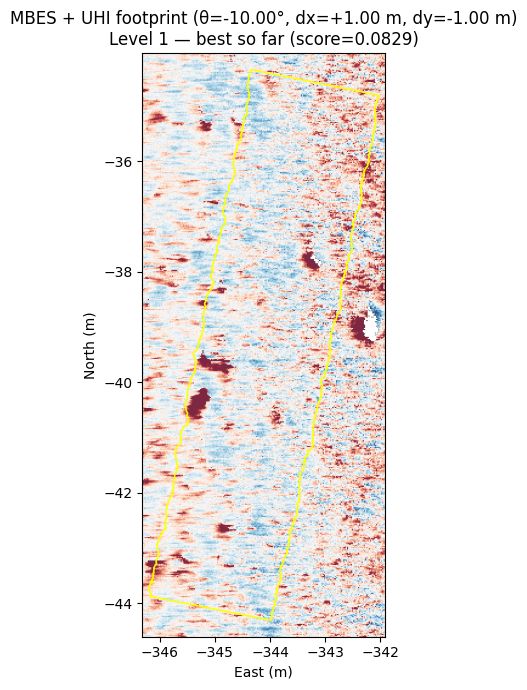

Level 3: θ loop:   0%|          | 0/9 [00:00<?, ?θ/s]

In [ ]:
aligner = UHIMBESAligner(
    cube=cube,
    mb=mb,  # detrended already
    track_start=track_start,
    track_end=track_end,
    origin=(config.LAT0, config.LON0, config.H0),
    wavelength_nm=560.0,
    metric="pearson",  # scale-invariant; or "rmse_z" for RMSE on robust z
    min_overlap=2000,
    n_jobs=-1,
    verbose=True,
    debug_plots=True,  # << shows MBES + transformed UHI outline during search
    debug_every_theta=1,  # show after every angle sweep
    debug_hold_last=True,
)

result = aligner.search_pyramid(
    levels=[
        {
            "dx": (-2, 2, 1.0),
            "dy": (-2, 2, 1.0),
            "theta": (-10, 10, 2.0),
            "stride": 4,
            "k": 16,
            "sigma": 2.0,
        },
        {
            "dx": (-1, 1, 0.5),
            "dy": (-1, 1, 0.5),
            "theta": (-3, 3, 1.0),
            "stride": 2,
            "k": 8,
            "sigma": 1.0,
        },
        {
            "dx": (-0.5, 0.5, 0.25),
            "dy": (-0.5, 0.5, 0.25),
            "theta": (-1, 1, 0.25),
            "stride": 1,
            "k": 1,
            "sigma": None,
        },
    ]
)

print("Best alignment:", result["best"])

updated version

In [ ]:
# alignment_module.py
# UHI ↔ MBES utilities: loading, plotting, metrics, and alignment search
# ---------------------------------------------------------------------
from __future__ import annotations
import os, json, hashlib, csv, time
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec
from matplotlib.collections import LineCollection
from matplotlib.patches import PathPatch
from matplotlib.path import Path as MplPath
from scipy.spatial import cKDTree
from scipy.signal import savgol_filter
from scipy.ndimage import gaussian_filter
from scipy.stats import median_abs_deviation, spearmanr
from pyproj import Transformer
import rasterio

# --------------------------------------------------------------------------------------
# Repo imports (assumes this file is placed in the repo or sys.path includes repo root)
# --------------------------------------------------------------------------------------
from utils import georef
import config
from utils.georef import _ecef_to_ned_arrays


# -----------------------------
# Small math / plotting helpers
# -----------------------------
def robust_z(a: np.ndarray) -> np.ndarray:
    finite = np.isfinite(a)
    if not np.any(finite):
        return np.full_like(a, np.nan, float)
    m = np.nanmedian(a)
    mad = median_abs_deviation(a[finite], scale="normal")
    if not np.isfinite(mad) or mad == 0:
        mad = 1.0
    return (a - m) / mad


def robust_sym_vlim(arr: np.ndarray, q: float = 0.98) -> Tuple[float, float]:
    finite = arr[np.isfinite(arr)]
    if finite.size == 0:
        return -1.0, 1.0
    vmax = np.quantile(np.abs(finite), q)
    return -float(vmax), float(vmax)


def pcolormesh_pad(X: np.ndarray, Y: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    Xc = np.pad(X, ((0, 1), (0, 1)), mode="edge")
    Yc = np.pad(Y, ((0, 1), (0, 1)), mode="edge")
    return Xc, Yc


def pad_limits(ax, x_min, x_max, y_min, y_max, pad_frac=0.03, equal_aspect=True):
    xr = max(1e-12, x_max - x_min)
    yr = max(1e-12, y_max - y_min)
    ax.set_xlim(x_min - xr * pad_frac, x_max + xr * pad_frac)
    ax.set_ylim(y_min - yr * pad_frac, y_max + yr * pad_frac)
    if equal_aspect:
        ax.set_aspect("equal", adjustable="box")


def build_full_valid(X, Y, Z, R, G, B) -> np.ndarray:
    return (
        np.isfinite(X)
        & np.isfinite(Y)
        & np.isfinite(Z)
        & np.isfinite(R)
        & np.isfinite(G)
        & np.isfinite(B)
    )


def boundary_segments_from_mask(mask: np.ndarray, Xc: np.ndarray, Yc: np.ndarray):
    """
    EXACT jagged outline (no smoothing) including outer edges.
    Returns (segs_xy, segs_idx).
    """
    T, S = mask.shape
    segs_xy, segs_idx = [], []

    # internal vertical edges
    vdiff = mask[:, 1:] != mask[:, :-1]
    iv, jv = np.nonzero(vdiff)
    jline = jv + 1
    for i, j in zip(iv, jline):
        a = (i, j)
        b = (i + 1, j)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    # outer left (j=0) and right (j=S)
    i_left = np.nonzero(mask[:, 0])[0]
    for i in i_left:
        a = (i, 0)
        b = (i + 1, 0)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    i_right = np.nonzero(mask[:, -1])[0]
    for i in i_right:
        a = (i, S)
        b = (i + 1, S)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    # internal horizontal edges
    hdiff = mask[1:, :] != mask[:-1, :]
    ih, jh = np.nonzero(hdiff)
    iline = ih + 1
    for i, j in zip(iline, jh):
        a = (i, j)
        b = (i, j + 1)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    # outer top/bottom
    j_top = np.nonzero(mask[0, :])[0]
    for j in j_top:
        a = (0, j)
        b = (0, j + 1)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    j_bot = np.nonzero(mask[-1, :])[0]
    for j in j_bot:
        a = (T, j)
        b = (T, j + 1)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    return np.asarray(segs_xy, float), segs_idx


def trace_loops_from_segments(segs_idx):
    adj = {}
    for a, b in segs_idx:
        adj.setdefault(a, []).append(b)
        adj.setdefault(b, []).append(a)
    unvisited = set(frozenset((a, b)) for a, b in segs_idx)
    loops = []
    while unvisited:
        e = unvisited.pop()
        a, b = tuple(e)
        loop = [a, b]
        prev, cur = a, b
        while True:
            nbrs = adj.get(cur, [])
            nxt = next((n for n in nbrs if n != prev), None)
            if nxt is None:
                break
            edge = frozenset((cur, nxt))
            if edge in unvisited:
                unvisited.remove(edge)
            loop.append(nxt)
            prev, cur = cur, nxt
            if nxt == loop[0]:
                break
        loops.append(loop)
        for i in range(len(loop) - 1):
            unvisited.discard(frozenset((loop[i], loop[i + 1])))
    return loops


def compound_path_from_loops(loops, Xc, Yc) -> MplPath:
    paths = []
    for ring in loops:
        xs = [Xc[idx] for idx in ring]
        ys = [Yc[idx] for idx in ring]
        if xs[0] != xs[-1] or ys[0] != ys[-1]:
            xs.append(xs[0])
            ys.append(ys[0])
        verts = np.column_stack([xs, ys])
        codes = np.full(len(verts), MplPath.LINETO, dtype=MplPath.code_type)
        codes[0] = MplPath.MOVETO
        codes[-1] = MplPath.CLOSEPOLY
        paths.append(MplPath(verts, codes))
    return paths[0] if len(paths) == 1 else MplPath.make_compound_path(*paths)


# -----------------------------
# Minimal MBES detrending
# -----------------------------
@dataclass
class MBESDetrender:
    tif_path: str
    nodata_value: Optional[float] = 9999.0
    smooth_baseline_m: float = 0.5
    smooth_tilt_m: float = 0.5
    smooth_center_m: float = 1.0

    data: Optional[np.ndarray] = None
    valid_mask: Optional[np.ndarray] = None
    transform: Optional[object] = None
    extent: Optional[Tuple[float, float, float, float]] = None
    px_x: Optional[float] = None
    px_y: Optional[float] = None
    x_cols: Optional[np.ndarray] = None
    y_rows: Optional[np.ndarray] = None
    epsg: Optional[int] = None
    A_s: Optional[np.ndarray] = None
    B_s: Optional[np.ndarray] = None
    C_s: Optional[np.ndarray] = None
    trend: Optional[np.ndarray] = None
    residuals: Optional[np.ndarray] = None

    def load(self):
        with rasterio.open(self.tif_path) as src:
            z = src.read(1).astype(np.float64)
            tf = src.transform
            bounds = src.bounds
            self.epsg = src.crs.to_epsg() if src.crs else None
        if self.nodata_value is not None:
            z = np.where(z == self.nodata_value, np.nan, z)
        self.valid_mask = np.isfinite(z)
        a, b, c, d, e, f = tf.a, tf.b, tf.c, tf.d, tf.e, tf.f
        H, W = z.shape
        cols = np.arange(W)
        rows = np.arange(H)
        self.x_cols = c + a * (cols + 0.5)
        self.y_rows = f + e * (rows + 0.5)
        self.px_x = abs(a)
        self.px_y = abs(e)
        self.data = z
        self.transform = tf
        self.extent = (
            float(bounds.left),
            float(bounds.right),
            float(bounds.bottom),
            float(bounds.top),
        )
        return self

    def detrend(self, order_x=2, robust=True, central_frac=0.8, max_row_iters=3):
        if self.data is None:
            self.load()
        z = self.data
        x = self.x_cols
        H, W = z.shape
        valid_rows = np.any(self.valid_mask, axis=1)
        idxs = np.where(valid_rows)[0]
        A = np.full(H, np.nan)
        B = np.full(H, 0.0)
        C = np.full(H, 0.0)

        for i in idxs:
            row = z[i, :]
            m = np.isfinite(row)
            if m.sum() < 6:
                continue
            xv = x[m]
            yv = row[m]
            xc_row = np.median(xv)
            if 0 < central_frac < 1:
                lo = np.quantile(xv, 0.5 - 0.5 * central_frac)
                hi = np.quantile(xv, 0.5 + 0.5 * central_frac)
                keep = (xv >= lo) & (xv <= hi)
                xv, yv = xv[keep], yv[keep]
            xi = xv - xc_row
            deg = min(order_x, 2)
            coef = np.polyfit(xi, yv, deg)
            if deg == 0:
                a0, a1, a2 = float(coef[0]), 0.0, 0.0
            elif deg == 1:
                a1, a0 = float(coef[0]), float(coef[1])
                a2 = 0.0
            else:
                a2, a1, a0 = float(coef[0]), float(coef[1]), float(coef[2])
            if robust and deg > 0:
                for _ in range(max_row_iters):
                    pred = a0 + a1 * xi + a2 * (xi**2)
                    resid = yv - pred
                    s = median_abs_deviation(resid, scale="normal")
                    if not np.isfinite(s) or s == 0:
                        break
                    w = 1.0 / (1.0 + (resid / (3 * s)) ** 2)
                    X = np.vstack([np.ones_like(xi), xi])
                    if deg == 2:
                        X = np.vstack([X, xi**2])
                    beta = np.linalg.lstsq((X * w).T, (yv * w), rcond=None)[0]
                    if deg == 2:
                        a0, a1, a2 = float(beta[0]), float(beta[1]), float(beta[2])
                    else:
                        a0, a1 = float(beta[0]), float(beta[1])
                        a2 = 0.0
            A[i], B[i], C[i] = a0, a1, a2

        def smooth_1d(arr, scale_m):
            if scale_m <= 0 or self.px_y <= 0:
                return arr
            m = np.isfinite(arr)
            if m.sum() < 5:
                return arr
            w = max(3, int(np.round(scale_m / self.px_y)))
            if w % 2 == 0:
                w += 1
            w = min(w, m.sum() - 1 if m.sum() > 1 else 1)
            if w < 3:
                return arr
            out = arr.copy()
            out[m] = savgol_filter(arr[m], window_length=w, polyorder=2)
            return out

        self.A_s = smooth_1d(A, self.smooth_baseline_m)
        self.B_s = smooth_1d(B, self.smooth_tilt_m)
        self.C_s = smooth_1d(C, self.smooth_tilt_m)

ModuleNotFoundError: No module named 'utils'

🔄 Rebuilding grids from georef hits for selected files...
   • rad_uhi_20241029_115057_4
  rad_uhi_20241029_115057_4: Using GRIDDED format (T=2463, S=968)
   • rad_uhi_20241029_115057_5
   • rad_uhi_20241029_115057_5
  rad_uhi_20241029_115057_5: Using GRIDDED format (T=2462, S=968)
  rad_uhi_20241029_115057_5: Using GRIDDED format (T=2462, S=968)
✅ Combined shapes: X/Y/Z (4925, 968), RGB (4925, 968)
✅ Illumination correction already applied with window=1000, strength=1.0
   Loading from disk...
📂 Loading saved illumination correction from 2 files...
✅ Combined shapes: X/Y/Z (4925, 968), RGB (4925, 968)
✅ Illumination correction already applied with window=1000, strength=1.0
   Loading from disk...
📂 Loading saved illumination correction from 2 files...
   rad_uhi_20241029_115057_4: window=1000, strength=1.0
   rad_uhi_20241029_115057_4: window=1000, strength=1.0
   rad_uhi_20241029_115057_5: window=1000, strength=1.0
✅ Loaded illumination correction from disk
   rad_uhi_20241029_115057

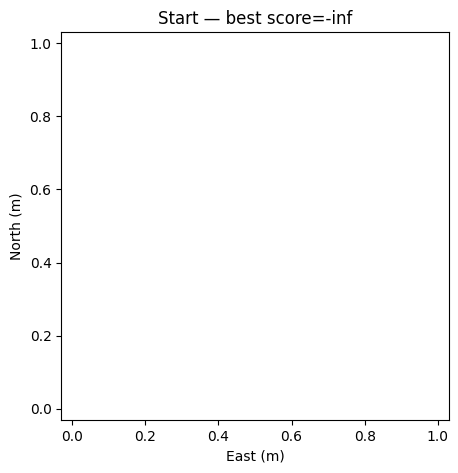


— Level 1 — grid: θ[-3,3,1.0] dx[-0.5,0.5,0.25] dy[-0.5,0.5,0.25] stride=2, k=8, sigma=1.0
  Gate: {'min_score': 0.05, 'min_pairs': 1000, 'stop_if_score_ge': 0.35}


Level 1: 100%|██████████| 175/175 [00:43<00:00,  4.05try/s]



Level 1 result: r=-inf (n/a), pairs=0, improve=nan
→ Early stop after Level 1: best r<0.05


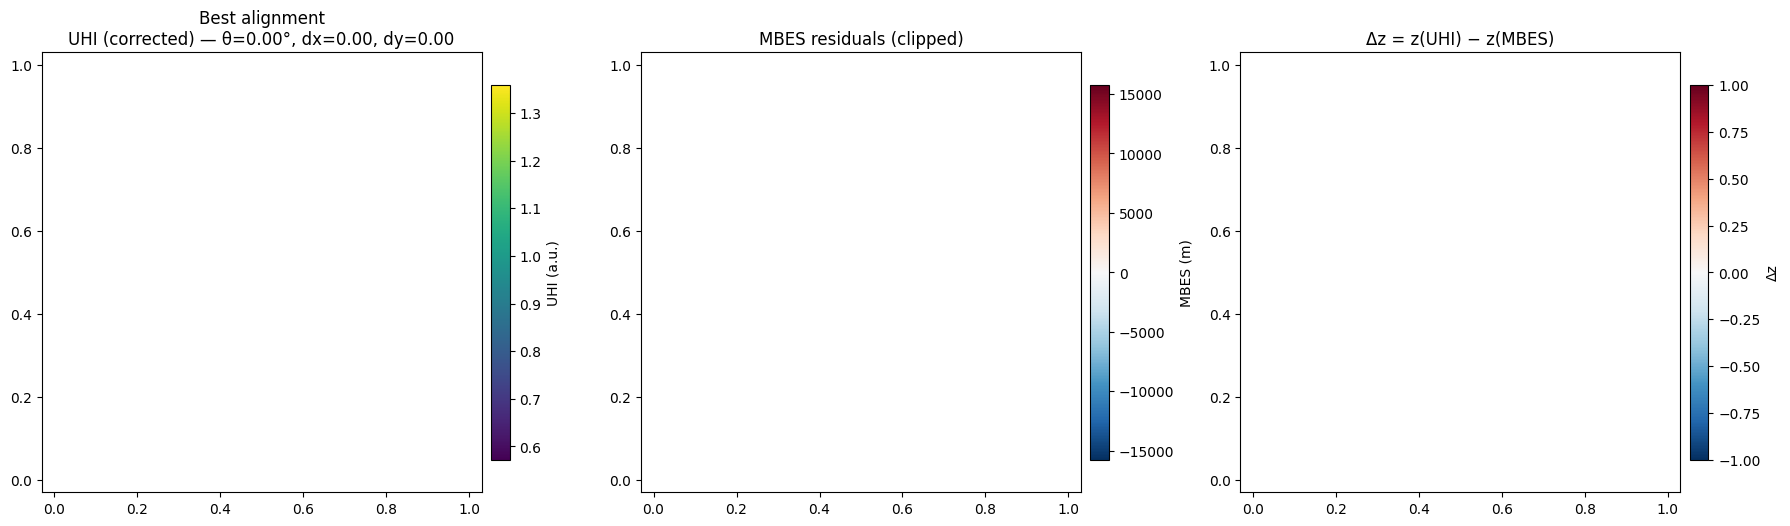


Final verdict: r=-inf (n/a), θ=0.00°, dx=0.00 m, dy=0.00 m, pairs=0
BEST: {'score': -inf, 'theta': 0.0, 'dx': 0.0, 'dy': 0.0, 'n': 0, 'level': -1}


In [ ]:
best, aligner = auto_align_from_config(
    file_ids=["rad_uhi_20241029_115057_4", "rad_uhi_20241029_115057_5"],
    track_start=3039,
    track_end=4029,
    log_csv=r"./alignment_search_log.csv",
    levels=default_levels_small(),
    gates=default_gates_small(),  # <-- GATING / EARLY-STOP
    metric="pearson",
    viz_every=10,
    show_progress=True,
    show_final=True,
)

print("BEST:", best)

In [6]:
# alignment_module.py
# UHI ↔ MBES utilities: loading, plotting, metrics, and alignment search
# ---------------------------------------------------------------------
from __future__ import annotations
import os, json, hashlib, csv, time
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec
from matplotlib.collections import LineCollection
from matplotlib.patches import PathPatch
from matplotlib.path import Path as MplPath
from scipy.spatial import cKDTree
from scipy.signal import savgol_filter
from scipy.ndimage import gaussian_filter
from scipy.stats import median_abs_deviation, spearmanr
from pyproj import Transformer
import rasterio

# --------------------------------------------------------------------------------------
# Repo imports (assumes this file is placed in the repo or sys.path includes repo root)
# --------------------------------------------------------------------------------------
import sys

sys.path.append(os.path.abspath("../"))

from utils import georef
import config
from utils.georef import _ecef_to_ned_arrays


# -----------------------------
# Small math / plotting helpers
# -----------------------------
def robust_z(a: np.ndarray) -> np.ndarray:
    finite = np.isfinite(a)
    if not np.any(finite):
        return np.full_like(a, np.nan, float)
    m = np.nanmedian(a)
    mad = median_abs_deviation(a[finite], scale="normal")
    if not np.isfinite(mad) or mad == 0:
        mad = 1.0
    return (a - m) / mad


def robust_sym_vlim(arr: np.ndarray, q: float = 0.98) -> Tuple[float, float]:
    finite = arr[np.isfinite(arr)]
    if finite.size == 0:
        return -1.0, 1.0
    vmax = np.quantile(np.abs(finite), q)
    return -float(vmax), float(vmax)


def pcolormesh_pad(X: np.ndarray, Y: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    Xc = np.pad(X, ((0, 1), (0, 1)), mode="edge")
    Yc = np.pad(Y, ((0, 1), (0, 1)), mode="edge")
    return Xc, Yc


def pad_limits(ax, x_min, x_max, y_min, y_max, pad_frac=0.03, equal_aspect=True):
    xr = max(1e-12, x_max - x_min)
    yr = max(1e-12, y_max - y_min)
    ax.set_xlim(x_min - xr * pad_frac, x_max + xr * pad_frac)
    ax.set_ylim(y_min - yr * pad_frac, y_max + yr * pad_frac)
    if equal_aspect:
        ax.set_aspect("equal", adjustable="box")


def build_full_valid(X, Y, Z, R, G, B) -> np.ndarray:
    return (
        np.isfinite(X)
        & np.isfinite(Y)
        & np.isfinite(Z)
        & np.isfinite(R)
        & np.isfinite(G)
        & np.isfinite(B)
    )


def boundary_segments_from_mask(mask: np.ndarray, Xc: np.ndarray, Yc: np.ndarray):
    """
    EXACT jagged outline (no smoothing) including outer edges.
    Returns (segs_xy, segs_idx).
    """
    T, S = mask.shape
    segs_xy, segs_idx = [], []

    # internal vertical edges
    vdiff = mask[:, 1:] != mask[:, :-1]
    iv, jv = np.nonzero(vdiff)
    jline = jv + 1
    for i, j in zip(iv, jline):
        a = (i, j)
        b = (i + 1, j)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    # outer left (j=0) and right (j=S)
    i_left = np.nonzero(mask[:, 0])[0]
    for i in i_left:
        a = (i, 0)
        b = (i + 1, 0)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    i_right = np.nonzero(mask[:, -1])[0]
    for i in i_right:
        a = (i, S)
        b = (i + 1, S)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    # internal horizontal edges
    hdiff = mask[1:, :] != mask[:-1, :]
    ih, jh = np.nonzero(hdiff)
    iline = ih + 1
    for i, j in zip(iline, jh):
        a = (i, j)
        b = (i, j + 1)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    # outer top/bottom
    j_top = np.nonzero(mask[0, :])[0]
    for j in j_top:
        a = (0, j)
        b = (0, j + 1)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    j_bot = np.nonzero(mask[-1, :])[0]
    for j in j_bot:
        a = (T, j)
        b = (T, j + 1)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    return np.asarray(segs_xy, float), segs_idx


def trace_loops_from_segments(segs_idx):
    adj = {}
    for a, b in segs_idx:
        adj.setdefault(a, []).append(b)
        adj.setdefault(b, []).append(a)
    unvisited = set(frozenset((a, b)) for a, b in segs_idx)
    loops = []
    while unvisited:
        e = unvisited.pop()
        a, b = tuple(e)
        loop = [a, b]
        prev, cur = a, b
        while True:
            nbrs = adj.get(cur, [])
            nxt = next((n for n in nbrs if n != prev), None)
            if nxt is None:
                break
            edge = frozenset((cur, nxt))
            if edge in unvisited:
                unvisited.remove(edge)
            loop.append(nxt)
            prev, cur = cur, nxt
            if nxt == loop[0]:
                break
        loops.append(loop)
        for i in range(len(loop) - 1):
            unvisited.discard(frozenset((loop[i], loop[i + 1])))
    return loops


def compound_path_from_loops(loops, Xc, Yc) -> MplPath:
    paths = []
    for ring in loops:
        xs = [Xc[idx] for idx in ring]
        ys = [Yc[idx] for idx in ring]
        if xs[0] != xs[-1] or ys[0] != ys[-1]:
            xs.append(xs[0])
            ys.append(ys[0])
        verts = np.column_stack([xs, ys])
        codes = np.full(len(verts), MplPath.LINETO, dtype=MplPath.code_type)
        codes[0] = MplPath.MOVETO
        codes[-1] = MplPath.CLOSEPOLY
        paths.append(MplPath(verts, codes))
    return paths[0] if len(paths) == 1 else MplPath.make_compound_path(*paths)


# -----------------------------
# Minimal MBES detrending
# -----------------------------
@dataclass
class MBESDetrender:
    tif_path: str
    nodata_value: Optional[float] = 9999.0
    smooth_baseline_m: float = 0.5
    smooth_tilt_m: float = 0.5
    smooth_center_m: float = 1.0

    data: Optional[np.ndarray] = None
    valid_mask: Optional[np.ndarray] = None
    transform: Optional[object] = None
    extent: Optional[Tuple[float, float, float, float]] = None
    px_x: Optional[float] = None
    px_y: Optional[float] = None
    x_cols: Optional[np.ndarray] = None
    y_rows: Optional[np.ndarray] = None
    epsg: Optional[int] = None
    A_s: Optional[np.ndarray] = None
    B_s: Optional[np.ndarray] = None
    C_s: Optional[np.ndarray] = None
    trend: Optional[np.ndarray] = None
    residuals: Optional[np.ndarray] = None

    def load(self):
        with rasterio.open(self.tif_path) as src:
            z = src.read(1).astype(np.float64)
            tf = src.transform
            bounds = src.bounds
            self.epsg = src.crs.to_epsg() if src.crs else None
        if self.nodata_value is not None:
            z = np.where(z == self.nodata_value, np.nan, z)
        self.valid_mask = np.isfinite(z)
        a, b, c, d, e, f = tf.a, tf.b, tf.c, tf.d, tf.e, tf.f
        H, W = z.shape
        cols = np.arange(W)
        rows = np.arange(H)
        self.x_cols = c + a * (cols + 0.5)
        self.y_rows = f + e * (rows + 0.5)
        self.px_x = abs(a)
        self.px_y = abs(e)
        self.data = z
        self.transform = tf
        self.extent = (
            float(bounds.left),
            float(bounds.right),
            float(bounds.bottom),
            float(bounds.top),
        )
        return self

    def detrend(self, order_x=2, robust=True, central_frac=0.8, max_row_iters=3):
        if self.data is None:
            self.load()
        z = self.data
        x = self.x_cols
        H, W = z.shape
        valid_rows = np.any(self.valid_mask, axis=1)
        idxs = np.where(valid_rows)[0]
        A = np.full(H, np.nan)
        B = np.full(H, 0.0)
        C = np.full(H, 0.0)

        for i in idxs:
            row = z[i, :]
            m = np.isfinite(row)
            if m.sum() < 6:
                continue
            xv = x[m]
            yv = row[m]
            xc_row = np.median(xv)
            if 0 < central_frac < 1:
                lo = np.quantile(xv, 0.5 - 0.5 * central_frac)
                hi = np.quantile(xv, 0.5 + 0.5 * central_frac)
                keep = (xv >= lo) & (xv <= hi)
                xv, yv = xv[keep], yv[keep]
            xi = xv - xc_row
            deg = min(order_x, 2)
            coef = np.polyfit(xi, yv, deg)
            if deg == 0:
                a0, a1, a2 = float(coef[0]), 0.0, 0.0
            elif deg == 1:
                a1, a0 = float(coef[0]), float(coef[1])
                a2 = 0.0
            else:
                a2, a1, a0 = float(coef[0]), float(coef[1]), float(coef[2])
            if robust and deg > 0:
                for _ in range(max_row_iters):
                    pred = a0 + a1 * xi + a2 * (xi**2)
                    resid = yv - pred
                    s = median_abs_deviation(resid, scale="normal")
                    if not np.isfinite(s) or s == 0:
                        break
                    w = 1.0 / (1.0 + (resid / (3 * s)) ** 2)
                    X = np.vstack([np.ones_like(xi), xi])
                    if deg == 2:
                        X = np.vstack([X, xi**2])
                    beta = np.linalg.lstsq((X * w).T, (yv * w), rcond=None)[0]
                    if deg == 2:
                        a0, a1, a2 = float(beta[0]), float(beta[1]), float(beta[2])
                    else:
                        a0, a1 = float(beta[0]), float(beta[1])
                        a2 = 0.0
            A[i], B[i], C[i] = a0, a1, a2

        def smooth_1d(arr, scale_m):
            if scale_m <= 0 or self.px_y <= 0:
                return arr
            m = np.isfinite(arr)
            if m.sum() < 5:
                return arr
            w = max(3, int(np.round(scale_m / self.px_y)))
            if w % 2 == 0:
                w += 1
            w = min(w, m.sum() - 1 if m.sum() > 1 else 1)
            if w < 3:
                return arr
            out = arr.copy()
            out[m] = savgol_filter(arr[m], window_length=w, polyorder=2)
            return out

        self.A_s = smooth_1d(A, self.smooth_baseline_m)
        self.B_s = smooth_1d(B, self.smooth_tilt_m)
        self.C_s = smooth_1d(C, self.smooth_tilt_m)

In [7]:
best, aligner = auto_align_from_config(
    file_ids=["rad_uhi_20241029_115057_4", "rad_uhi_20241029_115057_5"],
    track_start=3039,
    track_end=4029,
    log_csv=r"./alignment_search_log.csv",
    levels=default_levels_small(),  # coarse→fine
    gates=default_gates_small(),  # early-stop / quality gates
    metric="pearson",
    viz_every=10,
    show_progress=True,
    show_final=True,
)

print("BEST:", best)

NameError: name 'auto_align_from_config' is not defined

lets try again 11.10.2025

In [ ]:
# alignment_module.py
# UHI ↔ MBES alignment using BAND-AVERAGED illumination (mean across all corrected bands).
# Clean structure, progress bar, per-level summary plots, CSV logging.

from __future__ import annotations
import os
import sys
import csv
import time
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.patches import PathPatch
from matplotlib.path import Path as MplPath
from scipy.spatial import cKDTree
from scipy.signal import savgol_filter
from scipy.stats import median_abs_deviation, spearmanr
from pyproj import Transformer
import rasterio

# Add parent directory to path for imports
sys.path.append(os.path.abspath("../"))

# Your repo modules
from utils import georef
import config
from utils.georef import _ecef_to_ned_arrays

# alignment_module.py
# UHI ↔ MBES alignment using BAND-AVERAGED illumination (mean across all corrected bands).
# Clean structure, progress bar, per-level summary plots, CSV logging.

from __future__ import annotations
import os
import csv
import time
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.patches import PathPatch
from matplotlib.path import Path as MplPath
from scipy.spatial import cKDTree
from scipy.signal import savgol_filter
from scipy.stats import median_abs_deviation, spearmanr
from pyproj import Transformer
import rasterio

# Your repo modules
from utils import georef
import config
from utils.georef import _ecef_to_ned_arrays


# ----------------- small helpers -----------------
def robust_sym_vlim(arr: np.ndarray, q: float = 0.98) -> Tuple[float, float]:
    finite = arr[np.isfinite(arr)]
    if finite.size == 0:
        return -1.0, 1.0
    vmax = np.quantile(np.abs(finite), q)
    return -float(vmax), float(vmax)


def pcolormesh_pad(X: np.ndarray, Y: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    Xc = np.pad(X, ((0, 1), (0, 1)), mode="edge")
    Yc = np.pad(Y, ((0, 1), (0, 1)), mode="edge")
    return Xc, Yc


def pad_limits(
    ax, x_min, x_max, y_min, y_max, pad_frac: float = 0.03, equal_aspect: bool = True
) -> None:
    xr = max(1e-12, x_max - x_min)
    yr = max(1e-12, y_max - y_min)
    ax.set_xlim(x_min - xr * pad_frac, x_max + xr * pad_frac)
    ax.set_ylim(y_min - yr * pad_frac, y_max + yr * pad_frac)
    if equal_aspect:
        ax.set_aspect("equal", adjustable="box")


def build_full_valid(X, Y, Z, R, G, B) -> np.ndarray:
    return (
        np.isfinite(X)
        & np.isfinite(Y)
        & np.isfinite(Z)
        & np.isfinite(R)
        & np.isfinite(G)
        & np.isfinite(B)
    )


def boundary_segments_from_mask(mask: np.ndarray, Xc: np.ndarray, Yc: np.ndarray):
    """EXACT jagged outline including outer edges."""
    T, S = mask.shape
    segs_xy, segs_idx = [], []

    # internal vertical
    vdiff = mask[:, 1:] != mask[:, :-1]
    iv, jv = np.nonzero(vdiff)
    jline = jv + 1
    for i, j in zip(iv, jline):
        a = (i, j)
        b = (i + 1, j)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    # outer left/right
    i_left = np.nonzero(mask[:, 0])[0]
    for i in i_left:
        a = (i, 0)
        b = (i + 1, 0)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    i_right = np.nonzero(mask[:, -1])[0]
    for i in i_right:
        a = (i, S)
        b = (i + 1, S)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    # internal horizontal
    hdiff = mask[1:, :] != mask[:-1, :]
    ih, jh = np.nonzero(hdiff)
    iline = ih + 1
    for i, j in zip(iline, jh):
        a = (i, j)
        b = (i, j + 1)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    # outer top/bottom
    j_top = np.nonzero(mask[0, :])[0]
    for j in j_top:
        a = (0, j)
        b = (0, j + 1)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    j_bot = np.nonzero(mask[-1, :])[0]
    for j in j_bot:
        a = (T, j)
        b = (T, j + 1)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    return np.asarray(segs_xy, float), segs_idx


def trace_loops_from_segments(segs_idx):
    adj = {}
    for a, b in segs_idx:
        adj.setdefault(a, []).append(b)
        adj.setdefault(b, []).append(a)

    unvisited = set(frozenset((a, b)) for a, b in segs_idx)
    loops = []

    while unvisited:
        e = unvisited.pop()
        a, b = tuple(e)
        loop = [a, b]
        prev, cur = a, b
        while True:
            nbrs = adj.get(cur, [])
            nxt = next((n for n in nbrs if n != prev), None)
            if nxt is None:
                break
            edge = frozenset((cur, nxt))
            if edge in unvisited:
                unvisited.remove(edge)
            loop.append(nxt)
            prev, cur = cur, nxt
            if nxt == loop[0]:
                break
        loops.append(loop)

        for i in range(len(loop) - 1):
            unvisited.discard(frozenset((loop[i], loop[i + 1])))

    return loops


def compound_path_from_loops(loops, Xc, Yc) -> MplPath:
    paths = []
    for ring in loops:
        xs = [Xc[idx] for idx in ring]
        ys = [Yc[idx] for idx in ring]
        if xs[0] != xs[-1] or ys[0] != ys[-1]:
            xs.append(xs[0])
            ys.append(ys[0])
        verts = np.column_stack([xs, ys])
        codes = np.full(len(verts), MplPath.LINETO, dtype=MplPath.code_type)
        codes[0] = MplPath.MOVETO
        codes[-1] = MplPath.CLOSEPOLY
        paths.append(MplPath(verts, codes))
    return paths[0] if len(paths) == 1 else MplPath.make_compound_path(*paths)


# --------------- MBES detrending ---------------
@dataclass
class MBESDetrender:
    tif_path: str
    nodata_value: Optional[float] = 9999.0
    smooth_baseline_m: float = 0.5
    smooth_tilt_m: float = 0.5
    smooth_center_m: float = 1.0

    data: Optional[np.ndarray] = None
    valid_mask: Optional[np.ndarray] = None
    transform: Optional[object] = None
    extent: Optional[Tuple[float, float, float, float]] = None
    px_x: Optional[float] = None
    px_y: Optional[float] = None
    x_cols: Optional[np.ndarray] = None
    y_rows: Optional[np.ndarray] = None
    epsg: Optional[int] = None
    A_s: Optional[np.ndarray] = None
    B_s: Optional[np.ndarray] = None
    C_s: Optional[np.ndarray] = None
    trend: Optional[np.ndarray] = None
    residuals: Optional[np.ndarray] = None

    def load(self):
        with rasterio.open(self.tif_path) as src:
            z = src.read(1).astype(np.float64)
            tf = src.transform
            bounds = src.bounds
            self.epsg = src.crs.to_epsg() if src.crs else None

        if self.nodata_value is not None:
            z = np.where(z == self.nodata_value, np.nan, z)

        self.valid_mask = np.isfinite(z)

        a, b, c, d, e, f = tf.a, tf.b, tf.c, tf.d, tf.e, tf.f
        H, W = z.shape
        cols = np.arange(W)
        rows = np.arange(H)
        self.x_cols = c + a * (cols + 0.5)
        self.y_rows = f + e * (rows + 0.5)
        self.px_x = abs(a)
        self.px_y = abs(e)

        self.data = z
        self.transform = tf
        self.extent = (
            float(bounds.left),
            float(bounds.right),
            float(bounds.bottom),
            float(bounds.top),
        )
        return self

    def detrend(
        self,
        order_x: int = 2,
        robust: bool = True,
        central_frac: float = 0.8,
        max_row_iters: int = 3,
    ):
        if self.data is None:
            self.load()

        z = self.data
        x = self.x_cols
        H, W = z.shape
        valid_rows = np.any(self.valid_mask, axis=1)
        idxs = np.where(valid_rows)[0]
        A = np.full(H, np.nan)
        B = np.full(H, 0.0)
        C = np.full(H, 0.0)

        for i in idxs:
            row = z[i, :]
            m = np.isfinite(row)
            if m.sum() < 6:
                continue
            xv = x[m]
            yv = row[m]
            xc_row = np.median(xv)

            if 0 < central_frac < 1:
                lo = np.quantile(xv, 0.5 - 0.5 * central_frac)
                hi = np.quantile(xv, 0.5 + 0.5 * central_frac)
                keep = (xv >= lo) & (xv <= hi)
                xv, yv = xv[keep], yv[keep]

            xi = xv - xc_row
            deg = min(order_x, 2)
            coef = np.polyfit(xi, yv, deg)

            if deg == 0:
                a0, a1, a2 = float(coef[0]), 0.0, 0.0
            elif deg == 1:
                a1, a0 = float(coef[0]), float(coef[1])
                a2 = 0.0
            else:
                a2, a1, a0 = float(coef[0]), float(coef[1]), float(coef[2])

            if robust and deg > 0:
                for _ in range(max_row_iters):
                    pred = a0 + a1 * xi + a2 * (xi**2)
                    resid = yv - pred
                    s = median_abs_deviation(resid, scale="normal")
                    if not np.isfinite(s) or s == 0:
                        break
                    w = 1.0 / (1.0 + (resid / (3 * s)) ** 2)
                    X = np.vstack([np.ones_like(xi), xi])
                    if deg == 2:
                        X = np.vstack([X, xi**2])
                    beta = np.linalg.lstsq((X * w).T, (yv * w), rcond=None)[0]
                    if deg == 2:
                        a0, a1, a2 = float(beta[0]), float(beta[1]), float(beta[2])
                    else:
                        a0, a1 = float(beta[0]), float(beta[1])
                        a2 = 0.0

            A[i], B[i], C[i] = a0, a1, a2

        def smooth_1d(arr: np.ndarray, scale_m: float) -> np.ndarray:
            if scale_m <= 0 or self.px_y <= 0:
                return arr
            m = np.isfinite(arr)
            if m.sum() < 5:
                return arr
            w = max(3, int(np.round(scale_m / self.px_y)))
            if w % 2 == 0:
                w += 1
            w = min(w, m.sum() - 1 if m.sum() > 1 else 1)
            if w < 3:
                return arr
            out = arr.copy()
            out[m] = savgol_filter(arr[m], window_length=w, polyorder=2)
            return out

        self.A_s = smooth_1d(A, self.smooth_baseline_m)
        self.B_s = smooth_1d(B, self.smooth_tilt_m)
        self.C_s = smooth_1d(C, self.smooth_tilt_m)

        trend = np.full_like(z, np.nan)
        for i in idxs:
            if not np.isfinite(self.A_s[i]):
                continue
            xc = np.median(x[np.isfinite(z[i, :])])
            xi = x - xc
            trend[i, :] = self.A_s[i] + self.B_s[i] * xi + self.C_s[i] * (xi**2)

        self.trend = trend
        self.residuals = z - trend
        return self

    def robust_sym_vlim(
        self, arr: Optional[np.ndarray] = None, q: float = 0.98
    ) -> Tuple[float, float]:
        a = self.residuals if arr is None else arr
        return robust_sym_vlim(a, q=q)


# --------------- search specs ---------------
@dataclass
class LevelSpec:
    theta_range: Tuple[float, float]
    theta_step: float
    dx_range: Tuple[float, float]
    dy_range: Tuple[float, float]
    step_xy: float
    stride: int = 1
    k: int = 1
    sample_frac: float = 1.0
    max_tries: Optional[int] = None


@dataclass
class GateSpec:
    min_pairs: int = 1000
    min_score: float = -0.25
    stop_if_score_ge: float = 0.35


# --------------- alignment search ---------------
class AlignmentSearch:
    def __init__(
        self,
        E: np.ndarray,
        N: np.ndarray,
        mask_valid: np.ndarray,
        uhi_scalar: np.ndarray,
        mb: MBESDetrender,
        lat0: float,
        lon0: float,
        h0: float,
        metric: str = "pearson",
        use_abs: bool = False,
    ):
        """
        uhi_scalar: (T,S) band-averaged illumination (mean across all corrected bands).
        """
        self.E = E
        self.N = N
        self.mask_valid = mask_valid.astype(bool)
        self.uhi_scalar = uhi_scalar
        self.metric = metric.lower()
        self.use_abs = bool(use_abs)

        # footprint path (pixel-perfect)
        Xc, Yc = pcolormesh_pad(E, N)
        segs_xy, segs_idx = boundary_segments_from_mask(self.mask_valid, Xc, Yc)
        loops = trace_loops_from_segments(segs_idx)
        self.footprint_path0 = compound_path_from_loops(loops, Xc, Yc)
        self.outline_lc = LineCollection(segs_xy, colors="k", linewidths=1.1, alpha=0.9)

        # UHI KDTree (valid pixels)
        valid_uhi = (
            self.mask_valid & np.isfinite(uhi_scalar) & np.isfinite(E) & np.isfinite(N)
        )
        self.uhi_pts = np.column_stack([E[valid_uhi], N[valid_uhi]])
        self.uhi_vals = uhi_scalar[valid_uhi]
        if self.uhi_pts.size == 0:
            raise RuntimeError("No valid UHI points for KDTree.")
        self.tree_uhi = cKDTree(self.uhi_pts)

        # pivot (geometric center)
        self.cx = float(np.nanmean(E[valid_uhi]))
        self.cy = float(np.nanmean(N[valid_uhi]))

        # MBES → NED (once)
        MBES_X, MBES_Y = np.meshgrid(mb.x_cols, mb.y_rows)
        epsg_src = getattr(mb, "epsg", 32633) if getattr(mb, "epsg", None) else 32633
        tf_to_ll = Transformer.from_crs(f"EPSG:{epsg_src}", "EPSG:4326", always_xy=True)
        mbes_lon, mbes_lat = tf_to_ll.transform(MBES_X, MBES_Y)
        tf_geo_to_ecef = Transformer.from_crs("EPSG:4979", "EPSG:4978", always_xy=True)
        mbes_x_ecef, mbes_y_ecef, mbes_z_ecef = tf_geo_to_ecef.transform(
            mbes_lon, mbes_lat, np.zeros_like(mbes_lon)
        )
        mbes_n_ned, mbes_e_ned, _ = _ecef_to_ned_arrays(
            mbes_x_ecef, mbes_y_ecef, mbes_z_ecef, lat0, lon0, h0
        )
        self.mbes_e = mbes_e_ned
        self.mbes_n = mbes_n_ned
        self.mbes_res = mb.residuals
        self.P_mbes = np.column_stack([self.mbes_e.ravel(), self.mbes_n.ravel()])

        base_inside = self.footprint_path0.contains_points(self.P_mbes)
        self.base_pairs = int(np.sum(base_inside))
        if self.base_pairs == 0:
            raise RuntimeError("No MBES pixels inside UHI footprint at base.")

        self.last_level = None

    @staticmethod
    def _pearson_r(x: np.ndarray, y: np.ndarray) -> float:
        m = np.isfinite(x) & np.isfinite(y)
        if m.sum() < 10:
            return np.nan
        x = x[m]
        y = y[m]
        sx = x.std(ddof=1)
        sy = y.std(ddof=1)
        if sx == 0 or sy == 0:
            return np.nan
        x = (x - x.mean()) / sx
        y = (y - y.mean()) / sy
        return float(np.clip(np.corrcoef(x, y)[0, 1], -1, 1))

    @staticmethod
    def _spearman_r(x: np.ndarray, y: np.ndarray) -> float:
        m = np.isfinite(x) & np.isfinite(y)
        if m.sum() < 10:
            return np.nan
        r = spearmanr(x[m], y[m], nan_policy="omit").correlation
        return float(np.clip(r, -1, 1)) if np.isfinite(r) else np.nan

    def _score_vec(self, u: np.ndarray, z: np.ndarray) -> float:
        if self.metric == "spearman":
            r = self._spearman_r(u, z)
        else:
            r = self._pearson_r(u, z)
        return abs(r) if self.use_abs and np.isfinite(r) else r

    def score_one(
        self,
        theta_deg: float,
        dx: float,
        dy: float,
        stride: int,
        k: int,
        min_pairs: int,
    ) -> Tuple[float, int]:
        rad = np.deg2rad(theta_deg)
        c, s = np.cos(rad), np.sin(rad)
        Rinv = np.array([[c, s], [-s, c]], float)

        P = self.P_mbes[::stride]
        Pprime = (P - np.array([dx, dy])) - np.array([self.cx, self.cy])
        Pprime = Pprime @ Rinv.T + np.array([self.cx, self.cy])

        inside = self.footprint_path0.contains_points(Pprime)
        if not inside.any():
            return np.nan, 0
        idx_inside = np.where(inside)[0]
        if idx_inside.size < min_pairs:
            return np.nan, int(idx_inside.size)

        d, nn = self.tree_uhi.query(Pprime[idx_inside], k=k)
        u = self.uhi_vals[nn].astype(float).ravel()
        z = self.mbes_res.ravel()[::stride][idx_inside].astype(float).ravel()
        return self._score_vec(u, z), int(idx_inside.size)

    def run(
        self,
        levels: List[LevelSpec],
        gates: GateSpec,
        log_csv: Optional[str] = None,
        viz_every: int = 0,
        show_progress: bool = True,
        show_final: bool = True,
        rng_seed: int = 0,
    ) -> Dict:
        writer = None
        f_csv = None
        if log_csv:
            exists = os.path.exists(log_csv)
            f_csv = open(log_csv, "a", newline="")
            writer = csv.writer(f_csv)
            if not exists:
                writer.writerow(
                    [
                        "ts",
                        "level",
                        "theta_deg",
                        "dx_m",
                        "dy_m",
                        "stride",
                        "k",
                        "pairs",
                        "score",
                        "metric",
                        "abs",
                    ]
                )

        best = {
            "score": -np.inf,
            "theta": 0.0,
            "dx": 0.0,
            "dy": 0.0,
            "n": 0,
            "level": -1,
        }

        try:
            from tqdm import tqdm

            have_tqdm = True
        except Exception:
            have_tqdm = False

        rng = np.random.default_rng(rng_seed)

        try:
            for li, lvl in enumerate(levels, 1):
                th_vals = np.arange(
                    lvl.theta_range[0], lvl.theta_range[1] + 1e-9, lvl.theta_step
                )
                dx_vals = np.arange(
                    lvl.dx_range[0], lvl.dx_range[1] + 1e-9, lvl.step_xy
                )
                dy_vals = np.arange(
                    lvl.dy_range[0], lvl.dy_range[1] + 1e-9, lvl.step_xy
                )

                nth, ndx, ndy = len(th_vals), len(dx_vals), len(dy_vals)
                r_cube = np.full((nth, ndy, ndx), np.nan, dtype=float)

                grid = np.array(np.meshgrid(th_vals, dy_vals, dx_vals, indexing="ij"))
                combos = grid.reshape(3, -1).T
                n_total = combos.shape[0]
                sel_idx = np.arange(n_total)

                if 0 < lvl.sample_frac < 1.0:
                    n_pick = max(1, int(np.floor(n_total * lvl.sample_frac)))
                    sel_idx = rng.choice(sel_idx, size=n_pick, replace=False)
                if lvl.max_tries is not None:
                    sel_idx = sel_idx[: int(lvl.max_tries)]
                combos = combos[sel_idx]
                n_eval = combos.shape[0]

                pbar = (
                    tqdm(total=n_eval, desc=f"Level {li}", unit="try")
                    if (have_tqdm and show_progress)
                    else None
                )
                level_best = -np.inf
                accepted = 0

                def idx_th(val):
                    return int(
                        np.round(
                            (val - th_vals[0])
                            / (th_vals[1] - th_vals[0] if len(th_vals) > 1 else 1)
                        )
                    )

                def idx_dx(val):
                    return int(
                        np.round(
                            (val - dx_vals[0])
                            / (dx_vals[1] - dx_vals[0] if len(dx_vals) > 1 else 1)
                        )
                    )

                def idx_dy(val):
                    return int(
                        np.round(
                            (val - dy_vals[0])
                            / (dy_vals[1] - dy_vals[0] if len(dy_vals) > 1 else 1)
                        )
                    )

                for j, (th, dy, dx) in enumerate(combos, 1):
                    score, pairs = self.score_one(
                        float(th),
                        float(dx),
                        float(dy),
                        lvl.stride,
                        lvl.k,
                        gates.min_pairs,
                    )
                    try:
                        r_cube[idx_th(th), idx_dy(dy), idx_dx(dx)] = score
                    except Exception:
                        pass

                    if writer:
                        writer.writerow(
                            [
                                time.time(),
                                li,
                                float(th),
                                float(dx),
                                float(dy),
                                lvl.stride,
                                lvl.k,
                                pairs,
                                score,
                                self.metric,
                                int(self.use_abs),
                            ]
                        )

                    if np.isfinite(score):
                        accepted += 1
                        if score > level_best:
                            level_best = score
                        if score > best["score"]:
                            best.update(
                                {
                                    "score": float(score),
                                    "theta": float(th),
                                    "dx": float(dx),
                                    "dy": float(dy),
                                    "n": int(pairs),
                                    "level": li,
                                }
                            )
                            if viz_every and (accepted % max(1, int(viz_every)) == 0):
                                self._quick_viz(best, title=f"Level {li} — best so far")

                    if pbar:
                        acc_rate = 100.0 * accepted / j
                        pbar.set_postfix(
                            best=f"{best['score']:.3f}",
                            level=f"{level_best:.3f}",
                            acc=f"{acc_rate:.1f}%",
                            pairs=pairs,
                        )
                        pbar.update(1)

                if pbar:
                    pbar.close()

                self.last_level = {
                    "r_cube": r_cube,
                    "th_vals": th_vals,
                    "dx_vals": dx_vals,
                    "dy_vals": dy_vals,
                    "level_best": float(level_best),
                }

                self._plot_level_summary()

                if accepted == 0:
                    print(
                        f"• Early stop after Level {li}: no candidates reached min_pairs={gates.min_pairs}."
                    )
                    break
                if level_best < gates.min_score:
                    print(
                        f"• Early stop after Level {li}: level-best {self.metric}<{gates.min_score:.2f}."
                    )
                    break
                if best["score"] >= gates.stop_if_score_ge:
                    print(
                        f"• Early stop: {self.metric}≥{gates.stop_if_score_ge:.2f} at Level {li}."
                    )
                    break

            if show_final:
                self._quick_viz(best, title="Best alignment")

        finally:
            if f_csv:
                f_csv.close()

        return best

    # ---------- quick visual ----------
    def _quick_viz(self, best: Dict, title: str = ""):
        rad = np.deg2rad(best["theta"])
        c, s = np.cos(rad), np.sin(rad)
        R = np.array([[c, -s], [s, c]], float)
        dx0, dy0 = best["dx"], best["dy"]

        verts = self.footprint_path0.vertices.copy()
        mask = np.isfinite(verts[:, 0]) & np.isfinite(verts[:, 1])
        V = verts[mask]
        V2 = (
            (V - np.array([self.cx, self.cy])) @ R.T
            + np.array([self.cx, self.cy])
            + np.array([dx0, dy0])
        )
        verts[mask] = V2
        footprint_path_best = MplPath(verts, self.footprint_path0.codes)

        vmin_mbes, vmax_mbes = robust_sym_vlim(self.mbes_res, q=0.98)
        fig, ax = plt.subplots(1, 1, figsize=(5.8, 10))
        extent_ned = [
            float(np.nanmin(self.mbes_e)),
            float(np.nanmax(self.mbes_e)),
            float(np.nanmin(self.mbes_n)),
            float(np.nanmax(self.mbes_n)),
        ]
        im = ax.imshow(
            np.ma.masked_invalid(self.mbes_res),
            extent=extent_ned,
            origin="upper",
            cmap="RdBu_r",
            vmin=vmin_mbes,
            vmax=vmax_mbes,
        )
        ax.add_patch(
            PathPatch(
                footprint_path_best,
                transform=ax.transData,
                facecolor="none",
                edgecolor="y",
                lw=1.3,
                alpha=0.95,
            )
        )
        ax.set_title(
            f"{title}\nθ={best['theta']:+.2f}°, dx={best['dx']:+.2f} m, dy={best['dy']:+.2f} m, {self.metric}={best['score']:.3f}"
            + (" (|r|)" if self.use_abs else "")
        )
        ax.set_xlabel("East (m)")
        ax.set_ylabel("North (m)")
        pad_limits(
            ax,
            footprint_path_best.vertices[:, 0].min(),
            footprint_path_best.vertices[:, 0].max(),
            footprint_path_best.vertices[:, 1].min(),
            footprint_path_best.vertices[:, 1].max(),
            pad_frac=0.03,
            equal_aspect=True,
        )
        fig.colorbar(im, ax=ax, fraction=0.045, pad=0.02, label="MBES Residuals (m)")
        plt.show()

    def _plot_level_summary(self) -> None:
        L = self.last_level
        if L is None:
            return

        r_cube = L["r_cube"]
        th_vals = L["th_vals"]
        dx_vals = L["dx_vals"]
        dy_vals = L["dy_vals"]

        r_vs_theta = np.nanmax(r_cube, axis=(1, 2))
        if not np.isfinite(r_vs_theta).any():
            print("Level summary: no finite scores.")
            return

        it_best = int(np.nanargmax(r_vs_theta))
        th_best = th_vals[it_best]
        R_slice = r_cube[it_best, :, :]

        j_best, i_best = np.unravel_index(int(np.nanargmax(R_slice)), R_slice.shape)
        dx_best = dx_vals[i_best]
        dy_best = dy_vals[j_best]
        r_best = float(R_slice[j_best, i_best])

        fig, axes = plt.subplots(1, 3, figsize=(18, 6.2))
        axA, axB, axC = axes

        dx_step = dx_vals[1] - dx_vals[0] if len(dx_vals) > 1 else 1.0
        dy_step = dy_vals[1] - dy_vals[0] if len(dy_vals) > 1 else 1.0
        imA = axA.imshow(
            R_slice,
            origin="lower",
            extent=[
                dx_vals[0] - 0.5 * dx_step,
                dx_vals[-1] + 0.5 * dx_step,
                dy_vals[0] - 0.5 * dy_step,
                dy_vals[-1] + 0.5 * dy_step,
            ],
            cmap="viridis",
            vmin=-1,
            vmax=1,
            aspect="equal",
        )
        axA.scatter([dx_best], [dy_best], c="r", s=50, marker="x", zorder=5)
        axA.set_title(f"{self.metric} (dx,dy) @ θ={th_best:+.1f}°")
        axA.set_xlabel("dx (m)")
        axA.set_ylabel("dy (m)")
        fig.colorbar(
            imA,
            ax=axA,
            fraction=0.045,
            pad=0.02,
            label=self.metric + (" (abs)" if self.use_abs else ""),
        )

        axB.plot(th_vals, r_vs_theta, lw=2)
        axB.axvline(th_best, color="r", ls="--", lw=1)
        axB.set_title(f"max {self.metric} over (dx,dy) vs θ")
        axB.set_xlabel("θ (deg)")
        axB.set_ylabel(f"max {self.metric}")

        axC.axis("off")
        axC.text(
            0.02,
            0.98,
            f"Best slice θ={th_best:+.1f}°\n"
            f"Best (dx,dy)=({dx_best:+.2f},{dy_best:+.2f}) m\n"
            f"Best {self.metric}={r_best:.3f}",
            va="top",
            ha="left",
            fontsize=12,
        )
        plt.show()


# --------------- defaults ---------------
def default_levels_small() -> List[LevelSpec]:
    # ~63 tries (fast)
    return [
        LevelSpec(
            theta_range=(-3.0, 3.0),
            theta_step=1.0,
            dx_range=(-0.5, 0.5),
            dy_range=(-0.5, 0.5),
            step_xy=0.5,
            stride=2,
            k=1,
            sample_frac=1.0,
            max_tries=None,
        )
    ]


def default_levels_tiny() -> List[LevelSpec]:
    # very fast smoke test
    return [
        LevelSpec(
            theta_range=(-1.0, 1.0),
            theta_step=1.0,
            dx_range=(-0.5, 0.5),
            dy_range=(-0.5, 0.5),
            step_xy=0.5,
            stride=4,
            k=1,
            sample_frac=1.0,
            max_tries=None,
        )
    ]


def default_gates_small() -> GateSpec:
    return GateSpec(min_pairs=1000, min_score=-0.25, stop_if_score_ge=0.35)


# --------------- orchestration (uses BAND-AVERAGED UHI) ---------------
def auto_align_from_config(
    file_ids: List[str],
    track_start: int,
    track_end: int,
    log_csv: Optional[str],
    levels: List[LevelSpec],
    gates: GateSpec,
    metric: str = "pearson",
    use_abs: bool = False,
    viz_every: int = 10,
    show_progress: bool = True,
    show_final: bool = True,
    rng_seed: int = 0,
) -> Tuple[Dict, AlignmentSearch]:
    """
    Loads UHI, applies illumination correction, computes BAND-AVERAGED UHI image (mean across bands),
    detrends MBES, then runs alignment search.
    """
    # --- UHI load/slice ---
    transect = georef.load_transect(config.OUTPUT_FOLDER)
    cube = transect.select_files(file_ids)

    X = cube.X_ecef[track_start:track_end, :]
    Y = cube.Y_ecef[track_start:track_end, :]
    Z = cube.Z_ecef[track_start:track_end, :]
    R = cube.R[track_start:track_end, :]
    G = cube.G[track_start:track_end, :]
    B = cube.B[track_start:track_end, :]

    full_valid = build_full_valid(X, Y, Z, R, G, B)

    lat0, lon0, h0 = config.LAT0, config.LON0, config.H0
    N, E, D = _ecef_to_ned_arrays(X, Y, Z, lat0, lon0, h0)

    # --- Illumination correction (persistent) ---
    cube.apply_illumination_correction(window_size=1000, strength=1.0)
    # BAND-AVERAGED (mean across all corrected bands) for the chosen slice
    uhi_scalar = np.nanmean(
        cube.data_corrected[track_start:track_end, :, :], axis=2
    ).astype(np.float32)

    # --- MBES detrend ---
    mb = (
        MBESDetrender(
            config.MBES_GEOTIFF,
            smooth_baseline_m=0.5,
            smooth_tilt_m=0.5,
            smooth_center_m=1.0,
        )
        .load()
        .detrend(order_x=2, robust=True, central_frac=0.8)
    )

    # --- Align ---
    print(f"Start — base UHI valid pixels: {int(full_valid.sum()):,}")
    aligner = AlignmentSearch(
        E=E,
        N=N,
        mask_valid=full_valid,
        uhi_scalar=uhi_scalar,
        mb=mb,
        lat0=lat0,
        lon0=lon0,
        h0=h0,
        metric=metric,
        use_abs=use_abs,
    )
    best = aligner.run(
        levels=levels,
        gates=gates,
        log_csv=log_csv,
        viz_every=viz_every,
        show_progress=show_progress,
        show_final=show_final,
        rng_seed=rng_seed,
    )
    print(
        f"\nFinal verdict: {metric}={best['score']:.3f}  "
        f"θ={best['theta']:+.2f}°, dx={best['dx']:+.2f} m, dy={best['dy']:+.2f} m, pairs={best['n']}"
    )
    return best, aligner

🔄 Rebuilding grids from georef hits for selected files...
   • rad_uhi_20241029_115057_4
  rad_uhi_20241029_115057_4: Using GRIDDED format (T=2463, S=968)
  rad_uhi_20241029_115057_4: Using GRIDDED format (T=2463, S=968)
   • rad_uhi_20241029_115057_5
   • rad_uhi_20241029_115057_5
  rad_uhi_20241029_115057_5: Using GRIDDED format (T=2462, S=968)
  rad_uhi_20241029_115057_5: Using GRIDDED format (T=2462, S=968)
✅ Combined shapes: X/Y/Z (4925, 968), RGB (4925, 968)
✅ Illumination correction already applied with window=1000, strength=1.0
   Loading from disk...
📂 Loading saved illumination correction from 2 files...
✅ Combined shapes: X/Y/Z (4925, 968), RGB (4925, 968)
✅ Illumination correction already applied with window=1000, strength=1.0
   Loading from disk...
📂 Loading saved illumination correction from 2 files...
   rad_uhi_20241029_115057_4: window=1000, strength=1.0
   rad_uhi_20241029_115057_4: window=1000, strength=1.0
   rad_uhi_20241029_115057_5: window=1000, strength=1.0
✅ L

Level 1:  46%|████▌     | 29/63 [15:58<20:01, 35.34s/try, acc=100.0%, best=0.009, level=0.009, pairs=28141] 

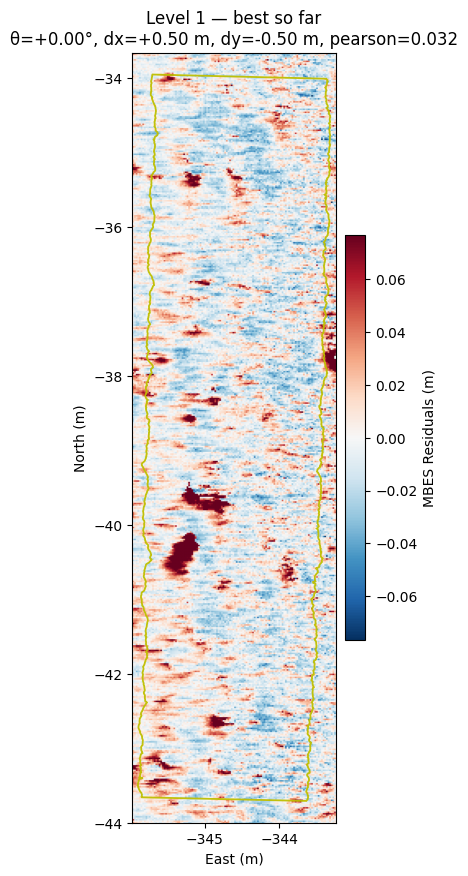

Level 1: 100%|██████████| 63/63 [35:23<00:00, 33.71s/try, acc=100.0%, best=0.032, level=0.032, pairs=28170]



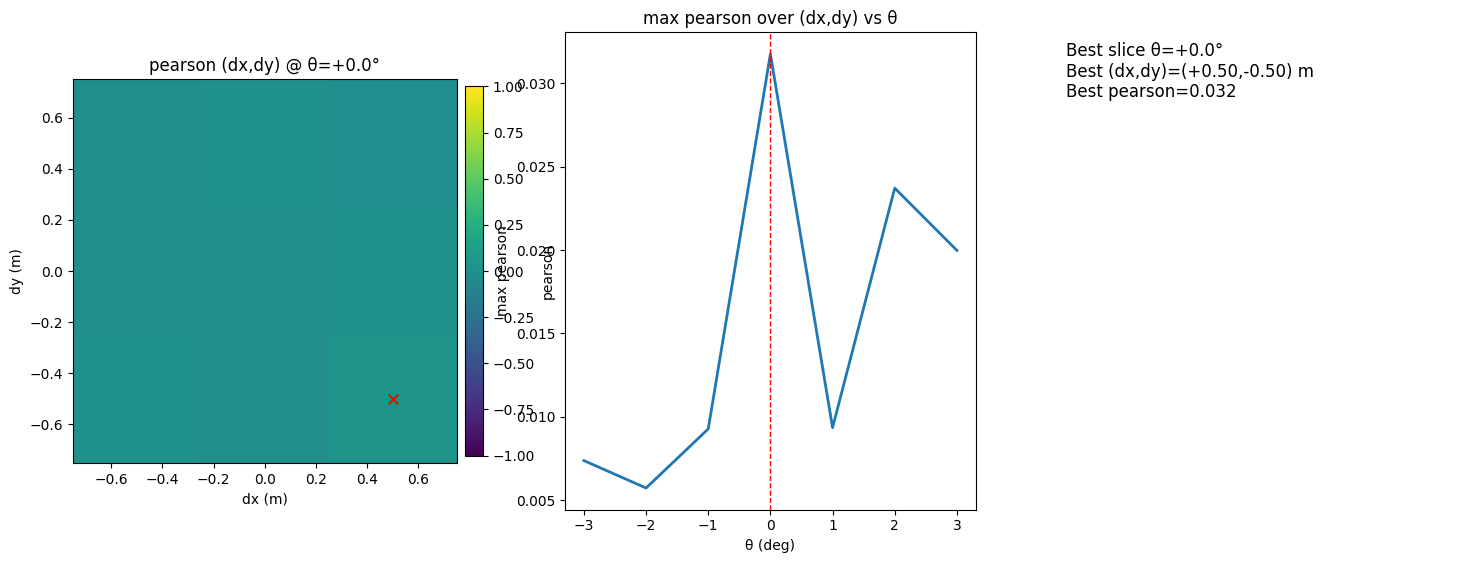

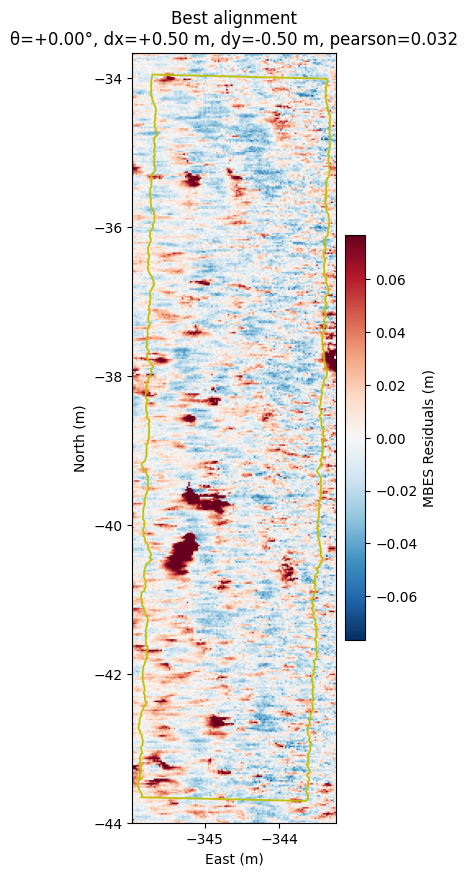


Final verdict: pearson=0.032  θ=+0.00°, dx=+0.50 m, dy=-0.50 m, pairs=28173
BEST: {'score': 0.03176484417201655, 'theta': 0.0, 'dx': 0.5, 'dy': -0.5, 'n': 28173, 'level': 1}


In [10]:
# runner cell — minimal call

# Quick smoke test:
# levels = default_levels_tiny()

# Small default (~63 tries; fast):
levels = default_levels_small()
gates = default_gates_small()

best, aligner = auto_align_from_config(
    file_ids=["rad_uhi_20241029_115057_4", "rad_uhi_20241029_115057_5"],
    track_start=3039,
    track_end=4029,
    log_csv="./alignment_search_log.csv",
    levels=levels,
    gates=gates,
    metric="pearson",  # or "spearman"
    use_abs=False,  # True if you care about |r| only
    viz_every=10,  # overlay preview every N accepted candidates
    show_progress=True,  # tqdm bar with live best/acc rate
    show_final=True,
    rng_seed=0,
)

print("BEST:", best)